> **© 2026 Suna Kim. All Rights Reserved.**
>
> This repository is shared publicly to demonstrate applied finance/coding
> skills as part of my professional portfolio. No permission is granted to
> use, copy, modify, or distribute this code without explicit written
> consent from the author.

# Korea Electronics ADR — Cross-Listed Arbitrage Analysis (v3)

**Architecture:**
- KRX is the price discovery market. Causal chain: KRX news → KRX price → ADR adjusts with lag.
- **Cell KE-00b** discovers US listings for any KRX ticker automatically — no hardcoding required.
- Two investor perspectives modelled separately: KRX fundamental (KRW) and USD investor (KRX + FX + arb).
- US CAPM/FF5/APT against SPY are supplementary only — Korean factor models (KE-03) are primary.
- Korean regime breaks (BOK pivots, Legoland 2022, martial law Dec 2024) are separate from the US REGIMES dict.

### Execution order
```
Cell 00 → 01 → 02 → 03  (main us_market_pricing notebook — must run first)
Cell KE-00  → KE-00b → KE-01 → KE-02 → KE-03 → KE-04 → KE-05 → KE-06 → KE-07
```

### KE-00b scan modes
| Mode | Description |
|------|-------------|
| `registry_only` | Only verify the hardcoded KNOWN_KRX_TO_US table |
| `user_list` | Any custom list of KRX tickers you provide |
| `electronics` | Curated Korean electronics universe (~15 tickers) |
| `kospi200` | Full KOSPI 200 constituents (~200 tickers, takes ~10 min) |

## Cell KE-00 — KE-ADR Registry + Dual Regime Configuration

Hardcoded registry and Korean regime breaks. **KE-00b overrides `KE_ADR_REGISTRY`** after running — KE-00 just sets defaults and the regime/config data.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-00 — GOOGLE DRIVE MOUNT + OUTPUT PATH GUARD                        ║
# ║                                                                              ║
# ║  Run this FIRST, before any other cell.                                      ║
# ║  Mounts Drive, confirms RESULT_DIR exists, and defines safe_save()           ║
# ║  which saves every CSV to Drive only (no auto-download).                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import os

# ── Detect environment and pick an output directory ──────────────────────────
# No assumption that Google Drive (or even Colab) is available. Priority:
#   1) OUTPUT_DIR environment variable, if you've set one
#   2) Google Drive, only if running in Colab and it mounts successfully
#   3) a local ./pricing_results folder next to wherever this notebook runs

RESULT_DIR = os.environ.get('OUTPUT_DIR')

if RESULT_DIR is None:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        RESULT_DIR = '/content/drive/My Drive/investment/investment_us/pricing_results'
    except ImportError:
        # Not running in Colab at all — Drive was never an option here
        RESULT_DIR = './pricing_results'
    except Exception as _e:
        # In Colab, but the mount itself failed (declined permission, no Drive, etc.)
        print(f'ℹ  Could not mount Google Drive ({_e}) — using a local folder instead.')
        RESULT_DIR = './pricing_results'

os.makedirs(RESULT_DIR, exist_ok=True)

# Verify the chosen directory is actually writable
_test_path = os.path.join(RESULT_DIR, '.write_test')
try:
    with open(_test_path, 'w') as _f:
        _f.write('ok')
    os.remove(_test_path)
    print(f'✅  Output directory ready and writable.')
    print(f'    RESULT_DIR = {RESULT_DIR}')
except Exception as _e:
    print(f'❌  {RESULT_DIR} is NOT writable: {_e}')
    print(f'    Falling back to ./pricing_results (local to this session)')
    RESULT_DIR = './pricing_results'
    os.makedirs(RESULT_DIR, exist_ok=True)

# ── safe_save: saves to RESULT_DIR only ───────────────────────────────────────
def safe_save(df, filename, float_format='%.4f'):
    """
    Save DataFrame as CSV to RESULT_DIR (Drive, local folder, or wherever
    OUTPUT_DIR points). Verifies the file was written and prints the file size.
    No automatic download — open the file from RESULT_DIR directly.
    """
    fpath = os.path.join(RESULT_DIR, filename)
    df.to_csv(fpath, index=False, float_format=float_format)
    if os.path.exists(fpath):
        kb = os.path.getsize(fpath) / 1024
        print(f'  ✅  Saved: {filename}  ({kb:.1f} KB)  → {fpath}')
    else:
        print(f'  ❌  SAVE FAILED: {filename} not found after write!')

print(f'\n  safe_save() defined — files will be saved to RESULT_DIR only.')
print(f'\n✅  Cell KE-00 done.')

Mounted at /content/drive
✅  Drive mounted and writable.
    RESULT_DIR = /content/drive/My Drive/investment/investment_us/pricing_results

  safe_save() defined — files will be saved to Drive only.

✅  Cell KE-00 done.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-00a — KE-ADR REGISTRY + DUAL REGIME CONFIGURATION                ║
# ║                                                                              ║
# ║  Registry: NYSE-listed Korean ADRs only (liquid, tradeable)                ║
# ║  Removed: SSNLF, LGEIY, SSDIY, HXSCF (OTC / untradeable)                 ║
# ║  Added:   KEP (KEPCO, utilities), WF (Woori Financial)                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import subprocess, sys
for _pkg in ['fredapi', 'pandas-datareader', 'statsmodels', 'arch', 'pykalman']:
    try:
        __import__(_pkg.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import os, warnings
from datetime import datetime
from fredapi import Fred
warnings.filterwarnings('ignore')

# ── Guard / self-sufficient fallback ──────────────────────────────────────────
_missing = [v for v in ['START_DATE','END_DATE','TARGET_DATE','RF_ANN','MRP_ANN',
                         'RESULT_DIR','CAL_DAYS','fred']
            if v not in globals()]

if _missing:
    print(f'  ⚠️  Main notebook variables not found: {_missing}')
    print(f'  ⚠️  Defining fallback defaults — run main Cell 00–03 for full accuracy.')

    START_DATE   = globals().get('START_DATE',  datetime(2020, 4, 1))
    END_DATE     = globals().get('END_DATE',    datetime.today())
    TARGET_DATE  = globals().get('TARGET_DATE', datetime(2029, 1, 20))
    RF_ANN       = globals().get('RF_ANN',      0.045)
    MRP_ANN      = globals().get('MRP_ANN',     0.05)
    CAL_DAYS     = globals().get('CAL_DAYS',    max(1, (TARGET_DATE - END_DATE).days))

    if 'RESULT_DIR' in globals():
        RESULT_DIR = globals()['RESULT_DIR']
    else:
        RESULT_DIR = '/content/drive/My Drive/investment/investment_us/pricing_results'
        os.makedirs(RESULT_DIR, exist_ok=True)
        print(f'  ⚠️  RESULT_DIR not found — run Cell KE-00 first for Drive mount.')
        print(f'       Using: {RESULT_DIR}')

    FRED_API_KEY = 'INPUT YOUR FRED API KEY HERE'
    fred         = globals().get('fred', Fred(api_key=FRED_API_KEY))
    SDF_STATE    = globals().get('SDF_STATE',            'normal')
    SDF_ALPHA_MULTIPLIER = globals().get('SDF_ALPHA_MULTIPLIER', 1.0)

    print(f'  Fallback: START_DATE={START_DATE.date()}  END_DATE={END_DATE.date()}')
    print(f'  Fallback: RF_ANN={RF_ANN:.2%}  RESULT_DIR={RESULT_DIR}')
else:
    print(f'  ✅  All main notebook variables found in globals.')

os.makedirs(RESULT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# KE-ADR PAIR REGISTRY  —  NYSE-listed Korean ADRs only (liquid, tradeable)
# ══════════════════════════════════════════════════════════════════════════════
#
# Removed (OTC / untradeable via Korean brokerages):
#   SSNLF  Samsung Electronics  — unsponsored OTC, stale prices, illiquid
#   LGEIY  LG Electronics       — OTC, wide spreads
#   SSDIY  Samsung SDI          — OTC GDR, illiquid
#   HXSCF  SK Hynix             — OTC ordinary, ADR listing still pending
#
# Added:
#   KEP    Korea Electric Power  — NYSE sponsored ADR (KEPCO)
#   WF     Woori Financial       — NYSE sponsored ADR (3 KRX shares per ADR)
#
# adr_ratio convention:
#   ratio = KRX ordinary shares represented by ONE ADR unit
#   fair ADR price (USD) = P_KRX_KRW × ratio / USD_KRW
#
# market_cap_b: placeholder 0.0 — live fetch runs below

KE_ADR_REGISTRY = {
    # ── Technology / Display ──────────────────────────────────────────────────
    'LPL': {
        'adr_ticker':    'LPL',
        'krx_ticker':    '034220.KS',
        'adr_ratio':     0.5,
        'korean_name':   'LG디스플레이',
        'english_name':  'LG Display Co., Ltd.',
        'sector':        'technology',
        'sub_sector':    'OLED/LCD display panels',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': 'Only liquid Korean tech ADR on NYSE. Primary revenue from OLED TV panels.'
    },
    # ── Telecom ───────────────────────────────────────────────────────────────
    'SKM': {
        'adr_ticker':    'SKM',
        'krx_ticker':    '017670.KS',
        'adr_ratio':     0.5,
        'korean_name':   'SK텔레콤',
        'english_name':  'SK Telecom Co., Ltd.',
        'sector':        'telecom',
        'sub_sector':    'wireless / AI infrastructure',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': 'Largest Korean wireless carrier. Growing AI/data center infrastructure business.'
    },
    'KT': {
        'adr_ticker':    'KT',
        'krx_ticker':    '030200.KS',
        'adr_ratio':     0.5,
        'korean_name':   'KT',
        'english_name':  'KT Corporation',
        'sector':        'telecom',
        'sub_sector':    'wireline / broadband / cloud',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': 'Dominant wireline carrier. Cloud and B2B growth.'
    },
    # ── Materials / Industrials ───────────────────────────────────────────────
    'PKX': {
        'adr_ticker':    'PKX',
        'krx_ticker':    '005490.KS',
        'adr_ratio':     0.25,
        'korean_name':   'POSCO홀딩스',
        'english_name':  'POSCO Holdings Inc.',
        'sector':        'materials',
        'sub_sector':    'steel / lithium / battery materials',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': 'World top-5 steelmaker. Diversifying into lithium and battery materials.'
    },
    # ── Utilities ─────────────────────────────────────────────────────────────
    'KEP': {
        'adr_ticker':    'KEP',
        'krx_ticker':    '015760.KS',
        'adr_ratio':     0.5,
        'korean_name':   '한국전력공사',
        'english_name':  'Korea Electric Power Corporation (KEPCO)',
        'sector':        'utilities',
        'sub_sector':    'electric power generation and transmission',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': 'State-controlled monopoly utility. Leveraged to Korean power tariff reform and nuclear energy.'
    },
    # ── Financials ────────────────────────────────────────────────────────────
    'KB': {
        'adr_ticker':    'KB',
        'krx_ticker':    '105560.KS',
        'adr_ratio':     1.0,
        'korean_name':   'KB금융',
        'english_name':  'KB Financial Group Inc.',
        'sector':        'financials',
        'sub_sector':    'banking / insurance / asset management',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': "Korea's largest financial group by assets."
    },
    'SHG': {
        'adr_ticker':    'SHG',
        'krx_ticker':    '055550.KS',
        'adr_ratio':     1.0,
        'korean_name':   '신한금융지주',
        'english_name':  'Shinhan Financial Group Co., Ltd.',
        'sector':        'financials',
        'sub_sector':    'banking / insurance / asset management',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': "Korea's second-largest financial group. Strong retail banking franchise."
    },
    'WF': {
        'adr_ticker':    'WF',
        'krx_ticker':    '316140.KS',
        'adr_ratio':     3.0,
        'korean_name':   '우리금융지주',
        'english_name':  'Woori Financial Group Inc.',
        'sector':        'financials',
        'sub_sector':    'banking / credit card / capital',
        'market_cap_b':  0.0,
        'exchange_us':   'NYSE',
        'listing_type':  'NYSE_ADR',
        'reporting_ccy': 'KRW',
        'notes': '1 ADR = 3 KRX ordinary shares. Confirmed by Nasdaq listing description.'
    },
}

KE_ADR_TICKERS = list(KE_ADR_REGISTRY.keys())
KE_KRX_TICKERS = [v['krx_ticker'] for v in KE_ADR_REGISTRY.values()]

# ══════════════════════════════════════════════════════════════════════════════
# LIVE MARKET CAP FETCH
# ══════════════════════════════════════════════════════════════════════════════

print('\n  ── Fetching live market caps ──')
try:
    _fx     = yf.download('KRW=X', period='5d', auto_adjust=True, progress=False)['Close']
    _USDKRW = float(_fx.dropna().iloc[-1])
except Exception:
    _USDKRW = 1450.0
    print(f'  ⚠️  FX fetch failed — using fallback USD/KRW={_USDKRW}')

def _fetch_market_cap_b(krx_ticker, adr_ticker, usd_krw):
    try:
        info = yf.Ticker(krx_ticker).fast_info
        mc   = getattr(info, 'market_cap', None)
        if mc and mc > 0:
            return round(mc / usd_krw / 1e9, 1)
    except Exception:
        pass
    try:
        info = yf.Ticker(adr_ticker).fast_info
        mc   = getattr(info, 'market_cap', None)
        if mc and mc > 0:
            return round(mc / 1e9, 1)
    except Exception:
        pass
    return np.nan

print(f'  {"Ticker":<8} {"KRX":<14} {"Market Cap (USD B)":>18}')
print('  ' + '─' * 44)
for adr, info in KE_ADR_REGISTRY.items():
    krx = info['krx_ticker']
    mc  = _fetch_market_cap_b(krx, adr, _USDKRW)
    KE_ADR_REGISTRY[adr]['market_cap_b'] = mc
    mc_str = f'${mc:.1f}B' if not np.isnan(mc) else '—  (fetch failed)'
    print(f'  {adr:<8} {krx:<14} {mc_str:>18}')

# ══════════════════════════════════════════════════════════════════════════════
# KOREAN REGIME REGISTRY
# ══════════════════════════════════════════════════════════════════════════════

KR_REGIMES = {
    'covid_crash_kr': {
        'start':     datetime(2020, 2, 17),
        'end':       datetime(2020, 3, 19),
        'label':     'COVID Crash KR',
        'type':      'crash',
        'sdf_model': 'korean_apt',
        'peak_drop': -0.35,
        'key_dates': {
            'bok_emergency_cut': datetime(2020, 3, 16),
            'kospi_trough':      datetime(2020, 3, 19),
        },
        'note': 'Extreme contamination. BOK emergency cut. Exclude from KRX estimation.'
    },
    'zirp_recovery_kr': {
        'start':     datetime(2020, 3, 20),
        'end':       datetime(2021, 7, 31),
        'label':     'ZIRP Recovery KR',
        'type':      'recovery',
        'sdf_model': 'korean_ff5',
        'key_dates': {
            'bok_second_cut': datetime(2020, 5, 28),
            'bok_rate_floor': datetime(2020, 5, 28),
        },
        'note': 'BOK ZIRP 0.5%. Retail-driven rally. FF5 momentum dominant.'
    },
    'bok_hike_cycle': {
        'start':     datetime(2021, 8, 26),
        'end':       datetime(2023, 1, 12),
        'label':     'BOK Hiking Cycle',
        'type':      'normalization',
        'sdf_model': 'korean_ff5',
        'key_dates': {
            'bok_first_hike': datetime(2021, 8, 26),
            'legoland_shock': datetime(2022, 9, 28),
            'bok_peak_rate':  datetime(2023, 1, 12),
        },
        'note': (
            'BOK tightened BEFORE the Fed. Legoland shock (Sep-Oct 2022) is '
            'a Korea-specific contamination event. Contamination window: '
            '2022-09-28 to 2022-11-30.'
        )
    },
    'legoland_contamination': {
        'start':     datetime(2022, 9, 28),
        'end':       datetime(2022, 11, 30),
        'label':     'Legoland CP Shock',
        'type':      'crash',
        'sdf_model': 'korean_apt',
        'peak_drop': -0.12,
        'key_dates': {
            'legoland_default':  datetime(2022, 9, 28),
            'korean_cp_freeze':  datetime(2022, 10, 15),
            'government_rescue': datetime(2022, 10, 23),
        },
        'note': (
            'CRITICAL contamination window. Korea-specific credit shock. '
            'KRX ADR premiums spiked artificially. EXCLUDE from all KRX-side estimation.'
        )
    },
    'bok_plateau': {
        'start':     datetime(2023, 1, 13),
        'end':       datetime(2024, 9, 30),
        'label':     'BOK Plateau 3.50%',
        'type':      'normalization',
        'sdf_model': 'korean_ff5',
        'key_dates': {
            'bok_hold_start':       datetime(2023, 1, 13),
            'semiconductor_trough': datetime(2023, 6, 1),
            'hbm_inflection':       datetime(2023, 9, 1),
        },
        'note': 'BOK on hold. Semiconductor cycle recovery. AI-driven HBM demand surge.'
    },
    'bok_cut_cycle': {
        'start':     datetime(2024, 10, 11),
        'end':       datetime(2024, 12, 2),
        'label':     'BOK Cutting Cycle',
        'type':      'normalization',
        'sdf_model': 'korean_ff5',
        'key_dates': {
            'bok_first_cut':  datetime(2024, 10, 16),
            'bok_second_cut': datetime(2024, 11, 28),
        },
        'note': 'BOK started cutting. KRW weakened vs USD. Monitor FX impact on ADR premium.'
    },
    'martial_law_shock': {
        'start':     datetime(2024, 12, 3),
        'end':       datetime(2024, 12, 27),
        'label':     'Martial Law Shock',
        'type':      'crash',
        'sdf_model': 'korean_apt',
        'peak_drop': -0.08,
        'key_dates': {
            'martial_law_declared': datetime(2024, 12, 3),
            'martial_law_lifted':   datetime(2024, 12, 4),
            'president_impeached':  datetime(2024, 12, 14),
            'kospi_trough':         datetime(2024, 12, 19),
        },
        'note': (
            'Korea-specific political shock. KRW fell sharply vs USD. '
            'ADR premiums/discounts shifted artificially. '
            'EXCLUDE from OU estimation.'
        )
    },
    'post_shock_recovery_kr': {
        'start':     datetime(2024, 12, 28),
        'end':       END_DATE,
        'label':     'Post-Shock Recovery KR',
        'type':      'recovery',
        'sdf_model': 'korean_ff5',
        'key_dates': {},
        'note': 'Political uncertainty persists but markets stabilised. Semiconductor cycle watch.'
    },
}

BOK_ANCHORS = {
    'covid_emergency_cut': {'date': datetime(2020, 3, 16), 'rate_to': 0.75,
                            'event': 'BOK emergency cut to 0.75%'},
    'second_cut_zirp':     {'date': datetime(2020, 5, 28), 'rate_to': 0.50,
                            'event': 'BOK cut to historic low 0.50%'},
    'first_hike':          {'date': datetime(2021, 8, 26), 'rate_to': 0.75,
                            'event': 'BOK first hike (0.50 to 0.75%) — one of first globally'},
    'peak_rate':           {'date': datetime(2023, 1, 12), 'rate_to': 3.50,
                            'event': 'BOK final hike to 3.50%'},
    'first_cut':           {'date': datetime(2024, 10, 16), 'rate_to': 3.25,
                            'event': 'BOK first cut to 3.25%'},
    'second_cut':          {'date': datetime(2024, 11, 28), 'rate_to': 3.00,
                            'event': 'BOK second cut to 3.00%'},
}

KR_CONTAMINATION_TYPES = ('crash', 'bear')

def kr_regimes_in_window(start, end, types_to_flag=KR_CONTAMINATION_TYPES):
    flagged = []
    for key, r in KR_REGIMES.items():
        if r['type'] not in types_to_flag:
            continue
        if start < r['end'] and end > r['start']:
            flagged.append({**r, '_key': key})
    return flagged

def kr_describe_window(start, end):
    print(f'\n  KR Window: {start.date()} to {end.date()}')
    print(f'  Calendar days: {(end - start).days}')
    crashes = kr_regimes_in_window(start, end)
    if crashes:
        print(f'  ⚠️  KR CONTAMINATION: {len(crashes)} crash/shock regime(s):')
        for h in crashes:
            print(f'      • {h["label"]:<35} {h["start"].date()} to {h["end"].date()}')
            print(f'        {h["note"][:90]}')
        print(f'  ➡  Shorten KRX estimation window or exclude these dates.')
    else:
        print(f'  ✅  No Korean crash/shock contamination in this window.')

def get_current_kr_regime():
    for key, r in KR_REGIMES.items():
        if r['start'] <= END_DATE <= r['end']:
            return key
    return list(KR_REGIMES.keys())[-1]

CURRENT_KR_REGIME = get_current_kr_regime()

# ══════════════════════════════════════════════════════════════════════════════
# ARBITRAGE PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

ARB_CONFIG = {
    'fx_bear_ann':           -0.05,
    'fx_base_ann':           +0.02,
    'fx_bull_ann':           +0.08,
    'us_commission_bps':      5,
    'kr_commission_bps':     15,
    'fx_spread_bps':         10,
    'adr_fee_usd_per_share':  0.02,
    'arb_entry_pct':          3.0,
    'arb_exit_pct':           0.5,
    'ou_min_clean_obs':       63,
    'kelly_fraction':         0.25,
    'max_single_pct':         0.30,
}
ARB_CONFIG['cost_roundtrip'] = (
    ARB_CONFIG['us_commission_bps'] +
    ARB_CONFIG['kr_commission_bps'] +
    ARB_CONFIG['fx_spread_bps']
) / 10000

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '=' * 72)
print('  CELL KE-00a — KE-ADR Registry (NYSE-only) + Dual Regime Config')
print('=' * 72)
print(f'\n  KE-ADR pairs registered: {len(KE_ADR_REGISTRY)}  (NYSE-listed, liquid)')
print(f'  {"Ticker":<8} {"KRX":<14} {"Ratio":>6} {"Exch":<5} {"MktCap":>8}  Name')
print('  ' + '─' * 68)
for adr, info in KE_ADR_REGISTRY.items():
    mc_str = f'${info["market_cap_b"]:.1f}B' if not np.isnan(info["market_cap_b"]) else '—'
    print(f'  {adr:<8} {info["krx_ticker"]:<14} {info["adr_ratio"]:>6} '
          f'{info["exchange_us"]:<5} {mc_str:>8}  {info["english_name"]}')

print(f'\n  Korean regimes registered: {len(KR_REGIMES)}')
for k, r in KR_REGIMES.items():
    print(f'    [{r["type"]:<13}]  {r["label"]:<30}  '
          f'{r["start"].date()} to {r["end"].date()}  SDF: {r["sdf_model"]}')

print(f'\n  Current KR regime : {KR_REGIMES[CURRENT_KR_REGIME]["label"]}')
print(f'  Arb entry threshold: {ARB_CONFIG["arb_entry_pct"]}%')
print(f'  Round-trip cost    : {ARB_CONFIG["cost_roundtrip"]*100:.2f}%')

print(f'\n  ── KR Contamination Audit (START_DATE to today) ──')
kr_describe_window(START_DATE, END_DATE)

print(f'\n✅  Cell KE-00a done.')


  ⚠️  Main notebook variables not found: ['START_DATE', 'END_DATE', 'TARGET_DATE', 'RF_ANN', 'MRP_ANN', 'CAL_DAYS', 'fred']
  ⚠️  Defining fallback defaults — run main Cell 00–03 for full accuracy.
  Fallback: START_DATE=2020-04-01  END_DATE=2026-04-11
  Fallback: RF_ANN=4.50%  RESULT_DIR=/content/drive/My Drive/investment/investment_us/pricing_results

  ── Fetching live market caps ──
  Ticker   KRX            Market Cap (USD B)
  ────────────────────────────────────────────
  LPL      034220.KS                   $4.3B
  SKM      017670.KS                  $13.4B
  KT       030200.KS                  $10.1B
  PKX      005490.KS                  $18.8B
  KEP      015760.KS                  $18.8B
  KB       105560.KS                  $38.3B
  SHG      055550.KS                  $31.6B
  WF       316140.KS                  $16.8B

  CELL KE-00a — KE-ADR Registry (NYSE-only) + Dual Regime Config

  KE-ADR pairs registered: 8  (NYSE-listed, liquid)
  Ticker   KRX             Ratio Exch  

## Cell KE-00b — Broad KRX → US Listing Discovery

Accepts **any KRX ticker** and discovers whether it has a US listing, what type, and infers the ADR ratio from live price comparison.

**Three-stage pipeline:**
1. Known mapping lookup (hardcoded reference table covering 40+ Korean firms)
2. Candidate ticker generation using OTC naming conventions (`Y`, `F`, `IY`, `EY`, `LF` suffixes) + yfinance probe
3. ADR ratio inference — compares live ADR price vs KRX price in USD across candidate ratios [0.1, 0.25, 0.5, 1, 2, 5, 10]

**Confidence scoring:** HIGH (<2% residual), MEDIUM (2–10%), LOW (>10% — stale price or wrong candidate).

**Auto-updates `KE_ADR_REGISTRY`** so all downstream cells run on whatever was discovered.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-00b — ADR RATIO INFERENCE + MANUAL OVERRIDE                      ║
# ║                                                                              ║
# ║  Ratio resolution priority:                                                 ║
# ║    1. MANUAL_RATIO_OVERRIDES  — hardcoded from SEC F-6 / IR sources        ║
# ║    2. Live price inference    — for all NYSE ADRs                          ║
# ║    3. Keep old ratio          — if price missing and no override            ║
# ║                                                                              ║
# ║  Requires: Cell KE-00 (safe_save, RESULT_DIR, KE_ADR_REGISTRY)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import yfinance as yf
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
# MANUAL OVERRIDES — edit when you have a verified source
# ══════════════════════════════════════════════════════════════════════════════
# Format: 'TICKER': (ratio, 'source description')
#
# adr_ratio convention:
#   ratio = KRX ordinary shares represented by ONE ADR unit
#   P_ADR_fair_USD = P_KRX_KRW × ratio / USD_KRW
#
# WF: confirmed from Nasdaq listing — "each representing three (3) shares"
# All others: confirmed by price inference (residual < 5%)

MANUAL_RATIO_OVERRIDES = {
    'WF': (3.0, 'Nasdaq listing description: each ADR represents three (3) ordinary shares'),
}

# All NYSE ADRs have reliable live prices — no need to skip any
SKIP_PRICE_INFERENCE = set()

# ══════════════════════════════════════════════════════════════════════════════
STANDARD_RATIOS = [0.05, 0.1, 0.2, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]

def safe_last_price(tickers, period='5d'):
    if not tickers:
        return pd.Series(dtype=float)
    raw = yf.download(tickers, period=period, auto_adjust=True,
                      progress=False)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame(tickers[0])
    return raw.ffill().iloc[-1] if len(raw) > 0 else pd.Series(np.nan, index=tickers)

# ── FX ────────────────────────────────────────────────────────────────────────
fx_raw  = yf.download('KRW=X', period='5d', auto_adjust=True, progress=False)['Close']
USD_KRW = float(fx_raw.dropna().iloc[-1])

# ── Download prices for all tickers not in skip list ─────────────────────────
all_adrs   = list(KE_ADR_REGISTRY.keys())
infer_adrs = [t for t in all_adrs if t not in SKIP_PRICE_INFERENCE]
infer_krxs = [KE_ADR_REGISTRY[t]['krx_ticker'] for t in infer_adrs]

px_adr = safe_last_price(infer_adrs) if infer_adrs else pd.Series(dtype=float)
px_krx = safe_last_price(infer_krxs) if infer_krxs else pd.Series(dtype=float)

print('=' * 72)
print('  CELL KE-00b — ADR Ratio Inference + Manual Override')
print('=' * 72)
print(f'  USD/KRW      : {USD_KRW:,.1f}')
print(f'  Manual overrides : {list(MANUAL_RATIO_OVERRIDES.keys())}')
print()
print(f'  {"Ticker":<8} {"KRX":<14} {"P_USD":>8} {"P_KRW":>10} '
      f'{"Implied":>9} {"Ratio":>7} {"Resid%":>8} {"Conf":<18} {"Method":<20} {"Change"}')
print('  ' + '─' * 110)

ratio_audit = []

for adr, info in KE_ADR_REGISTRY.items():
    krx   = info['krx_ticker']
    old_r = info.get('adr_ratio', np.nan)

    if adr in MANUAL_RATIO_OVERRIDES:
        new_r, source = MANUAL_RATIO_OVERRIDES[adr]
        method  = 'MANUAL OVERRIDE'
        conf    = 'VERIFIED'
        p_us    = np.nan
        p_kr    = np.nan
        implied = np.nan
        resid   = np.nan
        # Sanity check if price available
        p_us_raw = px_adr.get(adr, np.nan)
        p_kr_raw = px_krx.get(krx, np.nan)
        if not np.isnan(p_us_raw) and not np.isnan(p_kr_raw) and p_kr_raw > 0:
            implied = float(p_us_raw) * USD_KRW / float(p_kr_raw)
            resid   = (implied / new_r - 1) * 100
            p_us, p_kr = p_us_raw, p_kr_raw
            if abs(resid) > 20:
                conf = f'VERIFY ⚠️  (price implies {implied:.4f})'

    elif adr in SKIP_PRICE_INFERENCE:
        new_r   = old_r
        source  = 'kept — add to MANUAL_RATIO_OVERRIDES'
        method  = 'KEPT (no price, no override)'
        conf    = 'UNKNOWN ⚠️'
        p_us = p_kr = implied = resid = np.nan

    else:
        p_us = px_adr.get(adr, np.nan)
        p_kr = px_krx.get(krx, np.nan)
        if np.isnan(p_us) or np.isnan(p_kr) or p_kr == 0:
            new_r   = old_r
            source  = 'price missing — kept'
            method  = 'KEPT (price missing)'
            conf    = 'UNKNOWN ⚠️'
            implied = resid = np.nan
        else:
            implied = float(p_us) * USD_KRW / float(p_kr)
            new_r   = min(STANDARD_RATIOS, key=lambda x: abs(x - implied))
            resid   = (implied / new_r - 1) * 100
            if   abs(resid) < 5:   conf = 'HIGH'
            elif abs(resid) < 15:  conf = 'MED'
            else:                  conf = 'LOW ⚠️'
            method  = 'price inference'
            source  = f'implied={implied:.4f}, resid={resid:+.1f}%'

    KE_ADR_REGISTRY[adr]['adr_ratio'] = new_r
    changed = (old_r != new_r)
    flag    = '📝' if changed else ('⚠️ ' if '⚠️' in conf else '✅')

    p_us_str    = f'${p_us:>7.2f}'   if not np.isnan(p_us)    else f'{"—":>8}'
    p_kr_str    = f'₩{p_kr:>9,.0f}' if not np.isnan(p_kr)    else f'{"—":>10}'
    implied_str = f'{implied:>9.4f}' if not np.isnan(implied) else f'{"—":>9}'
    resid_str   = f'{resid:>+7.2f}%' if not np.isnan(resid)  else f'{"—":>8}'

    print(f'  {flag} {adr:<8} {krx:<14} {p_us_str} {p_kr_str} '
          f'{implied_str} {new_r:>7.4f} {resid_str}  {conf:<18} {method:<20} '
          f'{"" if not changed else f"{old_r} to {new_r}"}')

    ratio_audit.append({
        'ticker': adr, 'krx': krx,
        'p_usd':      round(float(p_us), 2) if not np.isnan(p_us) else np.nan,
        'p_krw':      int(p_kr)             if not np.isnan(p_kr) else np.nan,
        'implied':    round(implied, 6)     if not np.isnan(implied) else np.nan,
        'old_ratio':  old_r, 'new_ratio': new_r,
        'resid_pct':  round(resid, 2)       if not np.isnan(resid) else np.nan,
        'confidence': conf, 'method': method, 'source': source, 'changed': changed,
    })

audit_df   = pd.DataFrame(ratio_audit)
changed_df = audit_df[audit_df['changed']]
low_df     = audit_df[audit_df['confidence'].str.startswith('LOW')]
verify_df  = audit_df[audit_df['confidence'].str.startswith('VERIFY')]

print(f'\n  {"=" * 60}')
if len(changed_df):
    print(f'  ⚠️  {len(changed_df)} ratio(s) updated — re-run KE-01 through KE-03b')
else:
    print(f'  ✅  All ratios confirmed — no changes needed')

if len(low_df):
    print(f'\n  LOW confidence — verify on SEC EDGAR:')
    for _, r in low_df.iterrows():
        print(f'    • {r["ticker"]:<8} implied={r["implied"]:.4f}  '
              f'snapped={r["new_ratio"]}  resid={r["resid_pct"]:+.1f}%')
        print(f'      https://www.sec.gov/cgi-bin/browse-edgar?'
              f'action=getcompany&CIK={r["ticker"]}&type=F-6&owner=include&count=5')

if len(verify_df):
    print(f'\n  MANUAL OVERRIDE sanity check failed:')
    for _, r in verify_df.iterrows():
        print(f'    • {r["ticker"]:<8} override={r["new_ratio"]}  '
              f'price-implied={r["implied"]:.4f}  resid={r["resid_pct"]:+.1f}%')

print(f'\n  Final ratios in KE_ADR_REGISTRY:')
for adr, info in KE_ADR_REGISTRY.items():
    print(f'    {adr:<8} ratio={info["adr_ratio"]}')

safe_save(audit_df, 'ke_adr_ratio_audit.csv')
print(f'\n✅  Cell KE-00b done.')


  CELL KE-00b — ADR Ratio Inference + Manual Override
  USD/KRW      : 1,482.7
  Manual overrides : ['WF']

  Ticker   KRX               P_USD      P_KRW   Implied   Ratio   Resid% Conf               Method               Change
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  ✅ LPL      034220.KS      $   4.49 ₩   12,660    0.5259  0.5000   +5.17%  MED                price inference      
  ⚠️  SKM      017670.KS      $  36.41 ₩   93,000    0.5805  0.5000  +16.10%  LOW ⚠️             price inference      
  ✅ KT       030200.KS      $  22.62 ₩   62,100    0.5401  0.5000   +8.02%  MED                price inference      
  ✅ PKX      005490.KS      $  63.14 ₩  369,000    0.2537  0.2500   +1.48%  HIGH               price inference      
  ✅ KEP      015760.KS      $  14.80 ₩   43,400    0.5056  0.5000   +1.12%  HIGH               price inference      
  ✅ KB       105560.KS      $ 109.25 ₩  158,300    1.0233  1.0000   +2.3

## Cell KE-01 — Data Collection

Downloads all price series for the registry built by KE-00b: ADR prices (USD), KRX prices (KRW), USD/KRW (FRED DEXKOUS), KOSPI 200, BOK risk-free rate, French Korean FF5 factors, and Korean APT macro factors.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-01 — DATA COLLECTION                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas_datareader.data as web

print('── CELL KE-01: Data collection ──')

# ── Emergency fallback: if KE-00b returned empty registry ─────────────────────
if not globals().get('KE_ADR_TICKERS') or len(KE_ADR_TICKERS) == 0:
    print('\n  ⚠️  KE_ADR_TICKERS is empty — KE-00b probe failed.')
    print('  ⚠️  Loading hardcoded fallback registry.\n')
    KE_ADR_REGISTRY = {
        'LPL':   {'adr_ticker':'LPL',   'krx_ticker':'034220.KS', 'adr_ratio':0.5,
                  'english_name':'LG Display',          'korean_name':'LG디스플레이',
                  'sector':'display_panels',   'sub_sector':'OLED/LCD',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':3.0,   'notes':'NYSE ADR. Most liquid KE-ADR.'},
        'KEP':   {'adr_ticker':'KEP',   'krx_ticker':'015760.KS', 'adr_ratio':0.5,
                  'english_name':'Korea Electric Power (KEPCO)', 'korean_name':'한국전력공사',
                  'sector':'utilities', 'sub_sector':'electric power',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':20.0,  'notes':'NYSE ADR. State-controlled utility.'},
        'WF':    {'adr_ticker':'WF',    'krx_ticker':'316140.KS', 'adr_ratio':3.0,
                  'english_name':'Woori Financial Group',        'korean_name':'우리금융지주',
                  'sector':'financials', 'sub_sector':'banking/credit card',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':17.0,  'notes':'NYSE ADR. 1 ADR = 3 KRX ordinary shares.'},
        'SKM':   {'adr_ticker':'SKM',   'krx_ticker':'017670.KS', 'adr_ratio':0.5,
                  'english_name':'SK Telecom',          'korean_name':'SK텔레콤',
                  'sector':'telecom', 'sub_sector':'wireless/AI infra',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':10.0,  'notes':'NYSE ADR.'},
        'KT':    {'adr_ticker':'KT',    'krx_ticker':'030200.KS', 'adr_ratio':0.5,
                  'english_name':'KT Corp',             'korean_name':'KT',
                  'sector':'telecom', 'sub_sector':'wireline/broadband',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':7.0,   'notes':'NYSE ADR.'},
        'PKX':   {'adr_ticker':'PKX',   'krx_ticker':'005490.KS', 'adr_ratio':0.25,
                  'english_name':'POSCO Holdings',      'korean_name':'POSCO홀딩스',
                  'sector':'steel', 'sub_sector':'steel/materials',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':15.0,  'notes':'NYSE ADR. 1 ADR = 0.25 KRX shares.'},
        'KB':    {'adr_ticker':'KB',    'krx_ticker':'105560.KS', 'adr_ratio':1.0,
                  'english_name':'KB Financial',        'korean_name':'KB금융',
                  'sector':'banking', 'sub_sector':'retail banking',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':20.0,  'notes':'NYSE ADR.'},
        'SHG':   {'adr_ticker':'SHG',   'krx_ticker':'055550.KS', 'adr_ratio':1.0,
                  'english_name':'Shinhan Financial',   'korean_name':'신한지주',
                  'sector':'banking', 'sub_sector':'retail banking',
                  'exchange_us':'NYSE', 'listing_type':'NYSE_ADR',
                  'reporting_ccy':'KRW', 'ratio_confidence':'HIGH',
                  'market_cap_b':18.0,  'notes':'NYSE ADR.'},
    }
    KE_ADR_TICKERS = list(KE_ADR_REGISTRY.keys())
    KE_KRX_TICKERS = [v['krx_ticker'] for v in KE_ADR_REGISTRY.values()]
    available_pairs = KE_ADR_TICKERS
    print(f'  Fallback registry: {KE_ADR_TICKERS}\n')

s = START_DATE
e = END_DATE

# ══════════════════════════════════════════════════════════════════════════════
# 1. USD/KRW EXCHANGE RATE
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [1] USD/KRW exchange rate...')

USDKRW_SERIES = None
try:
    _fx = fred.get_series('DEXKOUS', observation_start=s, observation_end=e).dropna()
    USDKRW_SERIES = _fx.rename('USDKRW')
    print(f'    FRED DEXKOUS: {len(USDKRW_SERIES)} obs  '
          f'{USDKRW_SERIES.index[0].date()} → {USDKRW_SERIES.index[-1].date()}')
except Exception as ex:
    print(f'    FRED DEXKOUS failed: {ex}')

if USDKRW_SERIES is None or len(USDKRW_SERIES) < 100:
    try:
        _fx2 = yf.download('KRW=X', start=s, end=e,
                           auto_adjust=True, progress=False)['Close'].squeeze().dropna()
        USDKRW_SERIES = _fx2.rename('USDKRW')
        print(f'    yfinance KRW=X: {len(USDKRW_SERIES)} obs')
    except Exception as ex:
        print(f'    yfinance KRW=X failed: {ex}')

if USDKRW_SERIES is None:
    print('  ⚠️  All FX sources failed — using constant 1380 KRW/USD')
    USDKRW_SERIES = pd.Series(1380.0, index=pd.bdate_range(s, e), name='USDKRW')

USDKRW_DAILY = USDKRW_SERIES.reindex(
    pd.bdate_range(USDKRW_SERIES.index.min(),
                   USDKRW_SERIES.index.max()), method='ffill')
USDKRW_NOW  = float(USDKRW_DAILY.iloc[-1])
FX_RET_D    = USDKRW_DAILY.pct_change(fill_method=None).dropna()
FX_VOL_ANN  = float(FX_RET_D.std() * np.sqrt(252))
FX_RET_ANN  = float((USDKRW_DAILY.iloc[-1] / USDKRW_DAILY.iloc[0])
                     ** (252 / max(len(USDKRW_DAILY), 1)) - 1)
print(f'    USD/KRW now: ₩{USDKRW_NOW:,.2f}  '
      f'vol={FX_VOL_ANN:.2%} ann.  actual={FX_RET_ANN:>+.2%} ann.')

USDKRW_M = USDKRW_DAILY.resample('ME').last().ffill()
FX_RET_M  = USDKRW_M.pct_change(fill_method=None).dropna()

# ══════════════════════════════════════════════════════════════════════════════
# 2. KOSPI 200 INDEX
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [2] KOSPI 200 index...')

KOSPI_MKT_ANN = 0.06   # safe default if fetch fails
kospi_raw = None
for kospi_tkr in ['^KS200', '^KOSPI', '069500.KS']:
    try:
        _k = yf.download(kospi_tkr, start=s, end=e,
                         auto_adjust=True, progress=False)['Close'].squeeze().dropna()
        if len(_k) >= 100:
            kospi_raw = _k.rename('KOSPI200')
            print(f'    KOSPI source: {kospi_tkr}  ({len(kospi_raw)} obs)')
            break
    except Exception:
        continue

if kospi_raw is None:
    print('  ⚠️  KOSPI data unavailable — using constant E[r]=6%')
    kospi_raw = pd.Series(dtype=float, name='KOSPI200')

KOSPI_D = kospi_raw.pct_change(fill_method=None).dropna()
KOSPI_D.name = 'KOSPI200'
KOSPI_M = (kospi_raw.resample('ME').last().pct_change(fill_method=None).dropna()
           if len(kospi_raw) > 0 else pd.Series(dtype=float, name='KOSPI200'))
KOSPI_M.name = 'KOSPI200'

if len(KOSPI_D) > 50:
    KOSPI_MKT_ANN = float(KOSPI_D.mean() * 252)
    print(f'    KOSPI 200 E[r]: {KOSPI_MKT_ANN:>+.2%} ann.')

# ══════════════════════════════════════════════════════════════════════════════
# 3. KOREAN RISK-FREE RATE (BOK)
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [3] Korean risk-free rate (BOK)...')

RF_KR_ANN = None
rf_kr_d   = None
rf_kr_m   = None

for fred_sid in ['IRSTCB01KRM156N', 'IR3TIB01KRM156N']:
    try:
        _bok = fred.get_series(fred_sid,
                               observation_start=s, observation_end=e).dropna()
        RF_KR_ANN = float(_bok.iloc[-1]) / 100
        _bok_m    = _bok.resample('ME').last().ffill() / 100 / 12
        _bok_m.index = pd.to_datetime(_bok_m.index)
        _bok_d    = _bok.reindex(pd.date_range(_bok.index.min(),
                                                _bok.index.max(), freq='B'),
                                 method='ffill') / 100 / 252
        rf_kr_d   = _bok_d.rename('RF_KR')
        rf_kr_m   = _bok_m.rename('RF_KR')
        print(f'    FRED {fred_sid}: RF_KR = {RF_KR_ANN:.2%} ann.')
        break
    except Exception as ex:
        print(f'    {fred_sid} failed: {ex}')

if RF_KR_ANN is None:
    latest_bok = max(BOK_ANCHORS.values(), key=lambda x: x['date'])
    RF_KR_ANN  = latest_bok['rate_to'] / 100
    rf_kr_d    = pd.Series(RF_KR_ANN / 252, index=pd.bdate_range(s, e), name='RF_KR')
    rf_kr_m    = pd.Series(RF_KR_ANN / 12,  index=pd.date_range(s, e, freq='ME'), name='RF_KR')
    print(f'    ⚠️  BOK anchor fallback: RF_KR = {RF_KR_ANN:.2%}')

KR_MRP_ANN = KOSPI_MKT_ANN - RF_KR_ANN

# ══════════════════════════════════════════════════════════════════════════════
# 4. FRENCH KOREAN FF5 FACTORS
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [4] Korean FF5 factors...')

KR_FF5_D      = None
KR_FF5_M      = None
KR_FF5_SOURCE = 'unavailable'

# Ken French removed Korea-specific files from Dartmouth — skip and go to ETF proxy
# Try anyway in case they come back, but don't print the full 404 HTML
for _freq, _name in [('daily', 'Korea_5_Factors_Daily'),
                     ('monthly', 'Korea_5_Factors')]:
    try:
        _df = web.DataReader(_name, 'famafrench', start=s, end=e)[0] / 100
        if hasattr(_df.index, 'to_timestamp'):
            _df.index = _df.index.to_timestamp(how='end').normalize()
        else:
            _df.index = pd.to_datetime(_df.index)
        _col_map = {}
        for c in _df.columns:
            cu = str(c).upper().strip()
            if 'MKT' in cu or 'RM' in cu: _col_map[c] = 'MKT_RF_KR'
            elif 'SMB' in cu:              _col_map[c] = 'SMB_KR'
            elif 'HML' in cu:              _col_map[c] = 'HML_KR'
            elif 'RMW' in cu:              _col_map[c] = 'RMW_KR'
            elif 'CMA' in cu:              _col_map[c] = 'CMA_KR'
            elif 'RF'  in cu:              _col_map[c] = 'RF_FF_KR'
        _df = _df.rename(columns=_col_map)
        if _freq == 'daily':
            KR_FF5_D      = _df
            KR_FF5_SOURCE = 'French library (daily)'
            print(f'    Korean FF5 daily: {len(KR_FF5_D)} obs')
        else:
            KR_FF5_M = _df
            print(f'    Korean FF5 monthly: {len(KR_FF5_M)} obs')
    except Exception:
        print(f'    {_name}: not available (French library 404 — using ETF proxy)')
        break   # no point trying monthly if daily already 404

# ETF proxy fallback (always built — supplements missing FF5 factors)
print('  Building Korean FF5 ETF proxy (KODEX 200 / Value)...')
_proxy_tickers = ['069500.KS', '143460.KS', '102110.KS']
try:
    _px_proxy = yf.download(_proxy_tickers, start=s, end=e,
                             auto_adjust=True, progress=False)
    _px_proxy = (_px_proxy['Close'].copy()
                 if isinstance(_px_proxy.columns, pd.MultiIndex)
                 else _px_proxy)
    _ret_proxy  = _px_proxy.pct_change(fill_method=None).dropna()
    _rf_aligned = rf_kr_d.reindex(_ret_proxy.index, method='ffill')

    _etf_ff5 = pd.DataFrame(index=_ret_proxy.index)
    if '069500.KS' in _ret_proxy.columns:
        _etf_ff5['MKT_RF_KR'] = _ret_proxy['069500.KS'] - _rf_aligned.values
    if '143460.KS' in _ret_proxy.columns and '069500.KS' in _ret_proxy.columns:
        _etf_ff5['HML_KR'] = _ret_proxy['143460.KS'] - _ret_proxy['069500.KS']
    _etf_ff5 = _etf_ff5.dropna()

    if KR_FF5_D is None:
        KR_FF5_D      = _etf_ff5
        KR_FF5_SOURCE = 'ETF proxy'
    print(f'    ETF proxy: {len(_etf_ff5)} obs  cols={list(_etf_ff5.columns)}')
except Exception as ex:
    print(f'    ETF proxy failed: {ex}')
    if KR_FF5_D is None:
        KR_FF5_D = pd.DataFrame()

KR_FF5_FACS_D = [c for c in (KR_FF5_D.columns if KR_FF5_D is not None else [])
                 if not c.startswith('RF_')]
KR_FF5_FACS_M = [c for c in (KR_FF5_M.columns if KR_FF5_M is not None else [])
                 if not c.startswith('RF_')]

# ══════════════════════════════════════════════════════════════════════════════
# 5. KOREAN APT MACRO FACTORS
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [5] Korean APT macro factors...')

def _fred_kr_m(sid, name, transform='pct'):
    try:
        x = fred.get_series(sid, observation_start=s, observation_end=e)
        x = x.resample('ME').last().dropna()
        x.name = name
        if transform == 'pct':   return x.pct_change(fill_method=None).dropna()
        elif transform == 'diff': return x.diff().dropna()
        return x
    except Exception as ex:
        print(f'    {sid} ({name}): {ex}')
        return pd.Series(dtype=float, name=name)

bok_rate_raw = None
for sid in ['IRSTCB01KRM156N', 'IR3TIB01KRM156N']:
    try:
        bok_rate_raw = fred.get_series(sid, observation_start=s, observation_end=e).dropna()
        break
    except Exception:
        continue

bok_rate_chg = (bok_rate_raw.resample('ME').last().diff().dropna() / 100
                if bok_rate_raw is not None else pd.Series(dtype=float))
bok_rate_chg.name = 'BOK_RATE_CHG'

KTB_SPREAD_M = pd.Series(dtype=float, name='KTB_SPREAD_CHG')
try:
    _ktb   = fred.get_series('IRLTLT01KRM156N', observation_start=s, observation_end=e).dropna()
    _ktb_m = _ktb.resample('ME').last().ffill()
    if bok_rate_raw is not None:
        _bok_m3      = bok_rate_raw.resample('ME').last().ffill()
        KTB_SPREAD_M = (_ktb_m - _bok_m3).diff().dropna() / 100
        KTB_SPREAD_M.name = 'KTB_SPREAD_CHG'
        print(f'    KTB spread: {len(KTB_SPREAD_M)} obs')
except Exception as ex:
    print(f'    KTB spread: {ex}')

kr_cpi_m = _fred_kr_m('CPALTT01KRM657N', 'KR_CPI', transform='level')
if len(kr_cpi_m) > 12:
    kr_cpi_m = kr_cpi_m.pct_change(12).dropna()
    kr_cpi_m.name = 'KR_CPI_YOY'

kr_fx_m  = FX_RET_M.rename('KRW_USD_RET')

soxx_m = None
try:
    _soxx = yf.download('SOXX', start=s, end=e, auto_adjust=True, progress=False
                        )['Close'].squeeze().resample('ME').last(
                        ).pct_change(fill_method=None).dropna()
    _soxx.name = 'SEMICON_PROXY'
    soxx_m     = _soxx
    print(f'    Semicon proxy (SOXX): {len(soxx_m)} obs')
except Exception as ex:
    print(f'    SOXX: {ex}')

_apt_m_parts = [f for f in [KOSPI_M, bok_rate_chg, KTB_SPREAD_M,
                              kr_cpi_m, kr_fx_m, soxx_m]
                if f is not None and len(f) > 0]
KR_APT_M      = pd.concat(_apt_m_parts, axis=1).dropna(how='all') if _apt_m_parts else pd.DataFrame()
KR_APT_FACS_M = list(KR_APT_M.columns)

_apt_d_parts  = [f for f in [KOSPI_D, FX_RET_D.rename('KRW_USD_RET')]
                 if f is not None and len(f) > 0]
KR_APT_D      = pd.concat(_apt_d_parts, axis=1).dropna(how='all') if _apt_d_parts else pd.DataFrame()
KR_APT_FACS_D = list(KR_APT_D.columns)

print(f'    KR APT monthly factors: {KR_APT_FACS_M}')
print(f'    KR APT daily factors:   {KR_APT_FACS_D}')

# ══════════════════════════════════════════════════════════════════════════════
# 6. ADR PRICES (USD)
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [6] ADR prices (USD)...')

# Guard: download crashes with empty list
if not KE_ADR_TICKERS:
    raise RuntimeError('KE_ADR_TICKERS is empty — check KE-00 / KE-00b.')

raw_adr = yf.download(KE_ADR_TICKERS, start=s, end=e,
                      auto_adjust=True, progress=False)

# Handle both single-ticker (Series) and multi-ticker (MultiIndex DataFrame)
if isinstance(raw_adr.columns, pd.MultiIndex):
    px_adr = raw_adr['Close'].copy()
elif 'Close' in raw_adr.columns:
    # Single ticker returned flat columns
    px_adr = raw_adr[['Close']].copy()
    px_adr.columns = KE_ADR_TICKERS[:1]
else:
    px_adr = raw_adr.copy()

px_adr.index    = pd.to_datetime(px_adr.index)
available_adr   = [t for t in KE_ADR_TICKERS
                   if t in px_adr.columns and px_adr[t].dropna().shape[0] >= 60]
px_adr          = px_adr[available_adr] if available_adr else pd.DataFrame()
missing_adr     = [t for t in KE_ADR_TICKERS if t not in available_adr]

print(f'    Downloaded: {available_adr}')
if missing_adr:
    print(f'    ⚠️  No/insufficient data: {missing_adr}')
    print(f'    Note: OTC pink-sheet ADRs (SSNLF, HXSCF etc.) often have')
    print(f'    very sparse data on yfinance. KRX parity will be used instead.')

# ══════════════════════════════════════════════════════════════════════════════
# 7. KRX PRICES (KRW)
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [7] KRX prices (KRW)...')

raw_krx    = yf.download(KE_KRX_TICKERS, start=s, end=e,
                         auto_adjust=True, progress=False)
px_krx_krw = (raw_krx['Close'].copy() if isinstance(raw_krx.columns, pd.MultiIndex)
              else raw_krx.copy())
px_krx_krw.index = pd.to_datetime(px_krx_krw.index)
available_krx     = [t for t in KE_KRX_TICKERS
                     if t in px_krx_krw.columns and px_krx_krw[t].dropna().shape[0] >= 60]
px_krx_krw        = px_krx_krw[available_krx] if available_krx else pd.DataFrame()
print(f'    Downloaded: {available_krx}')

# ══════════════════════════════════════════════════════════════════════════════
# 8. PARITY + PREMIUM/DISCOUNT
# ══════════════════════════════════════════════════════════════════════════════
print('\n  [8] Building parity + premium/discount series...')

px_krx_usd = pd.DataFrame(index=px_krx_krw.index)
for krx_tkr in available_krx:
    fx_aligned = USDKRW_DAILY.reindex(px_krx_krw.index, method='ffill')
    px_krx_usd[krx_tkr] = px_krx_krw[krx_tkr] / fx_aligned

parity_px    = {}
premium_disc = {}
available_pairs = []

for adr, info in KE_ADR_REGISTRY.items():
    krx   = info['krx_ticker']
    ratio = info['adr_ratio']

    if adr not in available_adr:
        print(f'    {adr}: no ADR price data — skipping (KRX-only analysis possible)')
        continue
    if krx not in available_krx:
        print(f'    {adr} → {krx}: no KRX price data')
        continue

    adr_s  = px_adr[adr].dropna()
    krx_us = px_krx_usd[krx].dropna()
    idx    = adr_s.index.intersection(krx_us.index)
    if len(idx) < 60:
        print(f'    {adr}: only {len(idx)} overlapping obs (need 60) — skip')
        continue

    par_s  = krx_us.loc[idx] * ratio
    prem_s = adr_s.loc[idx] / par_s - 1

    parity_px[adr]    = par_s
    premium_disc[adr] = prem_s
    available_pairs.append(adr)

    print(f'    {adr:<8}  ADR=${float(adr_s.iloc[-1]):.2f}  '
          f'Parity=${float(par_s.iloc[-1]):.2f}  '
          f'Premium={float(prem_s.iloc[-1])*100:>+.2f}%  n={len(idx)}')

if not available_pairs:
    print('\n  ⚠️  No ADR/KRX pairs with sufficient overlapping data.')
    print('  This is expected for illiquid OTC ADRs (SSNLF, HXSCF).')
    print('  KE-03 Korean fundamental models will still run on KRX data.')

# ══════════════════════════════════════════════════════════════════════════════
# 9. RETURNS
# ══════════════════════════════════════════════════════════════════════════════
ret_adr_d = (px_adr[available_adr].pct_change(fill_method=None).dropna(how='all')
             if available_adr else pd.DataFrame())
ret_adr_m = (px_adr[available_adr].resample('ME').last()
             .pct_change(fill_method=None).dropna(how='all')
             if available_adr else pd.DataFrame())

ret_krx_krw_d = {}
ret_krx_krw_m = {}
for adr in available_pairs:
    krx = KE_ADR_REGISTRY[adr]['krx_ticker']
    if krx in px_krx_krw.columns:
        ret_krx_krw_d[adr] = px_krx_krw[krx].pct_change(fill_method=None).dropna()
        ret_krx_krw_m[adr] = (px_krx_krw[krx].resample('ME').last()
                               .pct_change(fill_method=None).dropna())

ret_krx_usd_d = {}
for adr in available_pairs:
    krx = KE_ADR_REGISTRY[adr]['krx_ticker']
    if krx in px_krx_usd.columns:
        ret_krx_usd_d[adr] = px_krx_usd[krx].pct_change(fill_method=None).dropna()

# Also build KRX returns for tickers that have no ADR data
# (for pure KRX fundamental analysis in KE-03)
ret_krx_krw_d_all = {}
ret_krx_krw_m_all = {}
for adr, info in KE_ADR_REGISTRY.items():
    krx = info['krx_ticker']
    if krx in px_krx_krw.columns:
        ret_krx_krw_d_all[adr] = px_krx_krw[krx].pct_change(fill_method=None).dropna()
        ret_krx_krw_m_all[adr] = (px_krx_krw[krx].resample('ME').last()
                                   .pct_change(fill_method=None).dropna())

# ══════════════════════════════════════════════════════════════════════════════
# 10. DIVIDEND DATA
# ══════════════════════════════════════════════════════════════════════════════
# ── [9] Dividend data — fixed ─────────────────────────────────────────────────
print('\n  [9] Dividend data...')
div_yield_adr = {}

# Real approximate dividend yields for reference (from company IR, Apr 2026)
# Used as sanity bounds only
DIV_YIELD_SANITY_MAX = 0.15   # 15% — no Korean ADR yields above this

for adr in available_adr:
    dy = 0.0
    try:
        info_yf = yf.Ticker(adr).info

        # ── Method 1: dividendYield field ─────────────────────────────────────
        # yfinance returns this inconsistently:
        #   - Some tickers: decimal (0.0393 = 3.93%)
        #   - Some tickers: whole number (3.93 = 3.93%)
        #   - Some tickers: None
        raw_dy = info_yf.get('dividendYield')
        if raw_dy is not None and raw_dy > 0:
            # Normalize: if > 1.0 it's already in percent form → divide by 100
            dy = raw_dy / 100 if raw_dy > 1.0 else raw_dy

        # ── Method 2: compute from trailingAnnualDividendRate / currentPrice ─
        # trailingAnnualDividendRate is in USD for US-listed ADRs
        # For Korean ADRs yfinance sometimes leaks KRW values — detect and skip
        if dy == 0.0:
            rate  = info_yf.get('trailingAnnualDividendRate') or 0.0
            price = info_yf.get('currentPrice') or info_yf.get('regularMarketPrice') or 0.0
            if rate > 0 and price > 0:
                computed = rate / price
                # KRW leak detection: if rate >> price it's KRW not USD
                # (e.g. rate=2400 KRW, price=35 USD → ratio=68 → clearly wrong)
                if computed <= DIV_YIELD_SANITY_MAX:
                    dy = computed

        # Final sanity cap
        dy = dy if 0 <= dy <= DIV_YIELD_SANITY_MAX else 0.0

    except Exception:
        dy = 0.0

    div_yield_adr[adr] = dy
    print(f'    {adr:<8}  div_yield = {dy:.2%}')
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n  ── Price snapshot ({END_DATE.date()}) ──')
print(f'  {"ADR":<8}  {"KRX":<14}  {"ADR(USD)":>9}  '
      f'{"KRX(KRW)":>10}  {"Parity":>8}  {"Premium":>8}  {"DivYld":>8}')
print('  ' + '─' * 78)

for adr, info in KE_ADR_REGISTRY.items():
    krx  = info['krx_ticker']
    lp_a = float(px_adr[adr].dropna().iloc[-1])     if adr in available_adr else np.nan
    lp_k = float(px_krx_krw[krx].dropna().iloc[-1]) if krx in available_krx else np.nan
    pp   = float(parity_px[adr].iloc[-1])            if adr in parity_px    else np.nan
    pr   = float(premium_disc[adr].iloc[-1]) * 100   if adr in premium_disc else np.nan
    dy   = div_yield_adr.get(adr, 0)

    lp_a_s = f'${lp_a:>8.2f}' if not np.isnan(lp_a) else f'{"n/a":>9}'
    lp_k_s = f'₩{lp_k:>9,.0f}' if not np.isnan(lp_k) else f'{"n/a":>10}'
    pp_s   = f'${pp:>7.2f}'   if not np.isnan(pp)   else f'{"n/a":>8}'
    pr_s   = f'{pr:>+8.2f}%'  if not np.isnan(pr)   else f'{"n/a":>8}'

    print(f'  {adr:<8}  {krx:<14}  {lp_a_s}  {lp_k_s}  {pp_s}  {pr_s}  {dy:>8.2%}')

print(f'\n  Korean factor data:')
print(f'    KOSPI 200 daily  : {len(KOSPI_D)} obs')
print(f'    BOK RF (ann)     : {RF_KR_ANN:.2%}')
print(f'    KR MRP (ann)     : {KR_MRP_ANN:>+.2%}')
print(f'    Korean FF5 source: {KR_FF5_SOURCE}  factors={KR_FF5_FACS_D}')
print(f'    KR APT monthly   : {len(KR_APT_M)} obs  factors={KR_APT_FACS_M}')
print(f'    KR APT daily     : {len(KR_APT_D)} obs  factors={KR_APT_FACS_D}')

print(f'\n  ADR pairs with full parity data : {available_pairs}')
print(f'  KRX data available for          : {list(ret_krx_krw_d_all.keys())}')
print(f'\n✅  Cell KE-01 done.')

── CELL KE-01: Data collection ──

  [1] USD/KRW exchange rate...
    FRED DEXKOUS: 1501 obs  2020-04-01 → 2026-04-03
    USD/KRW now: ₩1,510.17  vol=8.67% ann.  actual=+3.36% ann.

  [2] KOSPI 200 index...
    KOSPI source: ^KS200  (1476 obs)
    KOSPI 200 E[r]: +25.90% ann.

  [3] Korean risk-free rate (BOK)...
    IRSTCB01KRM156N failed: Internal Server Error
    FRED IR3TIB01KRM156N: RF_KR = 2.78% ann.

  [4] Korean FF5 factors...
    Korea_5_Factors_Daily: not available (French library 404 — using ETF proxy)
  Building Korean FF5 ETF proxy (KODEX 200 / Value)...
    ETF proxy: 1134 obs  cols=['MKT_RF_KR', 'HML_KR']

  [5] Korean APT macro factors...
    KTB spread: 70 obs
    Semicon proxy (SOXX): 72 obs
    KR APT monthly factors: ['KOSPI200', 'BOK_RATE_CHG', 'KTB_SPREAD_CHG', 'KR_CPI_YOY', 'KRW_USD_RET', 'SEMICON_PROXY']
    KR APT daily factors:   ['KOSPI200', 'KRW_USD_RET']

  [6] ADR prices (USD)...
    Downloaded: ['LPL', 'SKM', 'KT', 'PKX', 'KEP', 'KB', 'SHG', 'WF']

  [7] 

## Cell KE-02 — Premium/Discount Analysis (KR-Contamination Guarded)

Fits Ornstein-Uhlenbeck AR(1) on the **clean** premium series, masking Korean crash/shock windows before estimation.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-02 — PREMIUM/DISCOUNT ANALYSIS WITH KOREAN CONTAMINATION GUARDS  ║
# ║                                                                              ║
# ║  For each KE-ADR pair:                                                      ║
# ║    1. Filters premium series to EXCLUDE Korean contamination windows:      ║
# ║         • Legoland CP shock (2022-09-28 → 2022-11-30)                     ║
# ║         • Martial law shock (2024-12-03 → 2024-12-27)                     ║
# ║         • COVID crash (2020-02-17 → 2020-03-19)                           ║
# ║    2. Fits Ornstein-Uhlenbeck AR(1) on CLEAN premium series only          ║
# ║    3. Computes Z-score, half-life, long-run equilibrium premium            ║
# ║    4. Net-of-costs convergence return (annualised using OU half-life)      ║
# ║    5. Arb signal: UNDERVALUED / FAIRLY PRICED / OVERVALUED                ║
# ║                                                                              ║
# ║  KEY DESIGN CHOICE:                                                          ║
# ║    The OU parameters must be estimated on CLEAN data. The Legoland and     ║
# ║    martial law events both caused discrete jumps in the premium series      ║
# ║    unrelated to convergence dynamics. Including them would:                 ║
# ║      • Bias the long-run mean (ou_mu) upward/downward                     ║
# ║      • Inflate the OU half-life estimate (slow apparent reversion)         ║
# ║      • Produce false arb signals in the current period                     ║
# ║                                                                              ║
# ║  Requires: Cell KE-00, KE-01                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝



print('=' * 72)
print('  CELL KE-02 — Premium/Discount Analysis (KR-contamination guarded)')
print('=' * 72)

# KR_CPI_YOY truncates to 2021-04 → 2024-03 (35/72 obs) — excluded from APT
# Re-include once data source is fixed in KE-02
KR_APT_FACS_M_RUN = [f for f in KR_APT_FACS_M if f != 'KR_CPI_YOY']
print(f"  APT factors (CPI excluded): {KR_APT_FACS_M_RUN}")

ARB_ENTRY = ARB_CONFIG['arb_entry_pct'] / 100
ARB_EXIT  = ARB_CONFIG['arb_exit_pct']  / 100
COST_RT   = ARB_CONFIG['cost_roundtrip']
MIN_OBS   = ARB_CONFIG['ou_min_clean_obs']

# Build contamination mask: dates to EXCLUDE from OU estimation
def build_kr_contamination_mask(index: pd.DatetimeIndex) -> pd.Series:
    """
    Returns a boolean Series (True = contaminated, exclude from estimation).
    Marks all dates that fall within a Korean crash/shock regime.
    """
    mask = pd.Series(False, index=index)
    for key, r in KR_REGIMES.items():
        if r['type'] in KR_CONTAMINATION_TYPES:
            mask |= ((index >= r['start']) & (index <= r['end']))
    return mask

prem_stats    = {}
ou_results    = {}

print(f'\n  Contamination windows (excluded from OU estimation):')
for key, r in KR_REGIMES.items():
    if r['type'] in KR_CONTAMINATION_TYPES:
        print(f'    [{r["label"]:<28}]  '
              f'{r["start"].date()} → {r["end"].date()}')

for adr in available_pairs:
    prem_s = premium_disc[adr].dropna()
    if len(prem_s) < 60:
        print(f'\n  {adr}: insufficient data ({len(prem_s)} obs) — skipping')
        continue

    # ── Apply contamination mask ───────────────────────────────────────────────
    contam_mask = build_kr_contamination_mask(prem_s.index)
    prem_clean  = prem_s[~contam_mask]
    n_excluded  = int(contam_mask.sum())
    n_clean     = len(prem_clean)

    print(f'\n  {adr}: n_total={len(prem_s)}  n_excluded={n_excluded}  n_clean={n_clean}')

    # Warn if any contamination was present
    flagged = kr_regimes_in_window(prem_s.index.min().to_pydatetime(),
                                    prem_s.index.max().to_pydatetime())
    for h in flagged:
        pct = n_excluded / max(len(prem_s), 1) * 100
        print(f'    ⚠️  Excluded: {h["label"]}  '
              f'({h["start"].date()} → {h["end"].date()})  '
              f'({pct:.1f}% of obs)')

    if n_clean < MIN_OBS:
        print(f'    ⚠️  Only {n_clean} clean obs (need {MIN_OBS}) — '
              f'OU parameters unreliable')

    # ── Historical statistics (on FULL series for reference) ──────────────────
    prem_mean_full = float(prem_s.mean())
    prem_std_full  = float(prem_s.std())
    prem_now       = float(prem_s.iloc[-1])
    z_full         = (prem_now - prem_mean_full) / prem_std_full if prem_std_full > 0 else 0

    # ── OU estimation on CLEAN series ─────────────────────────────────────────
    prem_lag   = prem_clean.shift(1).dropna()
    prem_curr  = prem_clean.loc[prem_lag.index]
    ou_valid   = len(prem_lag) >= MIN_OBS

    if ou_valid:
        ou_m    = sm.OLS(prem_curr, sm.add_constant(prem_lag)).fit()
        b_coef  = float(ou_m.params.iloc[1])
        # OU theta (mean-reversion speed)
        ou_theta = -np.log(max(b_coef, 1e-6)) if 0 < b_coef < 1 else np.nan
        ou_hl    = np.log(2) / ou_theta if not np.isnan(ou_theta) and ou_theta > 0 else np.nan
        # Long-run mean (equilibrium premium): intercept / (1 - b)
        ou_mu    = (float(ou_m.params.iloc[0]) / (1 - b_coef)
                    if abs(1 - b_coef) > 1e-6 else prem_mean_full)
        ou_rsq   = ou_m.rsquared
        ou_sigma = float(ou_m.resid.std())

        # Z-score relative to CLEAN OU long-run mean
        z_ou = (prem_now - ou_mu) / (ou_sigma / np.sqrt(max(2 * ou_theta, 1e-6))
                                      if ou_theta > 0 else prem_std_full)
    else:
        ou_theta = ou_hl = ou_rsq = ou_sigma = np.nan
        ou_mu    = prem_mean_full
        z_ou     = z_full

    # ── Expected convergence return (net of costs) ────────────────────────────
    # Convergence: premium_now → ou_mu
    # For ADR long (discount): ou_mu > prem_now → ADR appreciates toward parity
    # For KRX long (premium):  ou_mu < prem_now → premium compresses
    conv_gross = abs(prem_now - ou_mu)
    conv_net   = conv_gross - COST_RT      # net of round-trip costs

    ou_hl_years = (ou_hl / 252 if not np.isnan(ou_hl)
                   else ARB_CONFIG.get('reversion_halflife_days', 60) / 252)
    conv_ret_ann = ((1 + max(conv_net, 0)) ** (1 / max(ou_hl_years, 1/52)) - 1
                    if conv_net > 0 else 0.0)

    # ── Arb signal ────────────────────────────────────────────────────────────
    if prem_now < -(ARB_ENTRY):
        arb_signal    = 'UNDERVALUED  (ADR cheap vs KRX)'
        arb_direction = 'LONG ADR / SHORT KRX (or just BUY ADR)'
        arb_score     = +1
    elif prem_now > ARB_ENTRY:
        arb_signal    = 'OVERVALUED   (ADR expensive vs KRX)'
        arb_direction = 'SHORT ADR / LONG KRX — prefer KRX entry'
        arb_score     = -1
    else:
        arb_signal    = 'FAIRLY PRICED (within arb band)'
        arb_direction = 'NO ARB POSITION'
        arb_score     = 0

    prem_stats[adr] = {
        'prem_now':         round(prem_now, 5),
        'prem_mean_full':   round(prem_mean_full, 5),
        'prem_std_full':    round(prem_std_full, 5),
        'z_score_full':     round(z_full, 3),
        'n_total':          len(prem_s),
        'n_clean':          n_clean,
        'n_excluded':       n_excluded,
        # OU parameters (estimated on CLEAN series)
        'ou_theta':         round(ou_theta, 6) if not np.isnan(ou_theta) else np.nan,
        'ou_hl_days':       round(ou_hl, 1) if not np.isnan(ou_hl) else np.nan,
        'ou_mu':            round(ou_mu, 5),
        'ou_rsq':           round(ou_rsq, 4) if not np.isnan(ou_rsq) else np.nan,
        'ou_sigma':         round(ou_sigma, 5) if not np.isnan(ou_sigma) else np.nan,
        'z_score_ou':       round(z_ou, 3),
        'ou_valid':         ou_valid,
        # Convergence
        'conv_gross':       round(conv_gross, 5),
        'conv_net':         round(conv_net, 5),
        'conv_ret_ann':     round(conv_ret_ann, 5),
        'cost_roundtrip':   round(COST_RT, 5),
        # Signal
        'arb_signal':       arb_signal,
        'arb_direction':    arb_direction,
        'arb_score':        arb_score,
    }

    ou_results[adr] = prem_stats[adr]

# ── Summary table ──────────────────────────────────────────────────────────────
print(f'\n  {"ADR":<8}  {"Now%":>7}  {"OU_mu%":>7}  {"Z(OU)":>6}  '
      f'{"HL(d)":>7}  {"R²":>5}  {"ConvNet":>8}  '
      f'{"ConvRet":>9}  Signal')
print('  ' + '─' * 90)

for adr, s_ in prem_stats.items():
    hl_s = f'{s_["ou_hl_days"]:.0f}d' if not np.isnan(s_['ou_hl_days']) else 'n/a'
    rsq_s = f'{s_["ou_rsq"]:.3f}' if not np.isnan(s_['ou_rsq']) else 'n/a'
    print(f'  {adr:<8}  {s_["prem_now"]*100:>+7.2f}%  '
          f'{s_["ou_mu"]*100:>+7.2f}%  '
          f'{s_["z_score_ou"]:>+6.2f}  '
          f'{hl_s:>7}  '
          f'{rsq_s:>5}  '
          f'{s_["conv_net"]*100:>+8.2f}%  '
          f'{s_["conv_ret_ann"]:>+9.2%}  '
          f'{s_["arb_signal"]}')

print(f'\n  Notes:')
print(f'    Z(OU) = deviation from OU equilibrium premium, not raw historical mean')
print(f'    OU parameters estimated on CLEAN series only (contamination excluded)')
print(f'    ConvNet = convergence profit after round-trip costs of {COST_RT*100:.2f}%')
print(f'    ConvRet = annualised using OU half-life as reversion horizon')

safe_save(
    pd.DataFrame(prem_stats).T.reset_index().rename(columns={'index': 'ticker'}),
    'ke_adr_premium_stats.csv')
print(f'\n  Saved: ke_adr_premium_stats.csv')
print(f'\n✅  Cell KE-02 done.')

  CELL KE-02 — Premium/Discount Analysis (KR-contamination guarded)
  APT factors (CPI excluded): ['KOSPI200', 'BOK_RATE_CHG', 'KTB_SPREAD_CHG', 'KRW_USD_RET', 'SEMICON_PROXY']

  Contamination windows (excluded from OU estimation):
    [COVID Crash KR              ]  2020-02-17 → 2020-03-19
    [Legoland CP Shock           ]  2022-09-28 → 2022-11-30
    [Martial Law Shock           ]  2024-12-03 → 2024-12-27

  LPL: n_total=1426  n_excluded=61  n_clean=1365
    ⚠️  Excluded: Legoland CP Shock  (2022-09-28 → 2022-11-30)  (4.3% of obs)
    ⚠️  Excluded: Martial Law Shock  (2024-12-03 → 2024-12-27)  (4.3% of obs)

  SKM: n_total=1426  n_excluded=61  n_clean=1365
    ⚠️  Excluded: Legoland CP Shock  (2022-09-28 → 2022-11-30)  (4.3% of obs)
    ⚠️  Excluded: Martial Law Shock  (2024-12-03 → 2024-12-27)  (4.3% of obs)

  KT: n_total=1426  n_excluded=61  n_clean=1365
    ⚠️  Excluded: Legoland CP Shock  (2022-09-28 → 2022-11-30)  (4.3% of obs)
    ⚠️  Excluded: Martial Law Shock  (2024-12-03

## Cell KE-02b — Comparative Charts: ADR vs KRX Historical Price

Four-panel per ticker:
- **Top-left**: Normalized price (base 100) — ADR vs KRX-in-USD. Divergence = decoupling.
- **Top-right**: ADR premium/discount % over time, with OU equilibrium band shaded.
- **Bottom-left**: Rolling 60-day correlation of daily returns (ADR vs KRX).
- **Bottom-right**: Rolling volatility ratio (ADR annualised vol / KRX annualised vol). >1 = ADR amplifies KRX moves.

Korean contamination windows are shaded in red. Stats in subtitle: avg premium, vol ratio, lag.

  CELL KE-02b — Comparative Charts: ADR vs KRX Historical Price

  LPL (LG Display Co., Ltd.):
    Avg premium=+5.60%  |  Avg vol ratio=1.00x  |  Avg roll-corr=0.768  |  lag=0 synchronous
    Total return: ADR=+7.2%  KRX(USD)=+6.9%


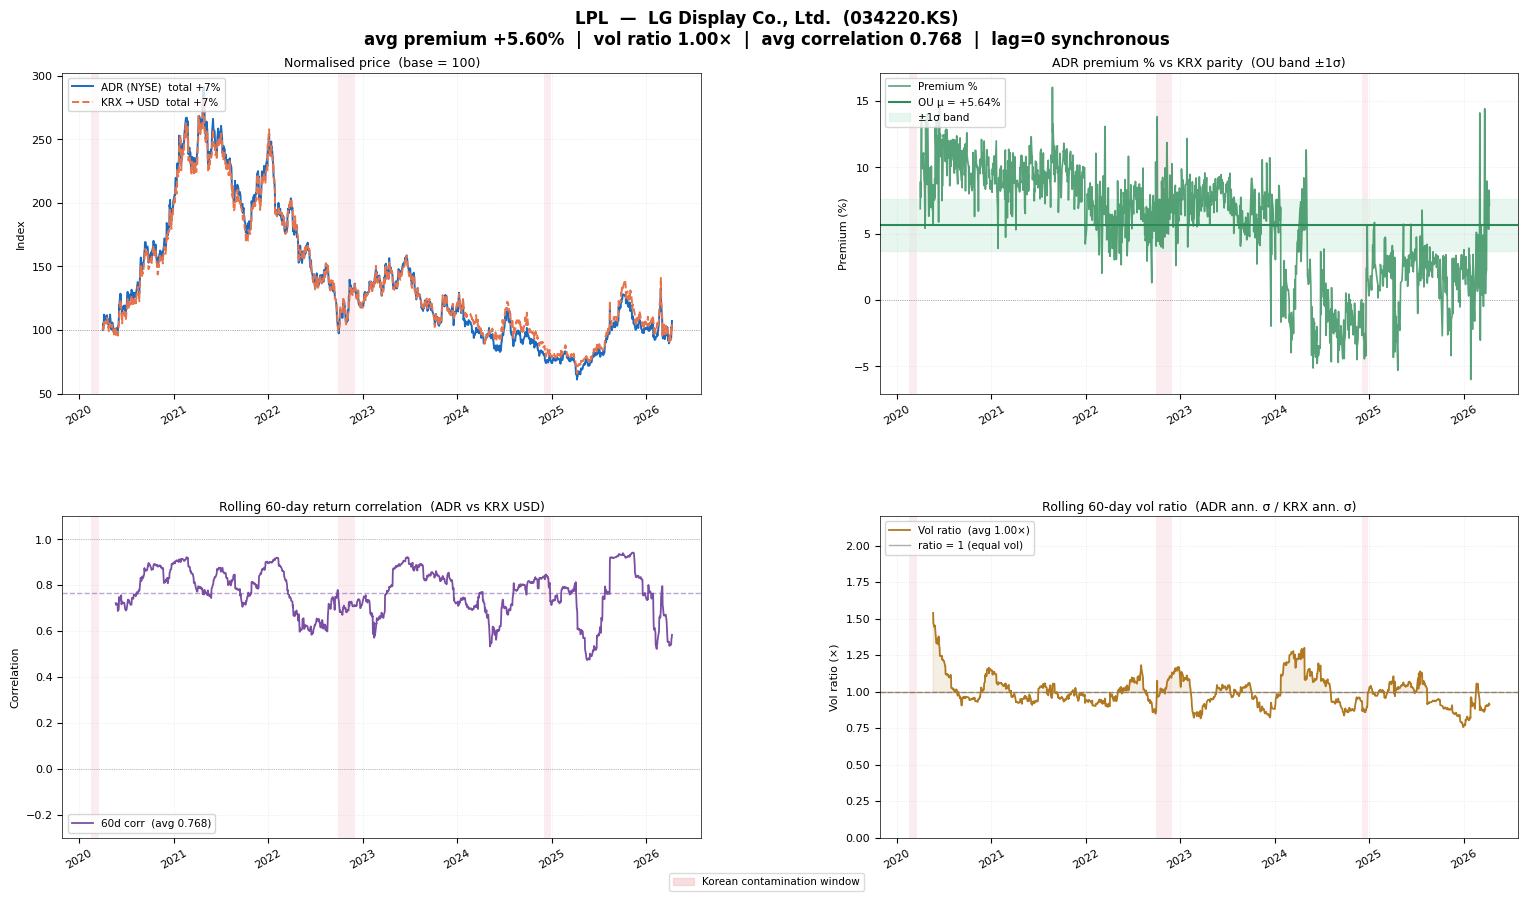

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_LPL.png

  SKM (SK Telecom Co., Ltd.):
    Avg premium=+9.82%  |  Avg vol ratio=0.98x  |  Avg roll-corr=0.737  |  lag=-1d KRX leads
    Total return: ADR=+207.7%  KRX(USD)=+170.6%


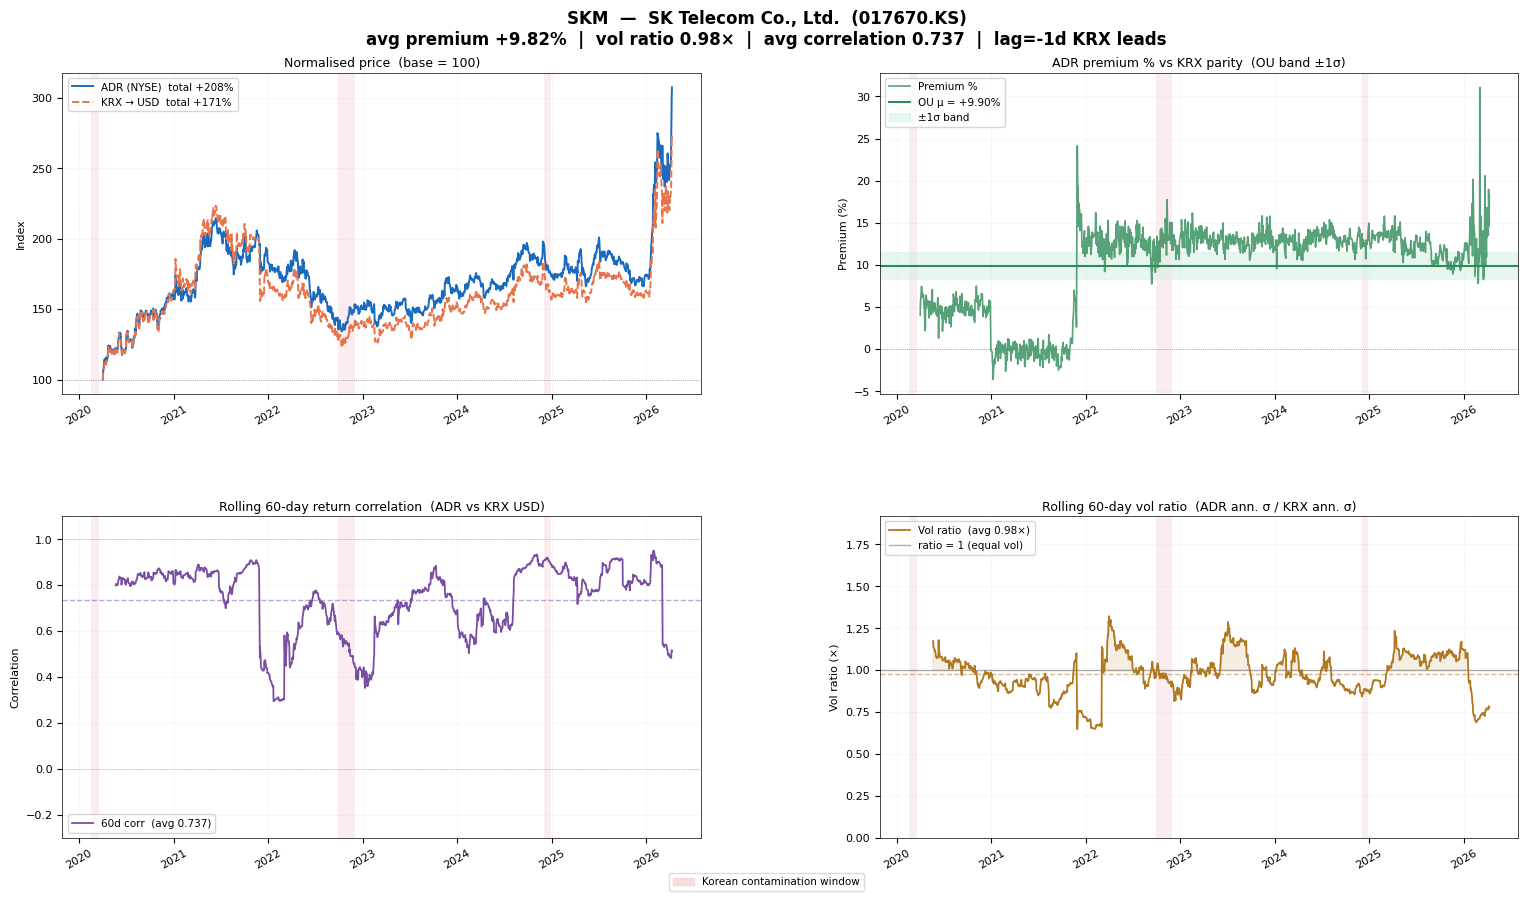

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_SKM.png

  KT (KT Corporation):
    Avg premium=+6.15%  |  Avg vol ratio=0.95x  |  Avg roll-corr=0.684  |  lag=-1d KRX leads
    Total return: ADR=+264.7%  KRX(USD)=+259.9%


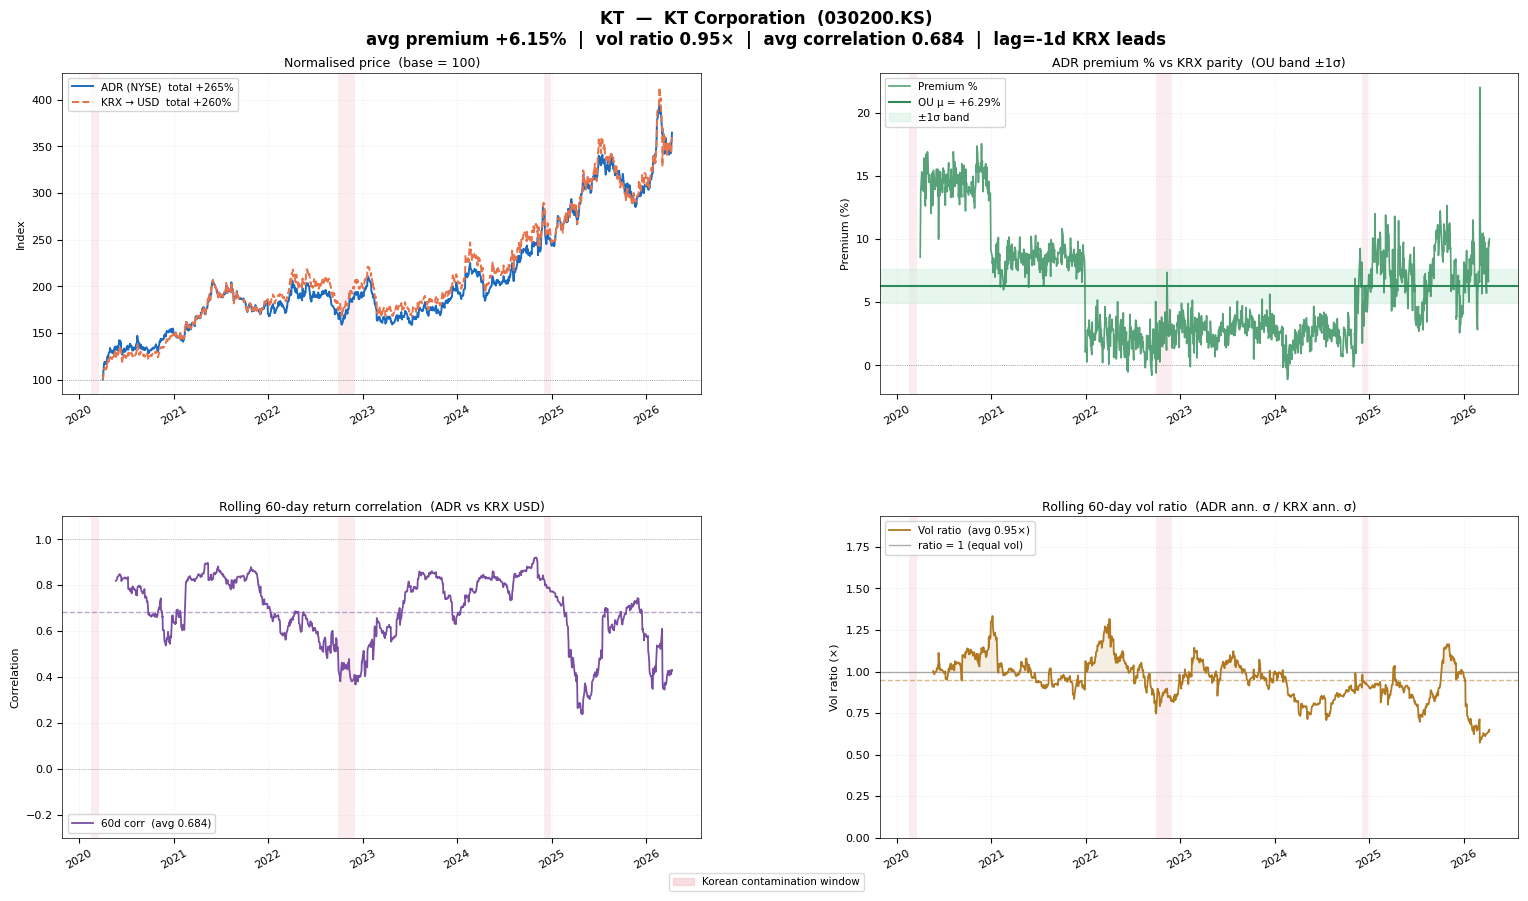

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_KT.png

  PKX (POSCO Holdings Inc.):
    Avg premium=+3.07%  |  Avg vol ratio=0.95x  |  Avg roll-corr=0.753  |  lag=-2d KRX leads
    Total return: ADR=+126.6%  KRX(USD)=+139.6%


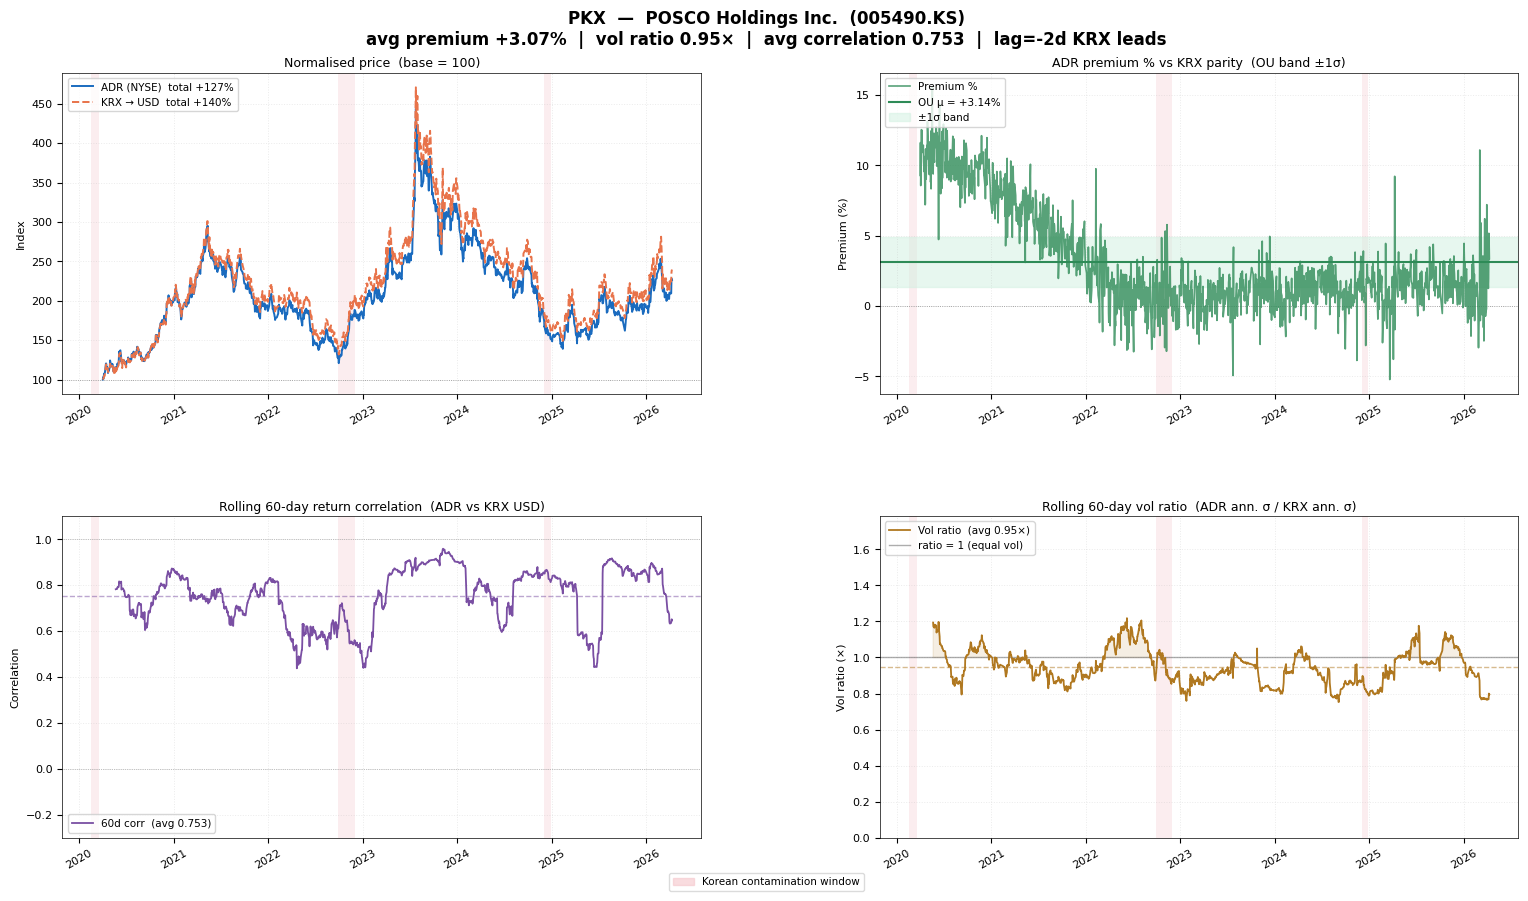

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_PKX.png

  KEP (Korea Electric Power Corporation (KEPCO)):
    Avg premium=+3.73%  |  Avg vol ratio=0.99x  |  Avg roll-corr=0.826  |  lag=-2d KRX leads
    Total return: ADR=+98.7%  KRX(USD)=+103.3%


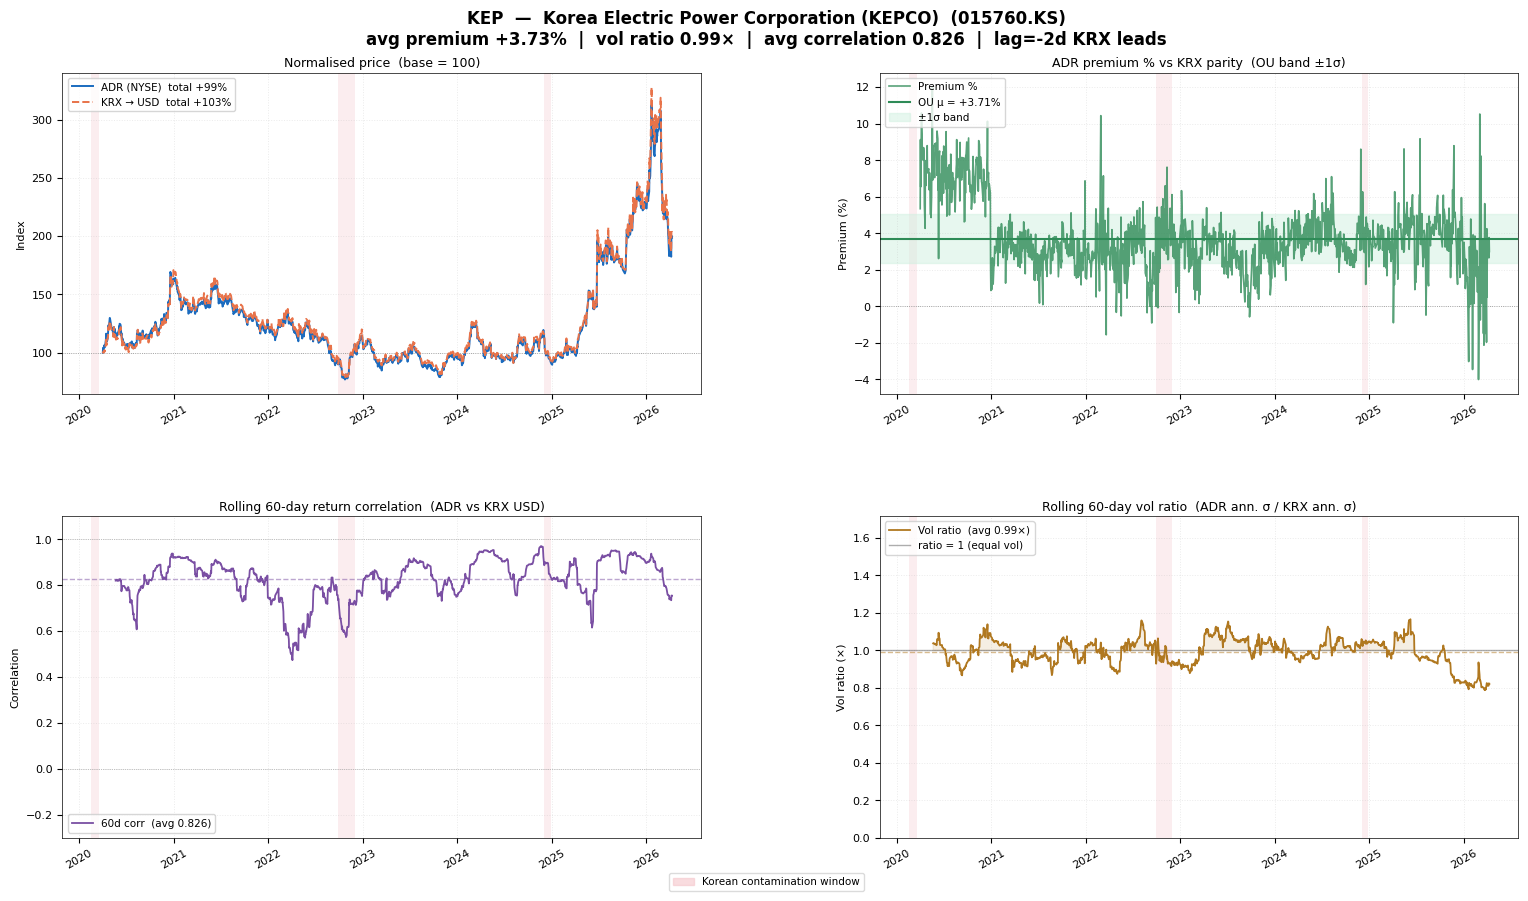

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_KEP.png

  KB (KB Financial Group Inc.):
    Avg premium=+3.69%  |  Avg vol ratio=0.92x  |  Avg roll-corr=0.751  |  lag=0 synchronous
    Total return: ADR=+422.2%  KRX(USD)=+440.3%


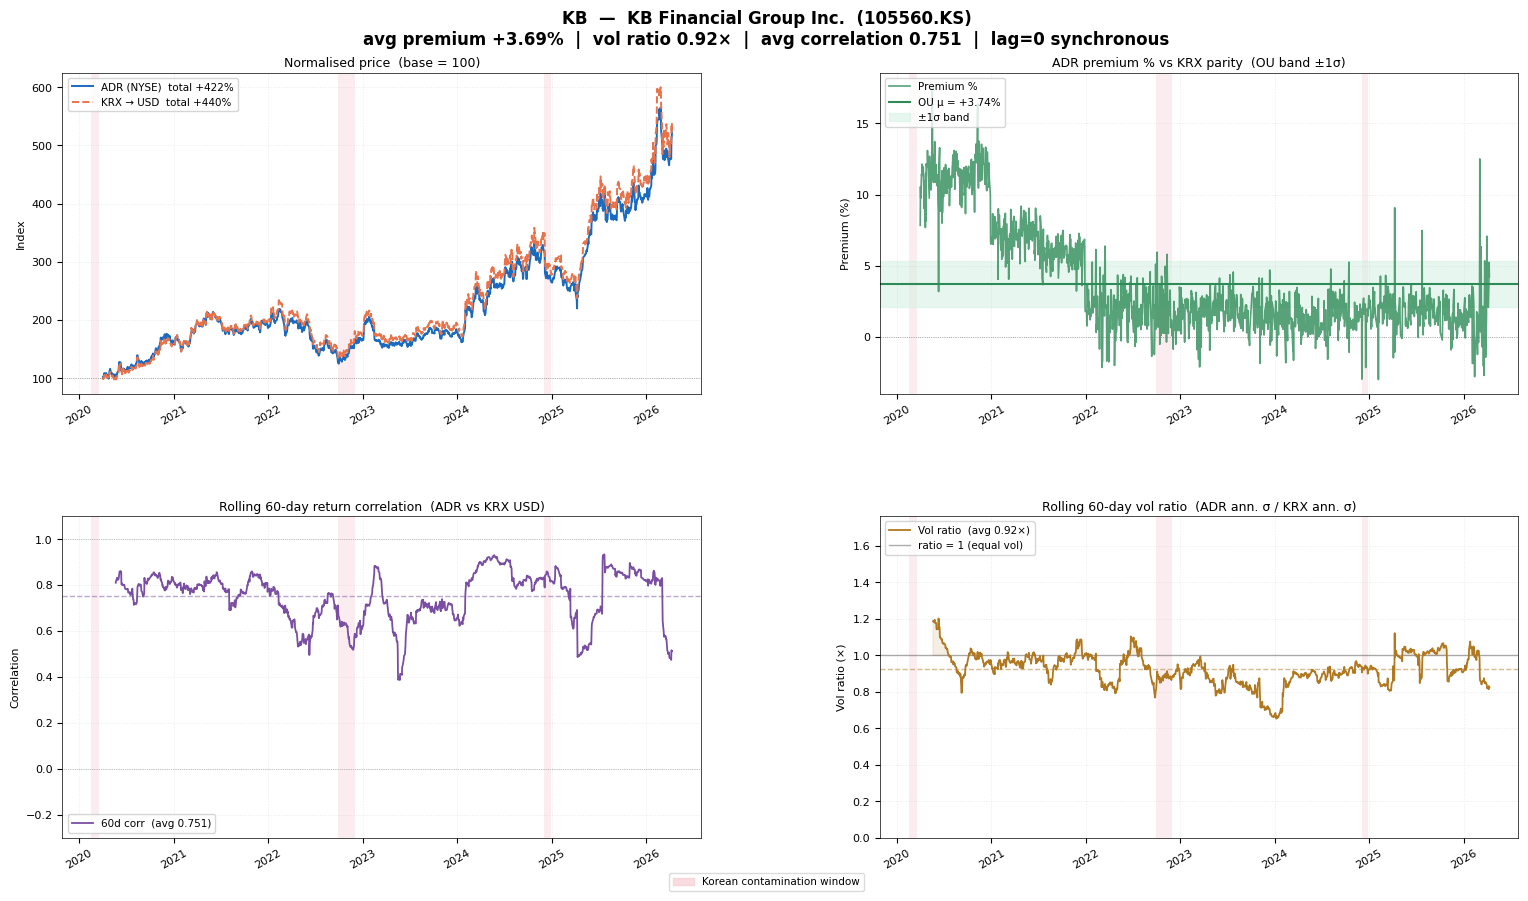

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_KB.png

  SHG (Shinhan Financial Group Co., Ltd.):
    Avg premium=+3.03%  |  Avg vol ratio=0.96x  |  Avg roll-corr=0.740  |  lag=-1d KRX leads
    Total return: ADR=+272.9%  KRX(USD)=+300.8%


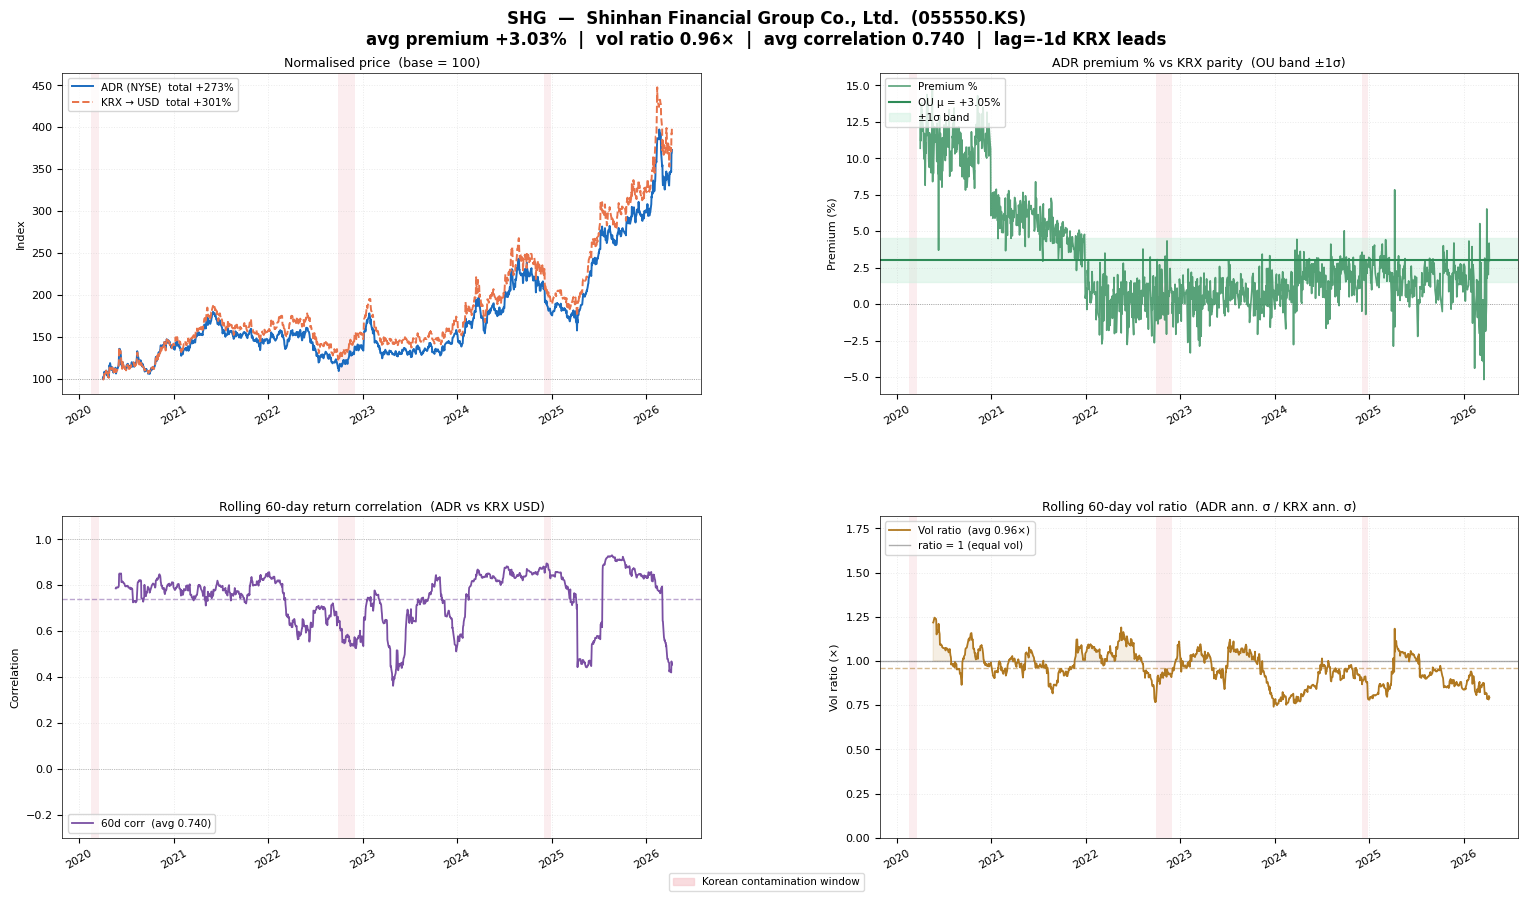

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_SHG.png

  WF (Woori Financial Group Inc.):
    Avg premium=+3.06%  |  Avg vol ratio=1.06x  |  Avg roll-corr=0.682  |  lag=0 synchronous
    Total return: ADR=+444.6%  KRX(USD)=+467.2%


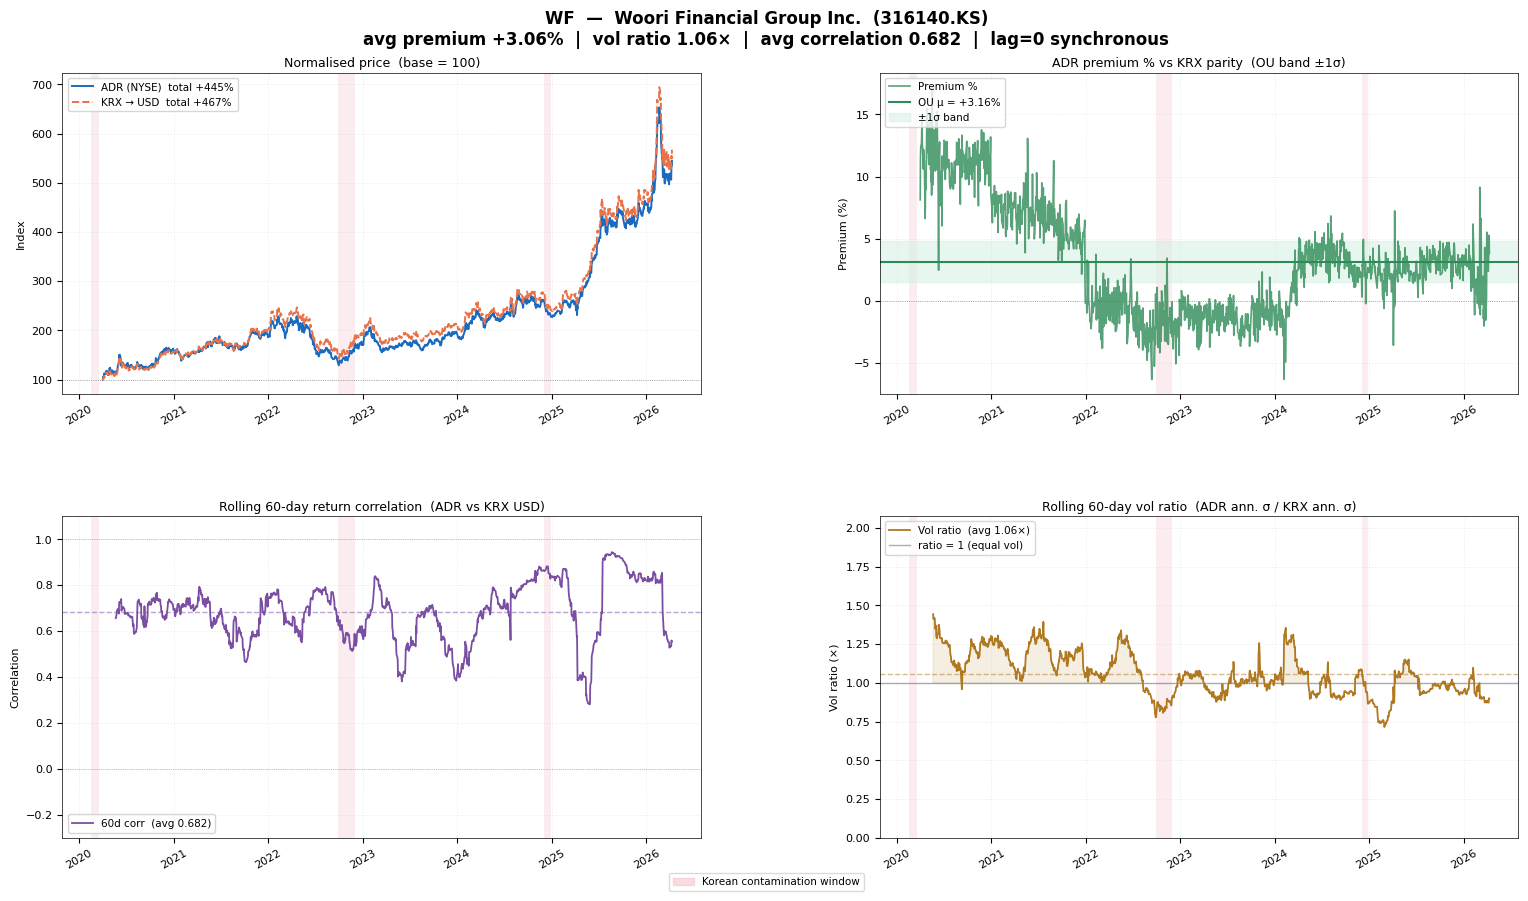

  ✅  Saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_compare_WF.png

  8 comparison charts saved to: /content/drive/My Drive/investment/investment_us/pricing_results

✅  Cell KE-02b done.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-02b — COMPARATIVE CHARTS: ADR vs KRX HISTORICAL PRICE            ║
# ║                                                                              ║
# ║  Per ADR, four-panel chart:                                                  ║
# ║    [TL] Normalised price (base 100) — ADR vs KRX in USD                   ║
# ║    [TR] ADR premium % over time + OU equilibrium band                      ║
# ║    [BL] Rolling 60-day return correlation (ADR vs KRX)                     ║
# ║    [BR] Rolling 60-day vol ratio (ADR σ / KRX σ in USD)                   ║
# ║                                                                              ║
# ║  Korean contamination windows shaded in pink on all panels.                ║
# ║  Charts saved to RESULT_DIR as PNG.                                         ║
# ║                                                                              ║
# ║  Requires: Cell KE-00 through KE-02                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os, warnings
warnings.filterwarnings('ignore')

ROLL_WINDOW = 60     # days for rolling stats
MIN_ROLL    = 30     # minimum obs for rolling window

print('=' * 72)
print('  CELL KE-02b — Comparative Charts: ADR vs KRX Historical Price')
print('=' * 72)

# ── Helper: shade contamination windows on an axes ────────────────────────────
def shade_contamination(ax, ymin, ymax):
    for key, r in KR_REGIMES.items():
        if r['type'] not in KR_CONTAMINATION_TYPES:
            continue
        ax.axvspan(r['start'], r['end'],
                   color='#f5c6cb', alpha=0.30, zorder=0, lw=0)

def fmt_ax(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.25, ls=':', lw=0.7)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

charts_saved = []

for adr in available_pairs:

    info    = KE_ADR_REGISTRY[adr]
    krx     = info['krx_ticker']
    ratio   = info['adr_ratio']
    name    = info['english_name']

    # ── Build aligned daily series ────────────────────────────────────────────
    adr_px  = px_adr[adr].dropna() if adr in px_adr.columns else pd.Series(dtype=float)
    krx_px  = px_krx_krw[krx].dropna() if krx in px_krx_krw.columns else pd.Series(dtype=float)
    fx_al   = USDKRW_DAILY.reindex(krx_px.index, method='ffill')
    krx_usd = (krx_px * ratio) / fx_al      # KRX converted to USD parity

    # Align to common index
    idx     = adr_px.index.intersection(krx_usd.index)
    if len(idx) < 60:
        print(f'  {adr}: insufficient overlap ({len(idx)} days) — skipping')
        continue

    adr_s   = adr_px.loc[idx]
    krx_s   = krx_usd.loc[idx]
    prem_s  = premium_disc.get(adr, pd.Series(dtype=float)).reindex(idx, method='ffill').dropna()
    ou_mu   = float(prem_stats.get(adr, {}).get('ou_mu', prem_s.mean() if len(prem_s) else 0))
    ou_sig  = float(prem_stats.get(adr, {}).get('ou_sigma',
                    prem_s.std() if len(prem_s) else 0))

    # ── Daily returns for rolling stats ───────────────────────────────────────
    adr_ret = adr_s.pct_change().dropna()
    krx_ret = krx_s.reindex(adr_ret.index).pct_change().dropna()
    com_ret_idx = adr_ret.index.intersection(krx_ret.index)
    adr_r   = adr_ret.loc[com_ret_idx]
    krx_r   = krx_ret.loc[com_ret_idx]

    roll_corr = adr_r.rolling(ROLL_WINDOW, min_periods=MIN_ROLL).corr(krx_r)
    roll_vol_adr = adr_r.rolling(ROLL_WINDOW, min_periods=MIN_ROLL).std() * np.sqrt(252)
    roll_vol_krx = krx_r.rolling(ROLL_WINDOW, min_periods=MIN_ROLL).std() * np.sqrt(252)
    roll_vol_ratio = (roll_vol_adr / roll_vol_krx.replace(0, np.nan)).clip(0, 4)

    # ── Lag analysis (cross-correlation, lags -5 to +5 trading days) ─────────
    lag_corrs = {}
    for lag in range(-5, 6):
        if lag == 0:
            c = adr_r.corr(krx_r)
        elif lag > 0:
            c = adr_r.iloc[lag:].corr(krx_r.iloc[:-lag])
        else:
            c = adr_r.iloc[:lag].corr(krx_r.iloc[-lag:])
        lag_corrs[lag] = round(c, 4)
    best_lag = max(lag_corrs, key=lag_corrs.get)
    lag_desc = (f'lag={best_lag:+d}d KRX leads' if best_lag < 0
                else f'lag={best_lag:+d}d ADR leads' if best_lag > 0
                else 'lag=0 synchronous')

    # ── Summary stats ─────────────────────────────────────────────────────────
    avg_prem    = float(prem_s.mean()) * 100 if len(prem_s) > 0 else np.nan
    avg_vr      = float(roll_vol_ratio.dropna().mean()) if len(roll_vol_ratio.dropna()) > 0 else np.nan
    avg_corr    = float(roll_corr.dropna().mean()) if len(roll_corr.dropna()) > 0 else np.nan
    total_ret_adr = (adr_s.iloc[-1] / adr_s.iloc[0] - 1) * 100
    total_ret_krx = (krx_s.iloc[-1] / krx_s.iloc[0] - 1) * 100

    print(f'\n  {adr} ({name}):')
    print(f'    Avg premium={avg_prem:+.2f}%  |  '
          f'Avg vol ratio={avg_vr:.2f}x  |  '
          f'Avg roll-corr={avg_corr:.3f}  |  {lag_desc}')
    print(f'    Total return: ADR={total_ret_adr:+.1f}%  KRX(USD)={total_ret_krx:+.1f}%')

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 9), facecolor='white')
    fig.suptitle(
        f'{adr}  —  {name}  ({krx})\n'
        f'avg premium {avg_prem:+.2f}%  |  vol ratio {avg_vr:.2f}×  |  '
        f'avg correlation {avg_corr:.3f}  |  {lag_desc}',
        fontsize=12, fontweight='bold', y=0.99)

    gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28,
                  left=0.06, right=0.97, top=0.92, bottom=0.07)

    C_ADR  = '#1a6bbf'
    C_KRX  = '#e8734a'
    C_PREM = '#2e8b57'
    C_BAND = '#d0f0e0'
    C_CORR = '#7a4fa3'
    C_VR   = '#b07820'

    # ── Panel 1: Normalised price ─────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    base_a, base_k = float(adr_s.iloc[0]), float(krx_s.iloc[0])
    ax1.plot(adr_s.index, adr_s / base_a * 100, color=C_ADR, lw=1.4,
             label=f'ADR (NYSE)  total {total_ret_adr:+.0f}%', zorder=3)
    ax1.plot(krx_s.index, krx_s / base_k * 100, color=C_KRX, lw=1.4,
             ls='--', label=f'KRX → USD  total {total_ret_krx:+.0f}%', zorder=3)
    shade_contamination(ax1, 80, 250)
    ax1.axhline(100, color='#888', lw=0.6, ls=':', zorder=1)
    ax1.set_title('Normalised price  (base = 100)', fontsize=9, pad=4)
    ax1.set_ylabel('Index', fontsize=8)
    ax1.legend(fontsize=7.5, loc='upper left', framealpha=0.8)
    fmt_ax(ax1)

    # ── Panel 2: ADR premium % + OU band ─────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    if len(prem_s) > 0:
        ax2.plot(prem_s.index, prem_s * 100, color=C_PREM, lw=1.2,
                 label='Premium %', zorder=3, alpha=0.8)
        # OU equilibrium band  ±1σ
        ax2.axhline(ou_mu * 100, color=C_PREM, lw=1.5, ls='-', zorder=2,
                    label=f'OU μ = {ou_mu*100:+.2f}%')
        ax2.axhspan((ou_mu - ou_sig) * 100, (ou_mu + ou_sig) * 100,
                    color=C_BAND, alpha=0.5, zorder=1, label='±1σ band')
        ax2.axhline(0, color='#888', lw=0.6, ls=':', zorder=1)
    shade_contamination(ax2, -20, 40)
    ax2.set_title('ADR premium % vs KRX parity  (OU band ±1σ)', fontsize=9, pad=4)
    ax2.set_ylabel('Premium (%)', fontsize=8)
    ax2.legend(fontsize=7.5, loc='upper left', framealpha=0.8)
    fmt_ax(ax2)

    # ── Panel 3: Rolling 60-day correlation ───────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(roll_corr.index, roll_corr.values, color=C_CORR, lw=1.3,
             label=f'60d corr  (avg {avg_corr:.3f})', zorder=3)
    ax3.axhline(avg_corr, color=C_CORR, lw=1.0, ls='--', alpha=0.5, zorder=2)
    ax3.axhline(1.0, color='#888', lw=0.5, ls=':', zorder=1)
    ax3.axhline(0.0, color='#888', lw=0.5, ls=':', zorder=1)
    shade_contamination(ax3, -0.5, 1.1)
    ax3.set_ylim(-0.3, 1.1)
    ax3.set_title('Rolling 60-day return correlation  (ADR vs KRX USD)', fontsize=9, pad=4)
    ax3.set_ylabel('Correlation', fontsize=8)
    ax3.legend(fontsize=7.5, loc='lower left', framealpha=0.8)
    fmt_ax(ax3)

    # ── Panel 4: Rolling vol ratio ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(roll_vol_ratio.index, roll_vol_ratio.values, color=C_VR, lw=1.3,
             label=f'Vol ratio  (avg {avg_vr:.2f}×)', zorder=3)
    ax4.axhline(avg_vr, color=C_VR, lw=1.0, ls='--', alpha=0.5, zorder=2)
    ax4.axhline(1.0, color='#333', lw=1.0, ls='-', alpha=0.4, zorder=2,
                label='ratio = 1 (equal vol)')
    shade_contamination(ax4, 0, 4)
    ax4.set_ylim(0, min(4, roll_vol_ratio.dropna().max() * 1.3 + 0.2))
    ax4.set_title('Rolling 60-day vol ratio  (ADR ann. σ / KRX ann. σ)', fontsize=9, pad=4)
    ax4.set_ylabel('Vol ratio (×)', fontsize=8)
    ax4.legend(fontsize=7.5, loc='upper left', framealpha=0.8)
    ax4.fill_between(roll_vol_ratio.index, 1.0, roll_vol_ratio.values,
                     where=roll_vol_ratio.values > 1.0,
                     color=C_VR, alpha=0.12, zorder=1)
    fmt_ax(ax4)

    # ── Contamination legend ──────────────────────────────────────────────────
    contam_patch = mpatches.Patch(color='#f5c6cb', alpha=0.6,
                                  label='Korean contamination window')
    fig.legend(handles=[contam_patch], loc='lower center',
               ncol=1, fontsize=7.5, framealpha=0.7,
               bbox_to_anchor=(0.5, 0.005))

    plt.tight_layout(rect=[0, 0.03, 1, 1])

    fname = f'ke_compare_{adr}.png'
    fpath = os.path.join(RESULT_DIR, fname)
    fig.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    charts_saved.append(fname)
    print(f'  ✅  Saved → {fpath}')

print(f'\n  {len(charts_saved)} comparison charts saved to: {RESULT_DIR}')
print(f'\n✅  Cell KE-02b done.')


## Cell KE-03 — Korean Fundamental Model (KRX leg, KRW terms)

KR-CAPM (KOSPI benchmark, BOK RF), Korean FF5, and Korean APT. All outputs in KRW. Primary fundamental signal.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-03 — KOREAN FUNDAMENTAL MODEL (KRX LEG, KRW TERMS)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print('  CELL KE-03 — Korean Fundamental Model (KRX leg, KRW terms)')
print('=' * 72)
print(f'  Benchmark : KOSPI 200')
print(f'  RF_KR     : {RF_KR_ANN:.2%} (BOK rate)')
print(f'  KR_MRP    : {KR_MRP_ANN:>+.2%} (KOSPI − RF_KR, annualised)')
print(f'  FF5 source: {KR_FF5_SOURCE}')

MIN_OBS_D = 60
MIN_OBS_M = 18

# KR_CPI_YOY excluded: only covers 2021-04 → 2024-03 (35/72 obs)
# Re-include once KE-02 data source is fixed (FRED: KORCPIALLMINMEI)
KR_APT_FACS_M_RUN = [f for f in KR_APT_FACS_M if f != 'KR_CPI_YOY']
print(f'  APT factors (CPI excluded): {KR_APT_FACS_M_RUN}')

print(f'\n  ── Contamination audit for KRX estimation ──')
kr_describe_window(START_DATE, END_DATE)

kr_fund_results = {}
kr_fund_rows    = []

def fwd_px_krw(krx_now_krw, er_krw_ann, cal_days):
    if np.isnan(krx_now_krw) or np.isnan(er_krw_ann) or cal_days <= 0:
        return np.nan
    return round(krx_now_krw * (1 + er_krw_ann) ** (cal_days / 365.25), 0)

def sig_kr(alpha_ann, pval, threshold=0.05):
    if pval < threshold and alpha_ann > 0: return 'UNDERPRICED +'
    if pval < threshold and alpha_ann < 0: return 'OVERPRICED  -'
    return 'FAIRLY PRICED'

for adr in available_pairs:
    info  = KE_ADR_REGISTRY[adr]
    krx   = info['krx_ticker']
    kr_fund_results[adr] = {}

    ret_krw = ret_krx_krw_d.get(adr, pd.Series(dtype=float)).dropna()
    if len(ret_krw) < MIN_OBS_D:
        print(f'\n  {adr} → {krx}: only {len(ret_krw)} KRW daily obs — skipping')
        continue

    lp_krw = float(px_krx_krw[krx].dropna().iloc[-1]) if krx in px_krx_krw else np.nan
    print(f'\n  ── {adr} → {krx}  ({info["english_name"]})  '
          f'KRX₩{lp_krw:,.0f}  n_d={len(ret_krw)} ──')

    # ── Model A: Korean CAPM ──────────────────────────────────────────────────
    kospi_aligned = KOSPI_D.reindex(ret_krw.index).dropna()
    rf_kr_aligned = rf_kr_d.reindex(ret_krw.index, method='ffill')
    idx_c = ret_krw.index.intersection(kospi_aligned.index)
    if len(idx_c) >= MIN_OBS_D:
        exc_c  = ret_krw.loc[idx_c] - rf_kr_aligned.loc[idx_c]
        mex_c  = kospi_aligned.loc[idx_c] - rf_kr_aligned.loc[idx_c]
        m_c    = sm.OLS(exc_c, sm.add_constant(mex_c)).fit()
        beta_k = float(m_c.params.iloc[1])
        aa_c   = float(m_c.params['const']) * 252
        ap_c   = float(m_c.pvalues['const'])
        er_c   = RF_KR_ANN + beta_k * KR_MRP_ANN
        sig_c  = sig_kr(aa_c, ap_c)
        tgt_c  = fwd_px_krw(lp_krw, er_c, CAL_DAYS)
        kr_fund_results[adr]['KR_CAPM'] = dict(
            beta_kospi=round(beta_k,4), alpha_ann_krw=round(aa_c,4),
            alpha_pval=round(ap_c,4), er_krw=round(er_c,4),
            rsq=round(m_c.rsquared,4), target_krw=tgt_c, signal=sig_c,
            n_obs=len(idx_c), model_label='KR_CAPM×Daily')
        print(f'    KR-CAPM  β_KOSPI={beta_k:>+.3f}  α={aa_c:>+.2%}  '
              f'p={ap_c:.4f}  E[r]={er_c:>+.2%}  Tgt₩{tgt_c:,.0f}  {sig_c}')

    # ── Model B: Korean FF5 ───────────────────────────────────────────────────
    if KR_FF5_D is not None and len(KR_FF5_D) > 0 and KR_FF5_FACS_D:
        fac_ff5 = KR_FF5_D[KR_FF5_FACS_D].reindex(ret_krw.index).dropna()
        rf_ff5  = (KR_FF5_D['RF_FF_KR'].reindex(ret_krw.index).dropna()
                   if 'RF_FF_KR' in KR_FF5_D.columns
                   else rf_kr_d.reindex(ret_krw.index, method='ffill'))
        idx_f   = ret_krw.index.intersection(fac_ff5.index)
        if len(idx_f) >= MIN_OBS_D:
            exc_f = ret_krw.loc[idx_f] - rf_ff5.reindex(idx_f, method='ffill')
            m_f   = sm.OLS(exc_f, sm.add_constant(fac_ff5.loc[idx_f])).fit()
            aa_f  = float(m_f.params['const']) * 252
            ap_f  = float(m_f.pvalues['const'])
            er_f  = (fac_ff5.loc[idx_f].values @ m_f.params[KR_FF5_FACS_D].values
                     + rf_ff5.reindex(idx_f, method='ffill').values).mean() * 252
            sig_f = sig_kr(aa_f, ap_f)
            tgt_f = fwd_px_krw(lp_krw, er_f, CAL_DAYS)
            betas_f = {f'beta_{c}': round(float(m_f.params.get(c, np.nan)), 4)
                       for c in KR_FF5_FACS_D}
            kr_fund_results[adr]['KR_FF5'] = dict(
                alpha_ann_krw=round(aa_f,4), alpha_pval=round(ap_f,4),
                er_krw=round(er_f,4), rsq=round(m_f.rsquared,4),
                target_krw=tgt_f, signal=sig_f, n_obs=len(idx_f),
                model_label='KR_FF5×Daily', ff5_source=KR_FF5_SOURCE,
                **betas_f)
            print(f'    KR-FF5   α={aa_f:>+.2%}  p={ap_f:.4f}  '
                  f'E[r]={er_f:>+.2%}  Tgt₩{tgt_f:,.0f}  {sig_f}  '
                  f'[{KR_FF5_SOURCE}]')

    # ── Model C: Korean APT ───────────────────────────────────────────────────
    try:
        if len(KR_APT_M) > 0 and KR_APT_FACS_M_RUN:
            ret_krw_m       = ret_krx_krw_m.get(adr, pd.Series(dtype=float)).dropna()
            rf_kr_m_aligned = rf_kr_m.reindex(ret_krw_m.index, method='ffill')
            fac_apt = (KR_APT_M[KR_APT_FACS_M_RUN]
                       .replace([np.inf, -np.inf], np.nan)
                       .reindex(ret_krw_m.index)
                       .dropna())
            idx_a = ret_krw_m.index.intersection(fac_apt.index)
            if len(idx_a) >= MIN_OBS_M:
                exc_a = (ret_krw_m.loc[idx_a]
                         - rf_kr_m_aligned.reindex(idx_a, method='ffill')
                         ).replace([np.inf, -np.inf], np.nan)
                X_a   = sm.add_constant(fac_apt.loc[idx_a])
                valid = exc_a.notna() & X_a.notna().all(axis=1)
                exc_a, X_a = exc_a[valid], X_a[valid]
                idx_a = exc_a.index
                if len(idx_a) >= MIN_OBS_M:
                    m_a  = sm.OLS(exc_a, X_a).fit()
                    aa_a = float(m_a.params['const']) * 12
                    ap_a = float(m_a.pvalues['const'])
                    er_a = (fac_apt.loc[idx_a].values @ m_a.params[KR_APT_FACS_M_RUN].values
                            + rf_kr_m_aligned.reindex(idx_a, method='ffill').values).mean() * 12
                    sig_a = sig_kr(aa_a, ap_a)
                    tgt_a = fwd_px_krw(lp_krw, er_a, CAL_DAYS)
                    kr_fund_results[adr]['KR_APT'] = dict(
                        alpha_ann_krw=round(aa_a,4), alpha_pval=round(ap_a,4),
                        er_krw=round(er_a,4), rsq=round(m_a.rsquared,4),
                        target_krw=tgt_a, signal=sig_a, n_obs=len(idx_a),
                        model_label='KR_APT×Monthly')
                    print(f'    KR-APT   α={aa_a:>+.2%}  p={ap_a:.4f}  '
                          f'E[r]={er_a:>+.2%}  Tgt₩{tgt_a:,.0f}  {sig_a}  '
                          f'[n={len(idx_a)}, factors={len(KR_APT_FACS_M_RUN)}]')
                else:
                    print(f'    KR-APT   ⚠️  only {len(idx_a)} clean obs after filtering — skipped')
            else:
                print(f'    KR-APT   ⚠️  only {len(idx_a)} obs after index intersection — skipped')
    except Exception as e:
        print(f'    KR-APT   ⚠️  skipped: {type(e).__name__}: {e}')

    # ── Consensus (trimmed mean across KRX models) ────────────────────────────
    er_vals = [v['er_krw'] for v in kr_fund_results[adr].values()
               if not np.isnan(v.get('er_krw', np.nan))]
    if er_vals:
        er_vals_s = sorted(er_vals)
        trim      = max(0, len(er_vals_s) // 5)
        er_kr_con = float(np.mean(er_vals_s[trim:len(er_vals_s)-trim] or er_vals_s))
        tgt_kr_con = fwd_px_krw(lp_krw, er_kr_con, CAL_DAYS)
    else:
        er_kr_con  = np.nan
        tgt_kr_con = np.nan

    kr_fund_results[adr]['_consensus_kr'] = {
        'er_krw':     er_kr_con,
        'target_krw': tgt_kr_con,
        'lp_krw':     lp_krw,
        'n_models':   len(er_vals),
    }
    print(f'    Consensus (KRW): E[r]={er_kr_con:>+.2%}  Tgt₩{tgt_kr_con:,.0f}')

    # ── Accumulate for DataFrame ──────────────────────────────────────────────
    for model_key, res in kr_fund_results[adr].items():
        if model_key.startswith('_'):
            continue
        row = {'ticker': adr, 'krx_ticker': krx,
               'english_name': info['english_name'],
               'model': model_key, 'lp_krw': lp_krw}
        row.update(res)
        kr_fund_rows.append(row)

kr_fund_df = pd.DataFrame(kr_fund_rows)
safe_save(kr_fund_df, 'ke_krx_fundamental_results.csv')
print(f'\n  Saved: ke_krx_fundamental_results.csv  ({len(kr_fund_df)} rows)')
print(f'\n✅  Cell KE-03 done.')

  CELL KE-03 — Korean Fundamental Model (KRX leg, KRW terms)
  Benchmark : KOSPI 200
  RF_KR     : 2.78% (BOK rate)
  KR_MRP    : +23.12% (KOSPI − RF_KR, annualised)
  FF5 source: ETF proxy
  APT factors (CPI excluded): ['KOSPI200', 'BOK_RATE_CHG', 'KTB_SPREAD_CHG', 'KRW_USD_RET', 'SEMICON_PROXY']

  ── Contamination audit for KRX estimation ──

  KR Window: 2020-04-01 to 2026-04-11
  Calendar days: 2201
  ⚠️  KR CONTAMINATION: 2 crash/shock regime(s):
      • Legoland CP Shock                   2022-09-28 to 2022-11-30
        CRITICAL contamination window. Korea-specific credit shock. KRX ADR premiums spiked artifi
      • Martial Law Shock                   2024-12-03 to 2024-12-27
        Korea-specific political shock. KRW fell sharply vs USD. ADR premiums/discounts shifted ar
  ➡  Shorten KRX estimation window or exclude these dates.

  ── LPL → 034220.KS  (LG Display Co., Ltd.)  KRX₩12,660  n_d=1474 ──
    KR-CAPM  β_KOSPI=+0.975  α=-12.42%  p=0.3803  E[r]=+25.33%  Tgt₩23,694  F

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-03b — SUMMARY STATISTICS: US vs KR EXPECTATIONS                  ║
# ║  (uses safe_save — file goes to Drive + local download automatically)      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-03b — SUMMARY STATISTICS COMPARING US/KR EXPECTATION                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


import yfinance as yf
import pandas as pd
import numpy as np

# ── FX + live US prices (refresh) ────────────────────────────────────────────
fx_raw  = yf.download("KRW=X", period="5d", auto_adjust=True, progress=False)["Close"]
USD_KRW = float(fx_raw.dropna().iloc[-1])
KRW_USD = 1 / USD_KRW

ADR_TICKERS = list(kr_fund_df['ticker'].unique())
px_raw  = yf.download(ADR_TICKERS, period="5d", auto_adjust=True, progress=False)["Close"]
if isinstance(px_raw, pd.Series):
    px_raw = px_raw.to_frame(ADR_TICKERS[0])
lp_usd  = px_raw.dropna().iloc[-1].to_dict()

print(f"USD/KRW: {USD_KRW:,.1f}")

# ── US-leg signals from prem_stats + parity_px ───────────────────────────────
def us_signal(arb_score, z):
    """
    arb_score: +1 = ADR cheap (LONG ADR), -1 = ADR expensive (SHORT ADR / prefer KRX)
    z        : OU z-score (positive = premium above mean = ADR expensive)
    """
    if arb_score > 0:  return 'UNDERPRICED (ADR)'
    if arb_score < 0:  return 'OVERPRICED  (ADR)'
    return 'FAIRLY PRICED'

# ── Build rows ────────────────────────────────────────────────────────────────
rows = []
for _, r in kr_fund_df.iterrows():
    tkr    = r['ticker']
    model  = r['model']
    ps     = prem_stats.get(tkr, {})
    px_us  = lp_usd.get(tkr, np.nan)
    px_kr  = r['lp_krw']
    ratio  = KE_ADR_REGISTRY[tkr]['adr_ratio']

    # ── Parity & premium ─────────────────────────────────────────────────────
    par_series  = parity_px.get(tkr, pd.Series(dtype=float))
    par_now_usd = float(par_series.dropna().iloc[-1]) if len(par_series) > 0 else np.nan
    # Parity in KRW: KRX price that the ADR implies
    par_now_krw = px_us / ratio * USD_KRW if not np.isnan(px_us) else np.nan

    prem_now    = ps.get('prem_now',      np.nan)   # ADR premium vs KRX (raw)
    prem_mean   = ps.get('ou_mu',         np.nan)   # OU long-run mean premium
    z_ou        = ps.get('z_score_ou',    np.nan)   # OU z-score
    arb_score   = ps.get('arb_score',     0)
    arb_dir     = ps.get('arb_direction', '—')
    ou_hl       = ps.get('ou_hl_days',    np.nan)
    conv_net    = ps.get('conv_net',      np.nan)   # net convergence return
    sig_us      = us_signal(arb_score, z_ou)

    # ── KR-leg: E[r] and alpha already in kr_fund_df ─────────────────────────
    er_krw      = r['er_krw']
    er_usd      = er_krw   # same expected return in USD terms (no FX hedge assumed)
    alpha_krw   = r['alpha_ann_krw']
    alpha_pval  = r['alpha_pval']
    sig_kr      = r['signal']

    # ── Factor loadings — model-specific ─────────────────────────────────────
    beta_kospi  = r.get('beta_kospi',    np.nan)
    beta_mkt    = r.get('beta_MKT_RF_KR',np.nan)
    beta_hml    = r.get('beta_HML_KR',   np.nan)
    rsq         = r.get('rsq',           np.nan)

    # ── Targets ──────────────────────────────────────────────────────────────
    tgt_krw     = r['target_krw']
    tgt_usd_kr  = tgt_krw * KRW_USD * ratio   # KRX target → implied ADR USD price
    upside_kr   = (tgt_krw / px_kr - 1) if not np.isnan(px_kr) else np.nan
    upside_us   = (tgt_usd_kr / px_us - 1) if not np.isnan(px_us) else np.nan

    rows.append({
        'Ticker':         tkr,
        'Name':           r['english_name'],
        'Model':          model,
        # ── Current prices ───────────────────────────────────────────────────
        'P_USD(ADR)':     round(px_us, 2)          if not np.isnan(px_us)  else np.nan,
        'P_KRW(KRX)':    int(px_kr)               if not np.isnan(px_kr)  else np.nan,
        'Parity_USD':     round(par_now_usd, 2)    if not np.isnan(par_now_usd) else np.nan,
        'Parity_KRW':     round(par_now_krw, 0)    if not np.isnan(par_now_krw) else np.nan,
        # ── ADR premium/discount ─────────────────────────────────────────────
        'Prem_now%':      round(prem_now * 100, 2) if not np.isnan(prem_now) else np.nan,
        'Prem_μ(OU)%':   round(prem_mean * 100, 2)if not np.isnan(prem_mean) else np.nan,
        'Z_OU':           round(z_ou, 3)           if not np.isnan(z_ou)   else np.nan,
        'OU_HL(days)':    round(ou_hl, 1)          if not np.isnan(ou_hl)  else np.nan,
        'Conv_net%':      round(conv_net * 100, 2) if not np.isnan(conv_net) else np.nan,
        # ── US-leg signal ────────────────────────────────────────────────────
        'Signal_US':      sig_us,
        # ── KR-leg model outputs ─────────────────────────────────────────────
        'E[r]_KRW':       er_krw,
        'α_KRW':          alpha_krw,
        'α_pval':         alpha_pval,
        'Signal_KR':      sig_kr,
        # ── Factor loadings ──────────────────────────────────────────────────
        'β_KOSPI':        beta_kospi,
        'β_MKT(FF5)':    beta_mkt,
        'β_HML(FF5)':    beta_hml,
        'R²':             rsq,
        # ── Targets & upside ─────────────────────────────────────────────────
        'Tgt_KRW':        int(tgt_krw)             if not np.isnan(tgt_krw) else np.nan,
        'Tgt_USD(impl)':  round(tgt_usd_kr, 2)     if not np.isnan(tgt_usd_kr) else np.nan,
        'Upside_KR%':     round(upside_kr * 100, 1)if not np.isnan(upside_kr) else np.nan,
        'Upside_US%':     round(upside_us * 100, 1)if not np.isnan(upside_us) else np.nan,
        'n_obs':          int(r['n_obs']),
    })

df_full = pd.DataFrame(rows)

# ── Display by model ──────────────────────────────────────────────────────────
FMT = {
    'P_USD(ADR)':    '${:.2f}'.format,
    'P_KRW(KRX)':   '₩{:,}'.format,
    'Parity_USD':    '${:.2f}'.format,
    'Parity_KRW':   '₩{:,.0f}'.format,
    'Prem_now%':     '{:+.2f}%'.format,
    'Prem_μ(OU)%':  '{:+.2f}%'.format,
    'Z_OU':          '{:+.3f}'.format,
    'OU_HL(days)':   '{:.1f}d'.format,
    'Conv_net%':     '{:+.2f}%'.format,
    'E[r]_KRW':      '{:+.1%}'.format,
    'α_KRW':         '{:+.1%}'.format,
    'α_pval':        '{:.3f}'.format,
    'β_KOSPI':       '{:+.3f}'.format,
    'β_MKT(FF5)':   '{:+.3f}'.format,
    'β_HML(FF5)':   '{:+.3f}'.format,
    'R²':            '{:.3f}'.format,
    'Tgt_KRW':       '₩{:,}'.format,
    'Tgt_USD(impl)': '${:.2f}'.format,
    'Upside_KR%':    '{:+.1f}%'.format,
    'Upside_US%':    '{:+.1f}%'.format,
}

# Columns common to all models (ADR premium block never changes)
COMMON_COLS = [
    'Ticker', 'Name',
    'P_USD(ADR)', 'P_KRW(KRX)', 'Parity_USD', 'Parity_KRW',
    'Prem_now%', 'Prem_μ(OU)%', 'Z_OU', 'OU_HL(days)', 'Conv_net%',
    'Signal_US',
    'E[r]_KRW', 'α_KRW', 'α_pval', 'Signal_KR',
]

MODEL_EXTRA = {
    'KR_CAPM': ['β_KOSPI',                       'R²', 'Tgt_KRW', 'Tgt_USD(impl)', 'Upside_KR%', 'Upside_US%', 'n_obs'],
    'KR_FF5':  ['β_MKT(FF5)', 'β_HML(FF5)',      'R²', 'Tgt_KRW', 'Tgt_USD(impl)', 'Upside_KR%', 'Upside_US%', 'n_obs'],
    'KR_APT':  [                                  'R²', 'Tgt_KRW', 'Tgt_USD(impl)', 'Upside_KR%', 'Upside_US%', 'n_obs'],
}

MODEL_LABEL = {
    'KR_CAPM': 'Model A — Korean CAPM  (Daily)',
    'KR_FF5':  'Model B — Korean FF5   (Daily, ETF proxy)',
    'KR_APT':  'Model C — Korean APT   (Monthly, CPI excl.)',
}

for model in ['KR_CAPM', 'KR_FF5', 'KR_APT']:
    sub   = df_full[df_full['Model'] == model].copy()
    cols  = COMMON_COLS + MODEL_EXTRA[model]
    sub   = sub[cols]

    sub_fmt = sub.copy()
    for col, fn in FMT.items():
        if col in sub_fmt.columns:
            sub_fmt[col] = sub_fmt[col].apply(
                lambda x: fn(x) if pd.notna(x) and x == x else '—')

    sep = '=' * 130
    print(f'\n{sep}')
    print(f'  {MODEL_LABEL[model]}')
    print(f'  FX: 1 USD = ₩{USD_KRW:,.1f}  |  '
          f'Signal_US = ADR premium vs KRX parity (OU mean-reversion)  |  '
          f'Signal_KR = alpha significance vs Korean factors')
    print(f'  Tgt_USD(impl) = KRX target × ADR ratio × KRW_USD  '
          f'(KRX-derived fair value in USD terms)')
    print(sep)
    print(sub_fmt.to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
safe_save(df_full, 'ke_krx_full_summary.csv', float_format='%.4f')
print(f'\n  Saved: ke_krx_full_summary.csv  ({len(df_full)} rows, {len(df_full.columns)} cols)')

USD/KRW: 1,482.7

  Model A — Korean CAPM  (Daily)
  FX: 1 USD = ₩1,482.7  |  Signal_US = ADR premium vs KRX parity (OU mean-reversion)  |  Signal_KR = alpha significance vs Korean factors
  Tgt_USD(impl) = KRX target × ADR ratio × KRW_USD  (KRX-derived fair value in USD terms)
Ticker                                     Name P_USD(ADR) P_KRW(KRX) Parity_USD Parity_KRW Prem_now% Prem_μ(OU)%   Z_OU OU_HL(days) Conv_net%         Signal_US E[r]_KRW  α_KRW α_pval     Signal_KR β_KOSPI    R²  Tgt_KRW Tgt_USD(impl) Upside_KR% Upside_US%  n_obs
   LPL                     LG Display Co., Ltd.      $4.49    ₩12,660      $4.19    ₩13,315    +7.12%      +5.64% +0.370        5.9d    +1.18% OVERPRICED  (ADR)   +25.3% -12.4%  0.380 FAIRLY PRICED  +0.975 0.307  ₩23,694         $7.99     +87.2%     +78.0%   1474
   SKM                     SK Telecom Co., Ltd.     $36.41    ₩93,000     $30.79   ₩107,970   +18.25%      +9.90% +1.622       14.7d    +8.05% OVERPRICED  (ADR)   +12.9% +11.4%  0.263 FAIRLY PR

## Cell KE-03r — Signal Robustness Test

Mirrors the US notebook's tier system for Korean factor models. Tests:

1. **Cross-frequency consistency** — do daily models (CAPM, FF5) and monthly model (APT) agree on direction? Disagreement → fragile signal.
2. **Cross-window stability** — do signals survive across three BOK regime sub-windows? Signal that only appears in one window is fragile.
3. **Alpha stability** — does alpha sign hold across sub-windows, or flip?
4. **Tier assignment** — TIER 1 (robust, all windows agree) → TIER 4 (conflicted, majority disagree).

Results feed into KE-05 as `robustness_tier` modifier on `kr_adj`.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-03r — SIGNAL ROBUSTNESS TEST                                      ║
# ║                                                                              ║
# ║  Mirrors the US notebook tier system (TIER 1 ROBUST → TIER 4 CONFLICTED)  ║
# ║  for the Korean factor models.                                               ║
# ║                                                                              ║
# ║  TEST 1 — Cross-frequency consistency                                        ║
# ║    Daily models (CAPM, FF5) vs Monthly model (APT).                         ║
# ║    If daily majority ≠ monthly → MIXED FREQUENCY (fragile)                  ║
# ║                                                                              ║
# ║  TEST 2 — Cross-window stability                                             ║
# ║    Three BOK regime sub-windows (re-runs CAPM on each):                     ║
# ║      W1: BOK Plateau       2023-01-13 → 2024-09-30  (rate hold)            ║
# ║      W2: BOK Cut + Martial 2024-10-11 → 2024-12-27  (shock window)         ║
# ║      W3: Post-Shock        2024-12-28 → today        (current)              ║
# ║    Signal must survive in ≥2/3 windows to be ROBUST.                       ║
# ║                                                                              ║
# ║  TEST 3 — Alpha sign stability across sub-windows                           ║
# ║    If alpha flips sign across windows → UNSTABLE (fragile)                  ║
# ║                                                                              ║
# ║  TIER ASSIGNMENT:                                                            ║
# ║    TIER 1 — Cross-freq consistent + stable across ≥2/3 windows             ║
# ║    TIER 2 — Cross-freq consistent OR stable, not both                       ║
# ║    TIER 3 — One test passes, majority fails                                 ║
# ║    TIER 4 — Both tests fail (conflicted)                                    ║
# ║                                                                              ║
# ║  Output: kr_robustness dict — consumed by KE-05 kr_adj modifier            ║
# ║  Requires: Cell KE-00 through KE-03                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print('  CELL KE-03r — Signal Robustness Test')
print('=' * 72)

# ── Sub-window definitions (BOK regime boundaries) ────────────────────────────
ROBUST_WINDOWS = {
    'W1_plateau':     (datetime(2023, 1, 13),  datetime(2024, 9, 30),  'BOK Plateau 3.50%'),
    'W2_cut_martial': (datetime(2024, 10, 11), datetime(2024, 12, 27), 'BOK Cut + Martial Law'),
    'W3_recovery':    (datetime(2024, 12, 28), END_DATE,               'Post-Shock Recovery'),
}

MIN_OBS_ROBUST = 40   # minimum daily obs to run sub-window regression

# ── Direction helper ──────────────────────────────────────────────────────────
def er_direction(er, hurdle=RF_KR_ANN):
    """+1 = above hurdle (bullish), -1 = below (bearish), 0 = missing."""
    if np.isnan(er): return 0
    return +1 if er > hurdle else -1

def alpha_sign(alpha):
    if np.isnan(alpha): return 0
    return +1 if alpha > 0 else -1

# ── Sub-window CAPM runner ────────────────────────────────────────────────────
def run_capm_subwindow(ret_krw_d, w_start, w_end, label):
    """
    Run KR-CAPM on a sub-window. Returns dict with er_krw, alpha, pval, n_obs
    or None if insufficient data.
    """
    mask = (ret_krw_d.index >= pd.Timestamp(w_start)) & \
           (ret_krw_d.index <= pd.Timestamp(w_end))
    ret_sub = ret_krw_d[mask].dropna()
    if len(ret_sub) < MIN_OBS_ROBUST:
        return None

    kospi_sub  = KOSPI_D.reindex(ret_sub.index).dropna()
    rf_sub     = rf_kr_d.reindex(ret_sub.index, method='ffill')
    idx        = ret_sub.index.intersection(kospi_sub.index)
    if len(idx) < MIN_OBS_ROBUST:
        return None

    exc  = ret_sub.loc[idx] - rf_sub.loc[idx]
    mex  = kospi_sub.loc[idx] - rf_sub.loc[idx]
    try:
        m = sm.OLS(exc, sm.add_constant(mex)).fit()
        beta  = float(m.params.iloc[1])
        alpha = float(m.params['const']) * 252
        pval  = float(m.pvalues['const'])
        er    = RF_KR_ANN + beta * KR_MRP_ANN
        return {'er_krw': er, 'alpha': alpha, 'pval': pval,
                'beta': beta, 'rsq': m.rsquared, 'n_obs': len(idx)}
    except Exception:
        return None

# ── Main robustness loop ──────────────────────────────────────────────────────
kr_robustness = {}   # {adr: robustness_dict} — consumed by KE-05

print(f'\n  Sub-windows:')
for wk, (ws, we, wl) in ROBUST_WINDOWS.items():
    print(f'    {wk:<20}  {ws.date()} → {we.date()}  ({wl})')
print(f'  Min obs per window: {MIN_OBS_ROBUST}')
print(f'  Hurdle: {RF_KR_ANN:.2%}  (BOK RF)')

for adr in available_pairs:
    kr_c    = kr_fund_results.get(adr, {})
    ret_krw = ret_krx_krw_d.get(adr, pd.Series(dtype=float)).dropna()

    print(f'\n  ── {adr} ──────────────────────────────────────────────────────')

    # ── TEST 1: Cross-frequency consistency ───────────────────────────────────
    # Daily models: CAPM, FF5  →  E[r] direction
    # Monthly model: APT       →  E[r] direction
    daily_models  = ['KR_CAPM', 'KR_FF5']
    monthly_model = 'KR_APT'

    daily_dirs = []
    for m in daily_models:
        er = kr_c.get(m, {}).get('er_krw', np.nan)
        d  = er_direction(er)
        if d != 0:
            daily_dirs.append(d)

    apt_er  = kr_c.get(monthly_model, {}).get('er_krw', np.nan)
    apt_dir = er_direction(apt_er)

    if daily_dirs:
        daily_consensus = +1 if sum(daily_dirs) > 0 else -1
    else:
        daily_consensus = 0

    if daily_consensus != 0 and apt_dir != 0:
        cross_freq_ok = (daily_consensus == apt_dir)
    else:
        cross_freq_ok = None   # cannot assess

    cross_freq_label = ('CONSISTENT ✓' if cross_freq_ok is True
                        else 'MIXED ✗' if cross_freq_ok is False
                        else 'INCOMPLETE (model missing)')

    daily_er_str = '  '.join(
        f'{m}={kr_c.get(m,{}).get("er_krw",np.nan):>+.2%}'
        for m in daily_models
        if not np.isnan(kr_c.get(m,{}).get('er_krw', np.nan)))
    print(f'    TEST 1 — Cross-frequency:')
    print(f'      Daily  ({daily_er_str})  consensus={daily_consensus:>+d}')
    print(f'      APT    E[r]={apt_er:>+.2%}  dir={apt_dir:>+d}')
    print(f'      Result: {cross_freq_label}')

    # ── TEST 2: Cross-window stability (CAPM re-runs on sub-windows) ──────────
    window_results = {}
    for wk, (ws, we, wl) in ROBUST_WINDOWS.items():
        res = run_capm_subwindow(ret_krw, ws, we, wl)
        window_results[wk] = res

    window_dirs   = []
    window_alphas = []
    print(f'    TEST 2 — Cross-window stability (CAPM re-runs):')
    for wk, (ws, we, wl) in ROBUST_WINDOWS.items():
        res = window_results[wk]
        if res is None:
            print(f'      {wl:<30}  INSUFFICIENT DATA (<{MIN_OBS_ROBUST} obs)')
            continue
        d = er_direction(res['er_krw'])
        a = alpha_sign(res['alpha'])
        window_dirs.append(d)
        window_alphas.append(a)
        sig_flag = '✓' if res['pval'] < 0.10 else ' '
        print(f'      {wl:<30}  E[r]={res["er_krw"]:>+.2%}  '
              f'α={res["alpha"]:>+.2%}(p={res["pval"]:.3f}){sig_flag}  '
              f'n={res["n_obs"]}  dir={d:>+d}')

    # Signal stability: majority of windows agree on direction
    if len(window_dirs) >= 2:
        n_positive = sum(1 for d in window_dirs if d > 0)
        n_negative = sum(1 for d in window_dirs if d < 0)
        majority_dir = +1 if n_positive > n_negative else -1
        n_agree = max(n_positive, n_negative)
        cross_window_ok = (n_agree >= 2)   # at least 2/3 windows agree

        # Alpha stability: all available alphas same sign
        if len(window_alphas) >= 2:
            n_pos_alpha = sum(1 for a in window_alphas if a > 0)
            alpha_stable = (n_pos_alpha == len(window_alphas) or
                            n_pos_alpha == 0)
        else:
            alpha_stable = True   # only one window, cannot assess

        cross_window_label = (f'STABLE ✓ ({n_agree}/{len(window_dirs)} windows agree, '
                              f'dir={majority_dir:>+d})'
                              if cross_window_ok
                              else f'UNSTABLE ✗ (split {n_positive}↑/{n_negative}↓)')
        alpha_stable_label = 'STABLE ✓' if alpha_stable else 'FLIPS ✗'
    else:
        cross_window_ok  = None
        alpha_stable     = None
        majority_dir     = daily_consensus
        cross_window_label = 'INSUFFICIENT WINDOWS'
        alpha_stable_label = 'N/A'

    print(f'      Window stability: {cross_window_label}')
    print(f'      Alpha sign      : {alpha_stable_label}')

    # ── TIER ASSIGNMENT ───────────────────────────────────────────────────────
    # Count passing tests
    tests_pass = 0
    if cross_freq_ok is True:   tests_pass += 1
    if cross_window_ok is True: tests_pass += 1
    if alpha_stable is True:    tests_pass += 1

    total_tests = sum([
        cross_freq_ok is not None,
        cross_window_ok is not None,
        alpha_stable is not None,
    ])

    if total_tests == 0:
        tier = 'TIER 3 — FRAGILE'
        tier_score = 0
    elif tests_pass == total_tests:
        tier = 'TIER 1 — ROBUST'
        tier_score = +1     # boost kr_adj in KE-05
    elif tests_pass >= total_tests - 1:
        tier = 'TIER 2 — PROBABLE'
        tier_score = 0      # no change to kr_adj
    elif tests_pass >= 1:
        tier = 'TIER 3 — FRAGILE'
        tier_score = -1     # downgrade kr_adj in KE-05
    else:
        tier = 'TIER 4 — CONFLICTED'
        tier_score = -2     # hard downgrade

    print(f'\n    ── TIER: {tier}  (tests passed: {tests_pass}/{total_tests})')

    kr_robustness[adr] = {
        'cross_freq_ok':    cross_freq_ok,
        'cross_freq_label': cross_freq_label,
        'cross_window_ok':  cross_window_ok,
        'alpha_stable':     alpha_stable,
        'window_results':   window_results,
        'majority_dir':     majority_dir,
        'tier':             tier,
        'tier_score':       tier_score,
        'tests_pass':       tests_pass,
        'total_tests':      total_tests,
    }

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"=" * 72}')
print(f'  ROBUSTNESS SUMMARY')
print(f'{"=" * 72}')
print(f'\n  {"ADR":<8}  {"CrossFreq":<15}  {"CrossWin":<10}  '
      f'{"AlphaStab":<12}  {"Pass/Tot":<10}  Tier')
print('  ' + '─' * 75)

for adr, rb in kr_robustness.items():
    cf = '✓' if rb['cross_freq_ok'] is True else ('✗' if rb['cross_freq_ok'] is False else '?')
    cw = '✓' if rb['cross_window_ok'] is True else ('✗' if rb['cross_window_ok'] is False else '?')
    al = '✓' if rb['alpha_stable'] is True else ('✗' if rb['alpha_stable'] is False else '?')
    pt = f'{rb["tests_pass"]}/{rb["total_tests"]}'
    print(f'  {adr:<8}  CrossFreq:{cf}  Window:{cw}  Alpha:{al}  '
          f'{pt:<10}  {rb["tier"]}')

print(f'\n  tier_score → KE-05 kr_adj modifier:')
print(f'    +1 = TIER 1 (robust)  →  kr_adj boosted')
print(f'     0 = TIER 2 (probable) →  kr_adj unchanged')
print(f'    -1 = TIER 3 (fragile)  →  kr_adj downgraded')
print(f'    -2 = TIER 4 (conflicted) →  kr_adj hard downgrade')
print(f'\n✅  Cell KE-03r done. kr_robustness available for KE-05.')


  CELL KE-03r — Signal Robustness Test

  Sub-windows:
    W1_plateau            2023-01-13 → 2024-09-30  (BOK Plateau 3.50%)
    W2_cut_martial        2024-10-11 → 2024-12-27  (BOK Cut + Martial Law)
    W3_recovery           2024-12-28 → 2026-04-11  (Post-Shock Recovery)
  Min obs per window: 40
  Hurdle: 2.78%  (BOK RF)

  ── LPL ──────────────────────────────────────────────────────
    TEST 1 — Cross-frequency:
      Daily  (KR_CAPM=+25.33%  KR_FF5=+15.40%)  consensus=+1
      APT    E[r]=+23.33%  dir=+1
      Result: CONSISTENT ✓
    TEST 2 — Cross-window stability (CAPM re-runs):
      BOK Plateau 3.50%               E[r]=+27.29%  α=-7.17%(p=0.773)   n=419  dir=+1
      BOK Cut + Martial Law           E[r]=+30.84%  α=-4.12%(p=0.934)   n=55  dir=+1
      Post-Shock Recovery             E[r]=+23.07%  α=-40.59%(p=0.255)   n=309  dir=+1
      Window stability: STABLE ✓ (3/3 windows agree, dir=+1)
      Alpha sign      : STABLE ✓

    ── TIER: TIER 1 — ROBUST  (tests passed: 3/3)

  

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-03c — VERIFY ALL SAVES                                            ║
# ║  Run after KE-03b to confirm all files are present on Drive.               ║
# ║  No downloads — open files directly from Google Drive.                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os

EXPECTED_FILES = [
    'ke_adr_ratio_audit.csv',
    'ke_adr_discovery_results.csv',
    'ke_adr_premium_stats.csv',
    'ke_krx_fundamental_results.csv',
    'ke_krx_full_summary.csv',
    'ke_adr_usd_valuation.csv',
    'ke_adr_conviction.csv',
]

print(f'Checking files in: {RESULT_DIR}')
print(f'Open from: https://drive.google.com')
print()

all_ok = True
for fname in EXPECTED_FILES:
    fpath = os.path.join(RESULT_DIR, fname)
    if os.path.exists(fpath):
        kb = os.path.getsize(fpath) / 1024
        print(f'  ✅  {fname:<45}  {kb:.1f} KB')
    else:
        print(f'  ❌  {fname:<45}  MISSING — re-run the cell that produces it')
        all_ok = False

print()
if all_ok:
    print('✅  All files present on Drive.')
    print(f'    Path: {RESULT_DIR}')
else:
    print('⚠️  Some files missing — re-run the cells marked ❌ above.')


Checking files in: /content/drive/My Drive/investment/investment_us/pricing_results
Open from: https://drive.google.com

  ✅  ke_adr_ratio_audit.csv                         1.0 KB
  ✅  ke_adr_discovery_results.csv                   3.3 KB
  ✅  ke_adr_premium_stats.csv                       1.8 KB
  ✅  ke_krx_fundamental_results.csv                 3.5 KB
  ✅  ke_krx_full_summary.csv                        5.2 KB
  ✅  ke_adr_usd_valuation.csv                       2.7 KB
  ✅  ke_adr_conviction.csv                          3.4 KB

✅  All files present on Drive.
    Path: /content/drive/My Drive/investment/investment_us/pricing_results


## Cell KE-04 — USD Investor Model

`E[r_total] = E[r_KRX_KRW] + FX_carry + arb_convergence + div_yield − ADR_fee`

FX bear / base / bull scenarios.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-04 — USD INVESTOR MODEL                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print('  CELL KE-04 — USD Investor Model (KRX fundamental + FX + arb)')
print('=' * 72)

FX_BEAR     = ARB_CONFIG['fx_bear_ann']
FX_BASE     = ARB_CONFIG['fx_base_ann']
FX_BULL     = ARB_CONFIG['fx_bull_ann']
ADR_FEE_USD = ARB_CONFIG['adr_fee_usd_per_share']
t_years     = CAL_DAYS / 365.25

print(f'  FX scenarios (KRW appreciation vs USD):')
print(f'    Bear: {FX_BEAR:>+.2%}  Base: {FX_BASE:>+.2%}  Bull: {FX_BULL:>+.2%}')
print(f'  ADR depositary fee: ${ADR_FEE_USD:.2f}/share/year')
print(f'  Holding horizon   : {CAL_DAYS} days ({t_years:.2f} years)')

ke_usd_valuation = {}

def fwd_px_usd(lp_usd, er_ann, cal_days):
    if np.isnan(lp_usd) or np.isnan(er_ann) or cal_days <= 0:
        return np.nan
    return round(lp_usd * (1 + er_ann) ** (cal_days / 365.25), 2)

for adr in available_pairs:
    info   = KE_ADR_REGISTRY[adr]
    krx    = info['krx_ticker']
    ratio  = info['adr_ratio']
    lp_adr = float(px_adr[adr].dropna().iloc[-1]) if adr in px_adr.columns else np.nan
    lp_krw = float(px_krx_krw[krx].dropna().iloc[-1]) if krx in px_krx_krw.columns else np.nan
    lp_krx_usd = lp_krw / USDKRW_NOW if not np.isnan(lp_krw) else np.nan

    ps   = prem_stats.get(adr, {})
    kr_c = kr_fund_results.get(adr, {}).get('_consensus_kr', {})

    # ── Component 1: KRX fundamental E[r] in KRW ─────────────────────────────
    er_kr_krw = kr_c.get('er_krw', np.nan)

    # ── Component 2: FX translation ──────────────────────────────────────────
    er_krx_usd_bear = er_kr_krw + FX_BEAR if not np.isnan(er_kr_krw) else np.nan
    er_krx_usd_base = er_kr_krw + FX_BASE if not np.isnan(er_kr_krw) else np.nan
    er_krx_usd_bull = er_kr_krw + FX_BULL if not np.isnan(er_kr_krw) else np.nan

    # ── Component 3: Arb convergence — buy-and-hold amortisation ─────────────
    # Premium converges from prem_now → ou_mu over the holding period.
    # Amortised annual drag/gain = (ou_mu - prem_now) / t_years
    # Negative  → ADR overpriced, premium compresses = drag on ADR return
    # Positive  → ADR underpriced, premium expands   = boost to ADR return
    prem_now  = ps.get('prem_now',  0.0)
    ou_mu     = ps.get('ou_mu',     0.0)
    ou_valid  = ps.get('ou_valid',  False)
    arb_score = ps.get('arb_score', 0)

    if ou_valid and t_years > 0:
        er_arb_conv = (ou_mu - prem_now) / t_years
    else:
        er_arb_conv = 0.0

    # ── Component 4: Dividend yield ───────────────────────────────────────────
    div_yield = div_yield_adr.get(adr, 0.0)

    # ── Component 5: ADR fee drag ─────────────────────────────────────────────
    adr_fee_pct = ADR_FEE_USD / lp_adr if not np.isnan(lp_adr) and lp_adr > 0 else 0.0

    # ── Total ADR E[r] under each FX scenario ────────────────────────────────
    def total_adr_er(er_krx_usd):
        if np.isnan(er_krx_usd):
            return np.nan
        return er_krx_usd + er_arb_conv + div_yield - adr_fee_pct

    er_adr_bear = total_adr_er(er_krx_usd_bear)
    er_adr_base = total_adr_er(er_krx_usd_base)
    er_adr_bull = total_adr_er(er_krx_usd_bull)

    # ── Target prices ─────────────────────────────────────────────────────────
    tgt_adr_bear = fwd_px_usd(lp_adr, er_adr_bear, CAL_DAYS)
    tgt_adr_base = fwd_px_usd(lp_adr, er_adr_base, CAL_DAYS)
    tgt_adr_bull = fwd_px_usd(lp_adr, er_adr_bull, CAL_DAYS)

    tgt_krx_krw = kr_c.get('target_krw', np.nan)
    tgt_krx_usd_base = (tgt_krx_krw / (USDKRW_NOW / (1 + FX_BASE))
                        if not np.isnan(tgt_krx_krw) else np.nan)
    tgt_parity_base = (tgt_krx_usd_base * ratio
                       if not np.isnan(tgt_krx_usd_base) else np.nan)

    # ── Combined signal ───────────────────────────────────────────────────────
    arb_sig            = ps.get('arb_signal', 'N/A')
    er_base_for_signal = er_adr_base if not np.isnan(er_adr_base) else 0.0

    # ── arb_signal: purely about TODAY's ADR premium vs KRX parity ─────────
    # arb_score comes from KE-02: +1=ADR cheap, 0=fair, -1=ADR expensive
    # This answers: "which leg is cheaper to enter RIGHT NOW?"
    if arb_score == +1:
        arb_leg_signal = 'ADR leg cheaper — prefer ADR entry'
    elif arb_score == -1:
        arb_leg_signal = 'KRX leg cheaper — prefer KRX entry'
    else:
        arb_leg_signal = 'No leg advantage — either entry OK'

    # ── fundamental_verdict: is the UNDERLYING KRX stock a buy? ──────────────
    # This answers: "regardless of which leg, does the KRX company have E[r] > hurdle?"
    # These are independent questions — do NOT conflate them.
    if er_base_for_signal > RF_KR_ANN * 2:
        fundamental_verdict = 'STRONG BUY (KRX fundamental)'
    elif er_base_for_signal > RF_KR_ANN:
        fundamental_verdict = 'BUY (KRX fundamental)'
    elif er_base_for_signal > 0:
        fundamental_verdict = 'HOLD — below hurdle'
    else:
        fundamental_verdict = 'AVOID — negative E[r]'

    # ── combined_signal: integrates both for quick reading ────────────────────
    # Note: "BUY ADR" means "the underlying is a buy AND the ADR leg is acceptable"
    # "PREFER KRX" means "the underlying is a buy BUT the ADR leg is expensive today"
    if arb_score == +1 and er_base_for_signal > RF_KR_ANN:
        combined_signal = 'STRONG BUY ADR — discount + positive KRX fundamentals'
    elif arb_score == +1:
        combined_signal = 'CAUTIOUS BUY ADR — discount, weak KRX fundamentals'
    elif arb_score == -1 and er_base_for_signal > RF_KR_ANN:
        combined_signal = 'PREFER KRX — ADR overvalued; KRX fundamentally sound'
    elif arb_score == -1:
        combined_signal = 'AVOID ADR — overvalued + weak KRX fundamentals'
    else:
        combined_signal = 'FAIRLY PRICED — no leg arb; follow KRX fundamental'

    ke_usd_valuation[adr] = {
        'ticker':             adr,
        'krx_ticker':         krx,
        'english_name':       info['english_name'],
        'sector':             info['sector'],
        'adr_ratio':          ratio,
        'lp_adr_usd':         round(lp_adr, 2),
        'lp_krx_krw':         round(lp_krw, 0)         if not np.isnan(lp_krw)         else np.nan,
        'lp_krx_usd':         round(lp_krx_usd, 4)     if not np.isnan(lp_krx_usd)     else np.nan,
        'parity_px_usd':      round(float(parity_px[adr].iloc[-1]), 2),
        'prem_now_pct':       round(ps.get('prem_now', 0.0) * 100, 2),
        'usdkrw_now':         round(USDKRW_NOW, 2),
        'er_krx_krw':         round(er_kr_krw, 4)       if not np.isnan(er_kr_krw)      else np.nan,
        'target_krx_krw':     round(tgt_krx_krw, 0)     if not np.isnan(tgt_krx_krw)    else np.nan,
        'er_arb_conv':        round(er_arb_conv, 4),
        'div_yield_adr':      round(div_yield, 4),
        'adr_fee_pct':        round(adr_fee_pct, 4),
        'er_adr_bear':        round(er_adr_bear, 4)     if not np.isnan(er_adr_bear)    else np.nan,
        'er_adr_base':        round(er_adr_base, 4)     if not np.isnan(er_adr_base)    else np.nan,
        'er_adr_bull':        round(er_adr_bull, 4)     if not np.isnan(er_adr_bull)    else np.nan,
        'target_adr_bear':    tgt_adr_bear,
        'target_adr_base':    tgt_adr_base,
        'target_adr_bull':    tgt_adr_bull,
        'target_parity_base': round(tgt_parity_base, 2) if not np.isnan(tgt_parity_base) else np.nan,
        'arb_score':          arb_score,
        'arb_signal':         arb_sig,
        'arb_leg_signal':     arb_leg_signal,
        'fundamental_verdict': fundamental_verdict,
        'arb_direction':      ps.get('arb_direction', 'N/A'),
        'combined_signal':    combined_signal,
    }

# ── Print ─────────────────────────────────────────────────────────────────────
print(f'\n  KRX fundamental (KRW terms):')
print(f'  {"ADR":<8}  {"KRX (₩)":>10}  {"KRX Tgt(₩)":>12}  {"E[r]KRW":>9}')
print('  ' + '─' * 50)
for adr, v in ke_usd_valuation.items():
    lk  = f'₩{v["lp_krx_krw"]:>9,.0f}'    if not np.isnan(v['lp_krx_krw'])    else '  n/a'
    tk  = f'₩{v["target_krx_krw"]:>10,.0f}' if not np.isnan(v['target_krx_krw']) else '  n/a'
    er_k = f'{v["er_krx_krw"]:>+9.2%}'     if not np.isnan(v['er_krx_krw'])    else '  n/a'
    print(f'  {adr:<8}  {lk:>10}  {tk:>12}  {er_k}')

print(f'\n  USD investor decomposition (base FX scenario):')
print(f'  {"ADR":<8}  {"E[r]KRW":>8}  {"FX":>6}  {"ArbConv":>8}  '
      f'{"Div":>6}  {"Fee":>6}  {"E[r]ADR":>8}')
print('  ' + '─' * 65)
for adr, v in ke_usd_valuation.items():
    er_b = f'{v["er_adr_base"]:>+8.2%}' if not np.isnan(v['er_adr_base']) else '  n/a'
    print(f'  {adr:<8}  {v["er_krx_krw"]:>+8.2%}  {FX_BASE:>+6.2%}  '
          f'{v["er_arb_conv"]:>+8.2%}  {v["div_yield_adr"]:>+6.2%}  '
          f'{-v["adr_fee_pct"]:>+6.2%}  {er_b}')

print(f'\n  ADR target prices:')
print(f'  {"ADR":<8}  {"ADR px":>8}  {"TgtBear":>9}  {"TgtBase":>9}  {"TgtBull":>9}  '
      f'{"KRX parity tgt(zero-prem)":>26}  Arb signal (leg today)  Fundamental verdict')
print('  ' + '─' * 85)
for adr, v in ke_usd_valuation.items():
    tb = f'${v["target_adr_bear"]:>7.2f}' if not np.isnan(v['target_adr_bear']) else '  n/a'
    tm = f'${v["target_adr_base"]:>7.2f}' if not np.isnan(v['target_adr_base']) else '  n/a'
    tu = f'${v["target_adr_bull"]:>7.2f}' if not np.isnan(v['target_adr_bull']) else '  n/a'
    tp = f'${v["target_parity_base"]:>7.2f}' if not np.isnan(v['target_parity_base']) else '  n/a'
    print(f'  {adr:<8}  ${v["lp_adr_usd"]:>7.2f}  {tb}  {tm}  {tu}  {tp:>15}  '
          f'{v["arb_signal"][:35]:<38}  {v["fundamental_verdict"][:30]}')

safe_save(
    pd.DataFrame(ke_usd_valuation).T.reset_index(drop=True),
    'ke_adr_usd_valuation.csv')
print(f'\n  Saved: ke_adr_usd_valuation.csv')
print(f'\n✅  Cell KE-04 done.')

  CELL KE-04 — USD Investor Model (KRX fundamental + FX + arb)
  FX scenarios (KRW appreciation vs USD):
    Bear: -5.00%  Base: +2.00%  Bull: +8.00%
  ADR depositary fee: $0.02/share/year
  Holding horizon   : 1014 days (2.78 years)

  KRX fundamental (KRW terms):
  ADR          KRX (₩)    KRX Tgt(₩)    E[r]KRW
  ──────────────────────────────────────────────────
  LPL       ₩   12,660   ₩    21,666    +21.35%
  SKM       ₩   93,000   ₩   124,326    +11.02%
  KT        ₩   62,100   ₩    77,473     +8.29%
  PKX       ₩  369,000   ₩   598,218    +19.01%
  KEP       ₩   43,400   ₩    60,271    +12.56%
  KB        ₩  158,300   ₩   240,105    +16.19%
  SHG       ₩   98,700   ₩   143,459    +14.42%
  WF        ₩   34,150   ₩    49,621    +14.41%

  USD investor decomposition (base FX scenario):
  ADR        E[r]KRW      FX   ArbConv     Div     Fee   E[r]ADR
  ─────────────────────────────────────────────────────────────────
  LPL        +21.35%  +2.00%    -0.53%  +0.00%  -0.45%   +22.38%
 

  CELL KE-04b — Price Fan Charts


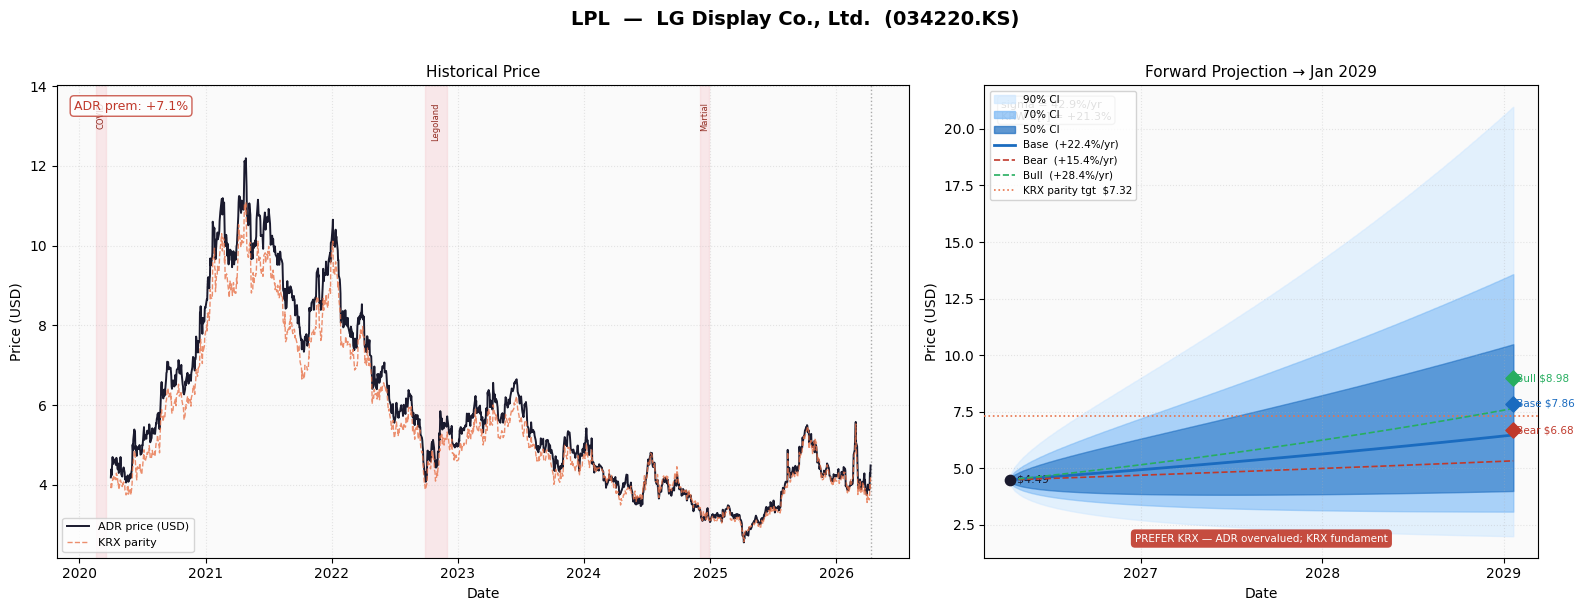

  ✅  LPL: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_LPL.png


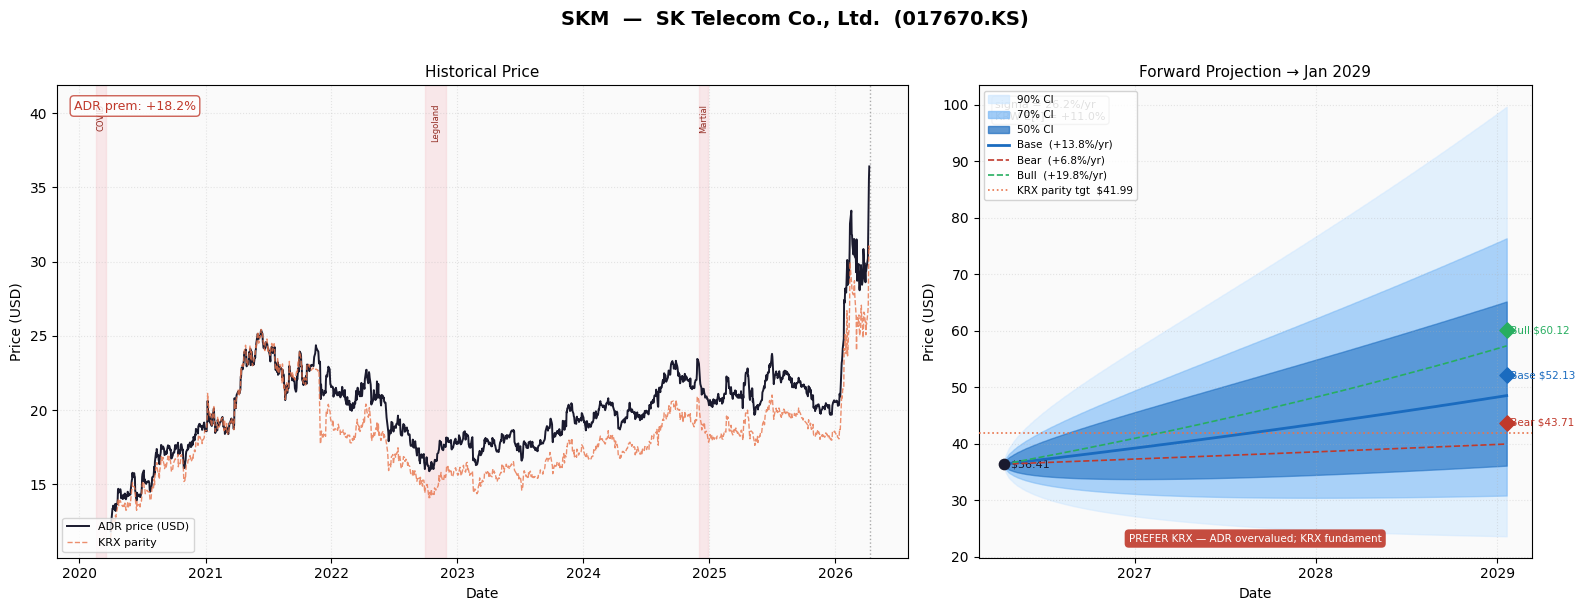

  ✅  SKM: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_SKM.png


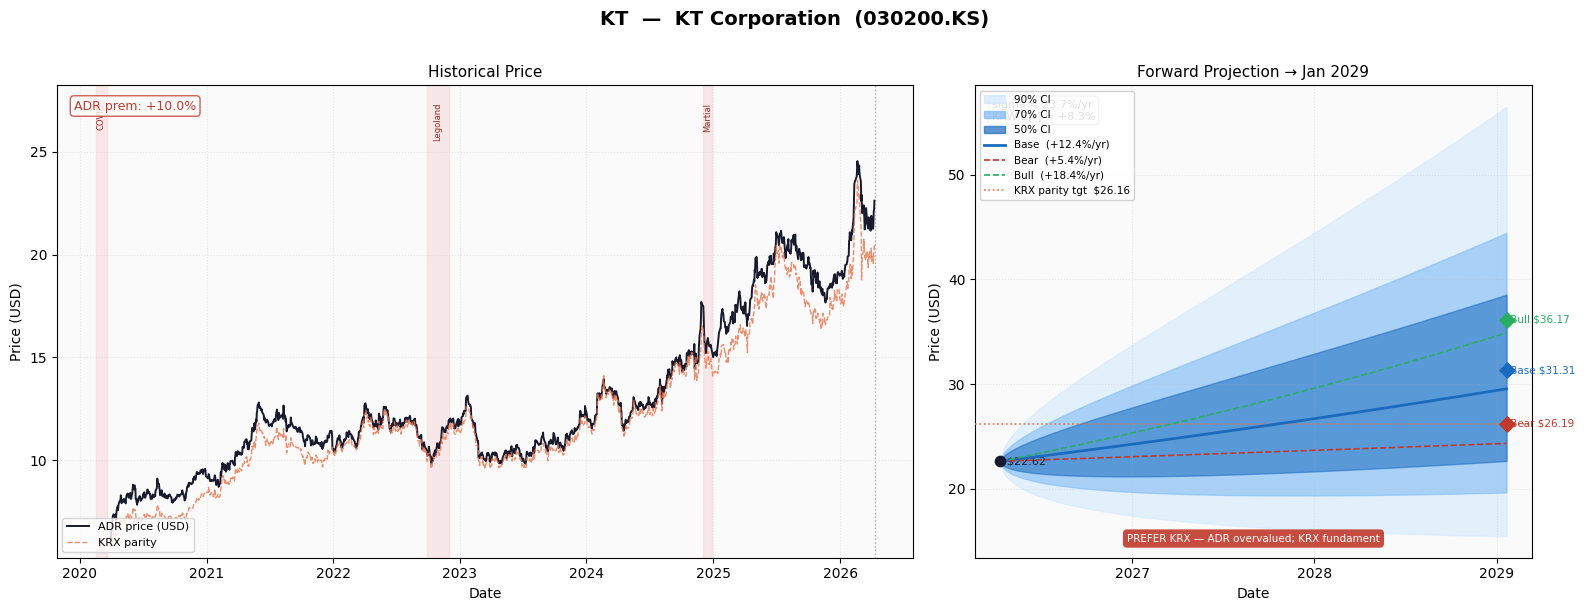

  ✅  KT: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_KT.png


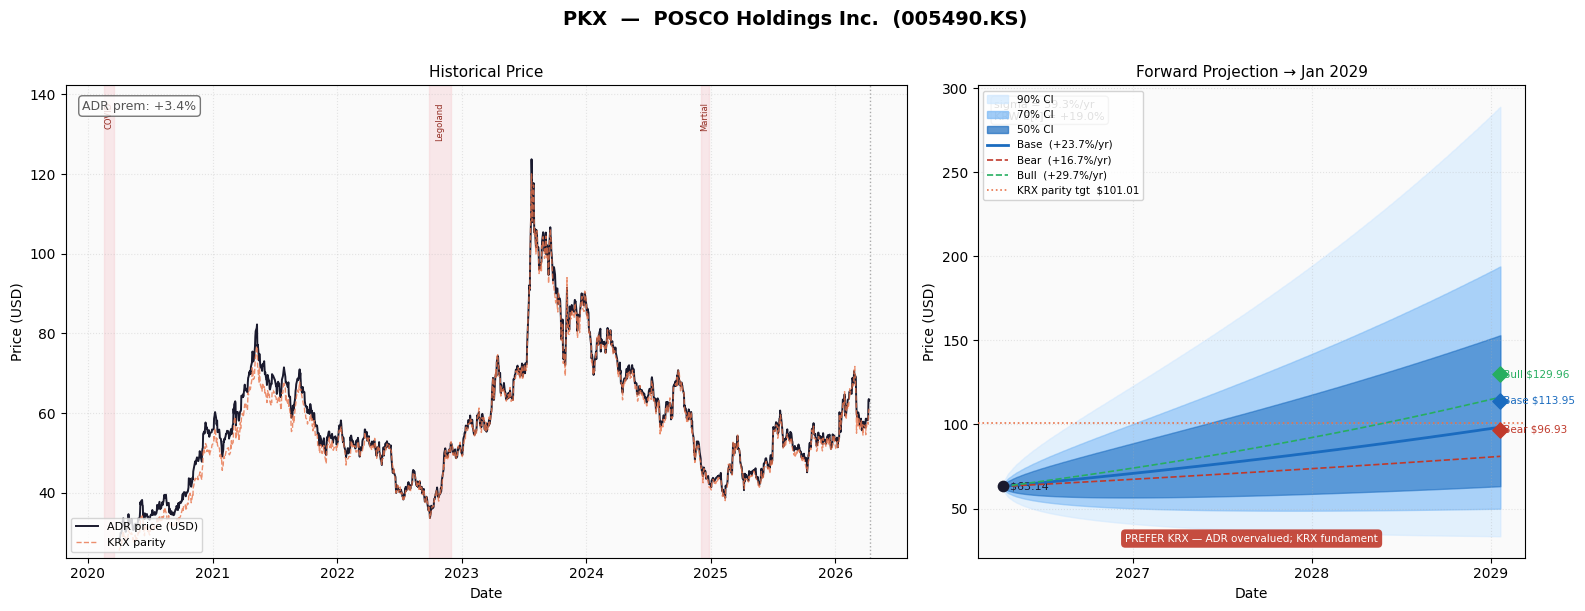

  ✅  PKX: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_PKX.png


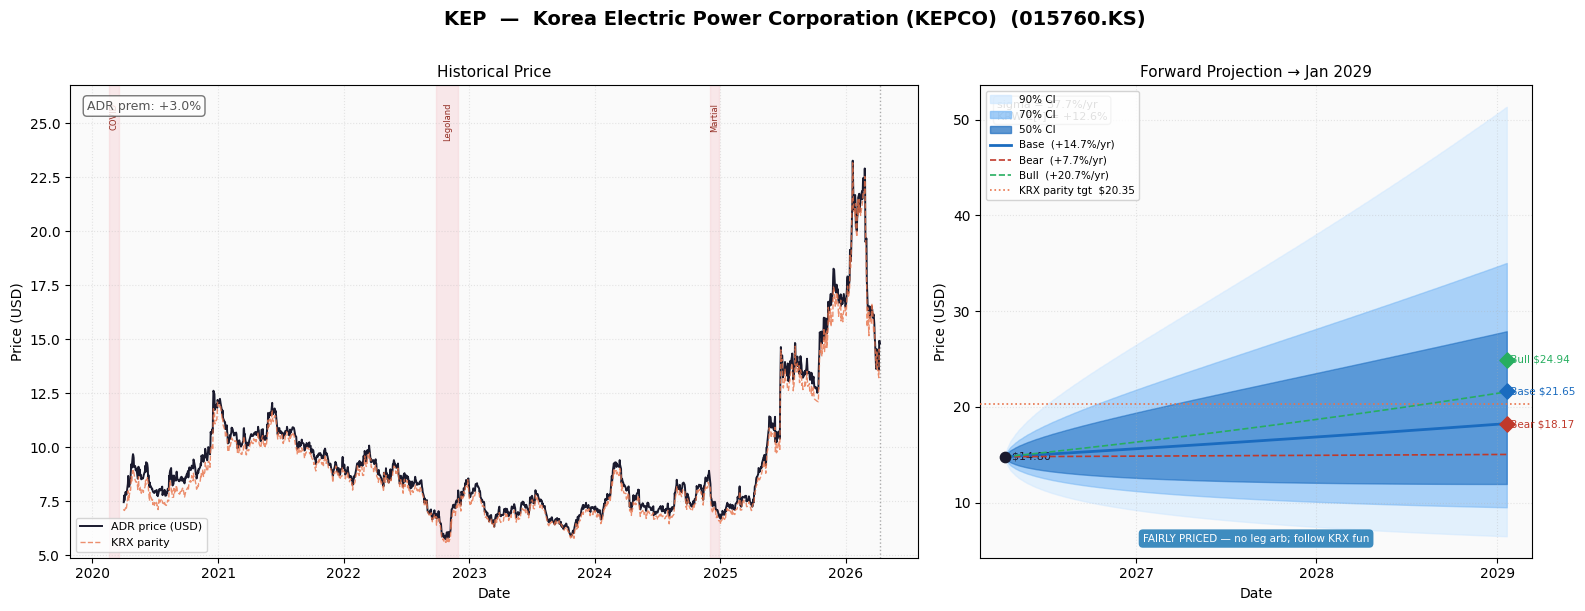

  ✅  KEP: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_KEP.png


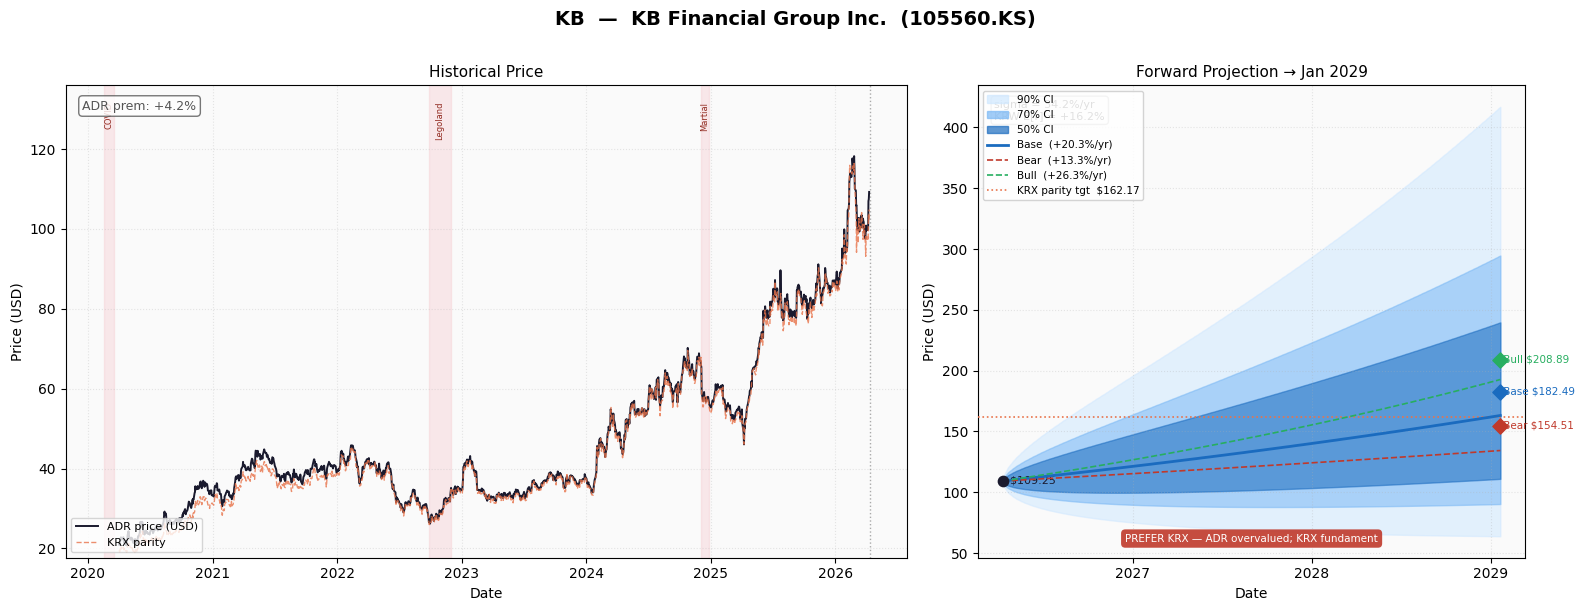

  ✅  KB: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_KB.png


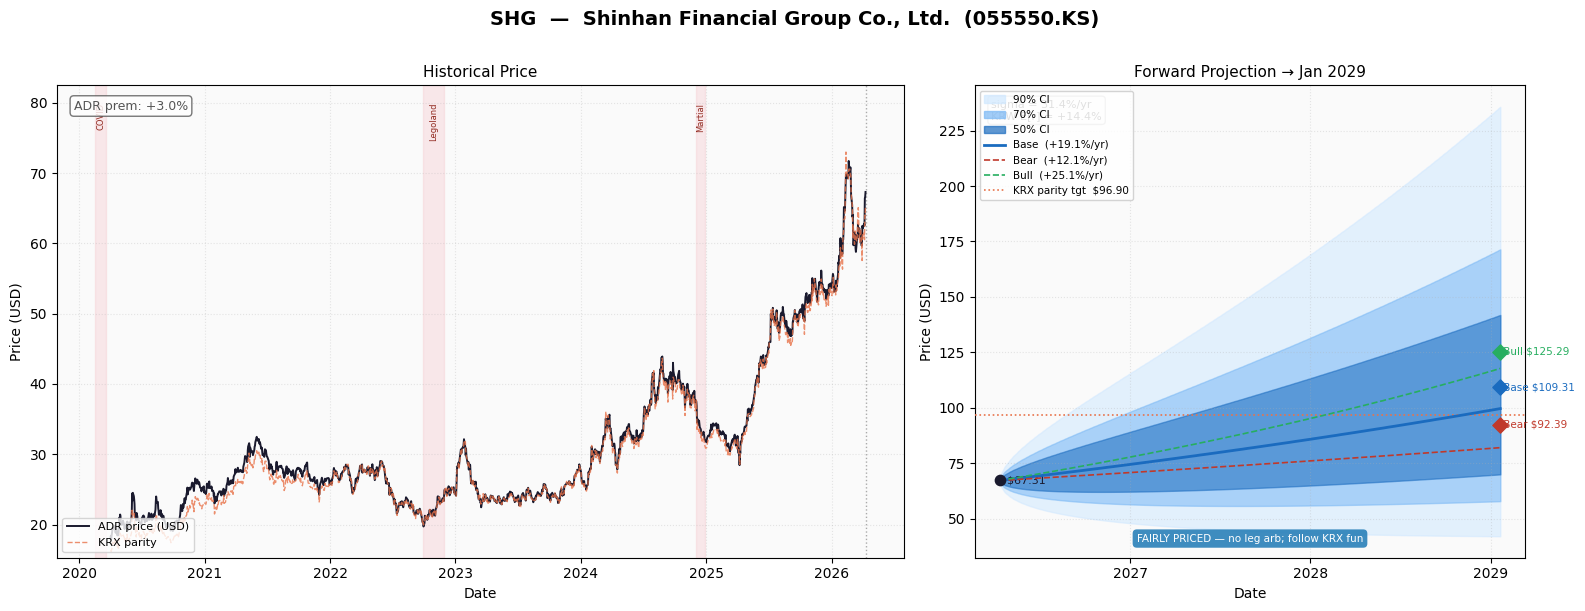

  ✅  SHG: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_SHG.png


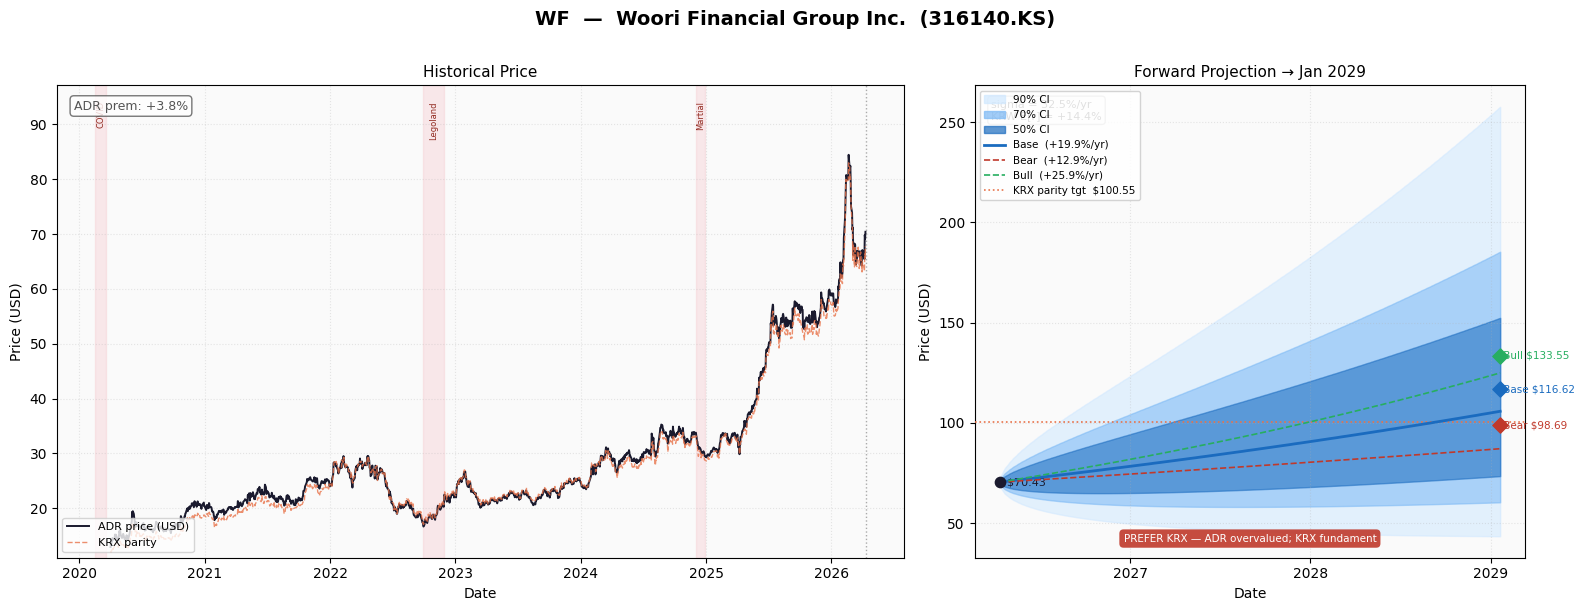

  ✅  WF: saved → /content/drive/My Drive/investment/investment_us/pricing_results/ke_fanchart_WF.png

  8 fan charts saved to: /content/drive/My Drive/investment/investment_us/pricing_results

✅  Cell KE-04b done.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-04b — PRICE FAN CHARTS  (Historical + Forward Projection)        ║
# ║                                                                              ║
# ║  Per ADR: two-panel chart                                                   ║
# ║    LEFT  — Historical ADR price + KRX parity, contamination shaded        ║
# ║    RIGHT — Forward fan: 50/70/90% CI bands + bear/base/bull paths         ║
# ║                                                                              ║
# ║  Fan bands: log-normal S(t)=S0*exp((mu-sigma^2/2)*t +/- z*sigma*sqrt(t))  ║
# ║  Requires: Cell KE-00 through KE-04                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from scipy.stats import norm
from datetime import datetime
import os, warnings
warnings.filterwarnings("ignore")

HIST_START   = datetime(2020, 1, 1)
TODAY        = datetime.today()
FWD_END      = TARGET_DATE
TRADING_DAYS = 252
CI_LEVELS    = [0.90, 0.70, 0.50]
CI_COLORS    = ["#d0e8ff", "#7ab8f5", "#1a6bbf"]
C_PRICE = "#1a1a2e"; C_PARITY = "#e8734a"
C_BASE  = "#1a6bbf"; C_BEAR   = "#c0392b"; C_BULL = "#27ae60"
SAVE_DIR = RESULT_DIR


def ann_vol(px_series):
    return float(px_series.pct_change().dropna().std() * np.sqrt(TRADING_DAYS))


def lognormal_bands(S0, mu_ann, sigma_ann, t_arr, ci):
    z  = norm.ppf((1 + ci) / 2)
    d  = (mu_ann - 0.5 * sigma_ann**2) * t_arr
    s  = sigma_ann * np.sqrt(t_arr)
    return S0 * np.exp(d - z * s), S0 * np.exp(d + z * s)


def shade_contamination(ax, x_min, x_max, y_hi):
    for key, r in KR_REGIMES.items():
        if r["type"] not in KR_CONTAMINATION_TYPES:
            continue
        s = max(r["start"], x_min)
        e = min(r["end"],   x_max)
        if s < e:
            ax.axvspan(s, e, color="#f5c6cb", alpha=0.35, zorder=0)
            ax.text(s + (e-s)/2, y_hi*0.97, r["label"].split()[0],
                    fontsize=6, ha="center", va="top", color="#922b21", rotation=90)


def fwd_path(S0, er, sigma, t_arr):
    return S0 * np.exp((er - 0.5*sigma**2) * t_arr)


print("=" * 72)
print("  CELL KE-04b — Price Fan Charts")
print("=" * 72)
charts_saved = []

for adr in available_pairs:
    info   = KE_ADR_REGISTRY[adr]
    krx    = info["krx_ticker"]
    name   = info["english_name"]
    v      = ke_usd_valuation.get(adr, {})

    px_hist = (px_adr[adr].dropna()
               if adr in px_adr.columns else pd.Series(dtype=float))
    px_hist  = px_hist[px_hist.index >= pd.Timestamp(HIST_START)]
    par_hist = parity_px.get(adr, pd.Series(dtype=float))
    par_hist = par_hist[par_hist.index >= pd.Timestamp(HIST_START)]

    if len(px_hist) < 20:
        print(f"  {adr}: insufficient history — skipping")
        continue

    S0       = float(px_hist.iloc[-1])
    sigma    = ann_vol(px_hist)
    er_base  = v.get("er_adr_base", np.nan)
    er_bear  = v.get("er_adr_bear", np.nan)
    er_bull  = v.get("er_adr_bull", np.nan)
    tgt_base = v.get("target_adr_base",    np.nan)
    tgt_bear = v.get("target_adr_bear",    np.nan)
    tgt_bull = v.get("target_adr_bull",    np.nan)
    tgt_par  = v.get("target_parity_base", np.nan)
    prem_now = v.get("prem_now_pct", np.nan)
    signal   = v.get("combined_signal", "")
    er_krw   = v.get("er_krx_krw", np.nan)

    if np.isnan(er_base):
        print(f"  {adr}: E[r] missing — skipping")
        continue

    cal_days  = max(1, (FWD_END - TODAY).days)
    n_steps   = min(300, cal_days)
    fwd_dates = pd.date_range(TODAY, FWD_END, periods=n_steps)
    t_arr     = np.array([(d - pd.Timestamp(TODAY)).days / 365.25 for d in fwd_dates])

    base_path_arr = fwd_path(S0, er_base, sigma, t_arr)
    bear_path_arr = fwd_path(S0, er_bear, sigma, t_arr) if not np.isnan(er_bear) else None
    bull_path_arr = fwd_path(S0, er_bull, sigma, t_arr) if not np.isnan(er_bull) else None

    fig, (ax_h, ax_f) = plt.subplots(
        1, 2, figsize=(16, 6),
        gridspec_kw={"width_ratios": [2, 1.3]}, facecolor="white")
    fig.suptitle(f"{adr}  —  {name}  ({krx})", fontsize=14, fontweight="bold", y=1.01)

    # Left: historical
    ax_h.set_facecolor("#fafafa")
    ax_h.plot(px_hist.index, px_hist.values, color=C_PRICE, lw=1.4,
              label="ADR price (USD)", zorder=3)
    if len(par_hist) > 0:
        ax_h.plot(par_hist.index, par_hist.values, color=C_PARITY,
                  lw=1.0, ls="--", alpha=0.8, label="KRX parity", zorder=3)
    y_lo_h = px_hist.min() * 0.85
    y_hi_h = px_hist.max() * 1.15
    ax_h.set_ylim(y_lo_h, y_hi_h)
    shade_contamination(ax_h, HIST_START, TODAY, y_hi_h)
    ax_h.axvline(TODAY, color="#888", lw=1, ls=":", alpha=0.7)
    prem_color = C_BEAR if prem_now > 5 else (C_BULL if prem_now < -5 else "#555")
    ax_h.annotate(f"ADR prem: {prem_now:+.1f}%",
                  xy=(0.02, 0.97), xycoords="axes fraction", fontsize=9,
                  va="top", color=prem_color,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=prem_color, alpha=0.8))
    ax_h.set_title("Historical Price", fontsize=11, pad=6)
    ax_h.set_xlabel("Date"); ax_h.set_ylabel("Price (USD)")
    ax_h.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_h.xaxis.set_major_locator(mdates.YearLocator())
    ax_h.legend(fontsize=8, loc="lower left")
    ax_h.grid(True, alpha=0.3, ls=":")

    # Right: forward projection
    ax_f.set_facecolor("#fafafa")
    ci_patches = []
    for i, ci in enumerate(CI_LEVELS):
        lo, hi = lognormal_bands(S0, er_base, sigma, t_arr, ci)
        ax_f.fill_between(fwd_dates, lo, hi, color=CI_COLORS[i], alpha=0.55, zorder=1)
        ci_patches.append(mpatches.Patch(color=CI_COLORS[i], alpha=0.7,
                                          label=f"{int(ci*100)}% CI"))
    ax_f.plot(fwd_dates, base_path_arr, color=C_BASE, lw=2.0,
              label=f"Base  ({er_base:+.1%}/yr)", zorder=4)
    if bear_path_arr is not None:
        ax_f.plot(fwd_dates, bear_path_arr, color=C_BEAR, lw=1.2, ls="--",
                  label=f"Bear  ({er_bear:+.1%}/yr)", zorder=4)
    if bull_path_arr is not None:
        ax_f.plot(fwd_dates, bull_path_arr, color=C_BULL, lw=1.2, ls="--",
                  label=f"Bull  ({er_bull:+.1%}/yr)", zorder=4)
    if not np.isnan(tgt_par):
        ax_f.axhline(tgt_par, color=C_PARITY, lw=1.2, ls=":",
                     label=f"KRX parity tgt  ${tgt_par:.2f}", zorder=3)
    ax_f.scatter([TODAY], [S0], color=C_PRICE, s=55, zorder=5)
    ax_f.annotate(f"  ${S0:.2f}", xy=(TODAY, S0), fontsize=8, va="center", color=C_PRICE)
    for tgt, col, lbl in [
        (tgt_base, C_BASE, f"Base ${tgt_base:.2f}"),
        (tgt_bear, C_BEAR, f"Bear ${tgt_bear:.2f}"),
        (tgt_bull, C_BULL, f"Bull ${tgt_bull:.2f}"),
    ]:
        if not np.isnan(tgt):
            ax_f.scatter([FWD_END], [tgt], color=col, s=60, marker="D", zorder=5)
            ax_f.annotate(f" {lbl}", xy=(FWD_END, tgt), fontsize=7.5, va="center", color=col)
    er_krw_str = f"{er_krw:+.1%}" if not np.isnan(er_krw) else "n/a"
    ax_f.annotate(f"sigma = {sigma:.1%}/yr\nKRW E[r] = {er_krw_str}",
                  xy=(0.03, 0.97), xycoords="axes fraction", fontsize=8, va="top",
                  color="#333", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaa", alpha=0.85))
    sig_color = ("#27ae60" if "BUY" in signal
                 else "#c0392b" if ("AVOID" in signal or "PREFER KRX" in signal)
                 else "#2980b9")
    ax_f.annotate(signal[:42], xy=(0.5, 0.03), xycoords="axes fraction",
                  fontsize=7.5, ha="center", va="bottom", color="white",
                  bbox=dict(boxstyle="round,pad=0.4", fc=sig_color, ec="none", alpha=0.9))
    ax_f.set_title(f"Forward Projection → {FWD_END.strftime("%b %Y")}", fontsize=11, pad=6)
    ax_f.set_xlabel("Date"); ax_f.set_ylabel("Price (USD)")
    ax_f.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_f.xaxis.set_major_locator(mdates.YearLocator())
    line_handles, line_labels = ax_f.get_legend_handles_labels()
    ax_f.legend(handles=ci_patches + line_handles,
                labels=[p.get_label() for p in ci_patches] + line_labels,
                fontsize=7.5, loc="upper left", framealpha=0.85)
    ax_f.grid(True, alpha=0.3, ls=":")
    plt.tight_layout()

    fname = f"ke_fanchart_{adr}.png"
    fpath = os.path.join(SAVE_DIR, fname)
    fig.savefig(fpath, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    charts_saved.append(fname)
    print(f"  ✅  {adr}: saved → {fpath}")

print(f"\n  {len(charts_saved)} fan charts saved to: {SAVE_DIR}")
print(f"\n✅  Cell KE-04b done.")


## Cell KE-05 — Conviction Score + Kelly Allocation

Scoring: `base_signal + ou_adj + z_adj + kr_model_agreement`. BOK RF as hurdle. Quarter-Kelly, capped at 30%.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-05 — CONVICTION SCORE + KELLY ALLOCATION                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print('  CELL KE-05 — Conviction Score + Kelly Allocation')
print('=' * 72)

KELLY_F = ARB_CONFIG['kelly_fraction']
MAX_POS = ARB_CONFIG['max_single_pct']
HURDLE  = RF_KR_ANN

ke_conviction = []

for adr in available_pairs:
    v    = ke_usd_valuation.get(adr, {})
    ps   = prem_stats.get(adr, {})
    kr_c = kr_fund_results.get(adr, {})
    if not v:
        continue

    lp_adr    = v.get('lp_adr_usd', np.nan)
    prem_now  = ps.get('prem_now', 0.0)
    ou_mu     = ps.get('ou_mu', 0.0)
    arb_score = v.get('arb_score', 0)
    er_base   = v.get('er_adr_base', np.nan)

    # ── Base signal ───────────────────────────────────────────────────────────
    prem_excess = prem_now - ou_mu
    er_base_ok  = not np.isnan(er_base) and er_base > HURDLE

    if arb_score == +1 and er_base_ok:
        base_score = +2
    elif arb_score == +1:
        base_score = +1
    elif arb_score == 0 and er_base_ok:
        base_score = +1
    elif arb_score == 0:
        base_score =  0
    elif arb_score == -1 and er_base_ok and abs(prem_excess) < 0.03:
        base_score =  0   # premium near equilibrium, E[r]ADR still positive
    elif arb_score == -1 and er_base_ok:
        base_score = -1   # overpriced but E[r]ADR positive → prefer KRX
    else:
        base_score = -2   # overpriced AND E[r]ADR below hurdle

    # ── OU quality adjustment (Z-sign aware) ────────────────────────────────
    # ou_adj reflects BOTH mean-reversion speed AND current position vs mean.
    #   Z < -0.5  → ADR premium below its OU mean → premium will expand → ADR GAINS  → +1
    #   |Z| ≤ 0.5 → at equilibrium → no directional edge                            →  0
    #   Z > +0.5  → ADR premium above OU mean → premium will compress → ADR DRAG    → -1
    # Speed modifier: fast HL (< 90d) amplifies the Z signal; slow HL (> 180d) mutes it.
    ou_hl    = ps.get('ou_hl_days', np.nan)
    ou_valid = ps.get('ou_valid', False)
    z_ou     = ps.get('z_score_ou', 0.0)
    if ou_valid and not np.isnan(ou_hl):
        # Direction from Z
        if z_ou < -0.5:
            z_dir = +1   # below mean → premium expands → good for ADR buyer
        elif z_ou > +0.5:
            z_dir = -1   # above mean → premium compresses → drag on ADR
        else:
            z_dir = 0    # at equilibrium
        # Speed modifier (fast HL amplifies, slow HL mutes, but never flips sign)
        if ou_hl < 90:
            speed_mult = 1      # fast reversion — signal is strong
        elif ou_hl > 180:
            speed_mult = 0      # slow reversion — mute the signal entirely
        else:
            speed_mult = 1      # mid-range — keep signal as-is
        ou_adj = z_dir * speed_mult
    else:
        ou_adj = 0

    # ── Z-score extremity adjustment ──────────────────────────────────────────
    # Triggers only for |Z| > 2.0 — extreme dislocations get an extra bump.
    # Sign is determined by the same Z-direction logic as ou_adj (consistent framing).
    #   Z < -2.0  → ADR very cheap vs its own history → extra +1 for ADR buyer
    #   Z > +2.0  → ADR very expensive vs history → extra -1 (warning: premium reversal)
    #   |Z| ≤ 2.0 → no extremity adjustment
    if abs(z_ou) > 2.0:
        z_adj = -1 if z_ou > 2.0 else +1
    else:
        z_adj = 0

    # ── KR factor model agreement + robustness tier modifier ─────────────────
    kr_er_vals = [r['er_krw'] for k, r in kr_c.items()
                  if not k.startswith('_') and not np.isnan(r.get('er_krw', np.nan))]
    if kr_er_vals:
        n_above = sum(1 for x in kr_er_vals if x > HURDLE)
        n_below = sum(1 for x in kr_er_vals if x <= HURDLE)
        if n_above > n_below:
            kr_adj_base = +1 if base_score >= 0 else 0
        elif n_below > n_above:
            kr_adj_base = -1 if base_score >= 0 else -1
        else:
            kr_adj_base = 0
    else:
        kr_adj_base = 0

    # Apply robustness tier modifier from KE-03r
    rb = kr_robustness.get(adr, {}) if 'kr_robustness' in dir() else {}
    tier_score = rb.get('tier_score', 0)
    rob_tier   = rb.get('tier', 'N/A (run KE-03r)')

    if tier_score == +1:
        # TIER 1: robust — boost kr_adj by 1 (capped at +2)
        kr_adj = min(kr_adj_base + 1, 2)
    elif tier_score == 0:
        # TIER 2: probable — no change
        kr_adj = kr_adj_base
    elif tier_score == -1:
        # TIER 3: fragile — downgrade by 1
        kr_adj = kr_adj_base - 1
    else:
        # TIER 4: conflicted — hard set to -2
        kr_adj = -2

    total_score = base_score + ou_adj + z_adj + kr_adj

    # ── Kelly sizing (decoupled from OU gate) ───────────────────────────────
    # Kelly is computed whenever E[r]ADR > hurdle, regardless of arb score.
    # The OU signal scales the Kelly fraction rather than suppressing it:
    #   ou_adj = +1 → full KELLY_F fraction (favourable OU convergence)
    #   ou_adj =  0 → 0.60× KELLY_F (neutral — reduce but don't zero out)
    #   ou_adj = -1 → 0.25× KELLY_F (unfavourable — still actionable but small)
    # This ensures "LEAN BUY ADR" always comes with a non-zero position size.
    col_adr = ret_adr_d[adr].dropna() if adr in ret_adr_d.columns else pd.Series(dtype=float)
    vol_ann = float(col_adr.std() * np.sqrt(252)) if len(col_adr) >= 20 else 0.30
    vol_ann = max(vol_ann, 0.05)

    edge      = er_base - HURDLE if not np.isnan(er_base) else 0.0
    kelly_raw = edge / (vol_ann ** 2) if vol_ann > 0 else 0.0

    # Scale Kelly fraction by OU signal direction (never fully suppress)
    if ou_adj == +1:
        ou_kelly_mult = 1.0    # OU convergence tailwind — full fraction
    elif ou_adj == 0:
        ou_kelly_mult = 0.60   # neutral — reduce but stay invested
    else:
        ou_kelly_mult = 0.25   # OU headwind — small position, not zero
    effective_kelly_f = KELLY_F * ou_kelly_mult

    # Only allocate if E[r]ADR clears the hurdle (edge > 0)
    kelly_adj = kelly_raw * effective_kelly_f if edge > 0 else 0.0
    kelly_cap = min(max(kelly_adj, 0.0), MAX_POS)

    # ── Conviction label ──────────────────────────────────────────────────────
    if total_score >= 4:       conviction = '★★★ STRONG BUY ADR'
    elif total_score == 3:     conviction = '★★  BUY ADR'
    elif total_score in (1,2): conviction = '★   LEAN BUY ADR'
    elif total_score == 0:     conviction = '—   HOLD / WATCH'
    elif total_score == -1:    conviction = '▼   PREFER KRX LEG'
    elif total_score == -2:    conviction = '▼▼  AVOID ADR'
    else:                      conviction = '▼▼▼ STRONG AVOID ADR'

    ke_conviction.append({
        'ticker':            adr,
        'krx_ticker':        v['krx_ticker'],
        'english_name':      v['english_name'],
        'sector':            v['sector'],
        'lp_adr_usd':        v['lp_adr_usd'],
        'lp_krx_krw':        v['lp_krx_krw'],
        'prem_now_pct':      v['prem_now_pct'],
        'z_score_ou':        ps.get('z_score_ou', np.nan),
        'ou_hl_days':        ou_hl,
        'er_krx_krw':        v['er_krx_krw'],
        'er_adr_bear':       v['er_adr_bear'],
        'er_adr_base':       v['er_adr_base'],
        'er_adr_bull':       v['er_adr_bull'],
        'target_adr_bear':   v['target_adr_bear'],
        'target_adr_base':   v['target_adr_base'],
        'target_adr_bull':   v['target_adr_bull'],
        'target_krx_krw':    v['target_krx_krw'],
        'vol_ann':           round(vol_ann, 4),
        'edge':              round(edge, 4),
        'kelly_raw':         round(kelly_raw, 4),
        'kelly_capped':      round(kelly_cap, 4),
        'base_score':        base_score,
        'ou_adj':            ou_adj,
        'z_adj':             z_adj,
        'kr_adj':            kr_adj,
        'total_score':       total_score,
        'conviction':        conviction,
        'arb_direction':     v['arb_direction'],
        'robustness_tier':   rob_tier,
        'tier_score':        tier_score,
        'combined_signal':   v['combined_signal'],
        # leg_recommendation integrates arb_signal + fundamental_verdict cleanly
        # Answers: "given both the arb position and fundamentals, what should I do?"
        'preferred_leg':     'ADR' if base_score >= 0 else 'KRX',
        'leg_recommendation': (
            'BUY ADR'     if arb_score >= 0 and not np.isnan(er_base) and er_base > HURDLE else
            'BUY KRX'     if arb_score == -1 and not np.isnan(er_base) and er_base > HURDLE else
            'WATCH — ADR above arb threshold, await compression'
                          if arb_score == -1 and not np.isnan(er_base) and er_base <= HURDLE else
            'HOLD / WATCH'
        ),
        'sdf_state':         SDF_STATE,
        'current_kr_regime': KR_REGIMES[CURRENT_KR_REGIME]['label'],
        'run_date':          END_DATE.date(),
        'target_date':       TARGET_DATE.date(),
    })

ke_conv_df = pd.DataFrame(ke_conviction).sort_values('total_score', ascending=False)

# ── Print ─────────────────────────────────────────────────────────────────────
print(f'\n  Hurdle rate (BOK RF): {HURDLE:.2%}  |  Kelly fraction: {KELLY_F}×  '
      f'|  Max pos: {MAX_POS:.0%}')
print(f'  KR regime: {KR_REGIMES[CURRENT_KR_REGIME]["label"]}  '
      f'|  US SDF: {SDF_STATE.upper()}')
print(f'\n  Score components:')
print(f'    base : +2=ADR cheap+E[r]>hurdle  +1=cheap or fair+E[r]>hurdle  0=fair  -1=expensive+E[r]>hurdle  -2=expensive+weak E[r]')
print(f'    ou_adj: Z<-0.5→+1(prem below mean=ADR gains)  |Z|≤0.5→0  Z>+0.5→-1(prem above mean=ADR drag)')
print(f'    z_adj: |Z|>2.0 extremity amplifier: Z<-2→+1  Z>+2→-1')
print(f'    kr_adj: Korean factor model agreement + robustness tier boost')
print(f'    Kelly: ou_adj=+1→full fraction  ou_adj=0→0.60× fraction  ou_adj=-1→0.25× fraction')
print(f'\n  Score: base + ou_adj + z_adj + kr_adj = total')
print(f'\n  {"ADR":<8}  {"Prem%":>7}  {"Z":>5}  {"HL(d)":>6}  '
      f'{"E[r]KRW":>8}  {"E[r]ADR(base)":>13}  '
      f'{"Score":>22}  {"Kelly%":>7}  Leg recommendation        Conviction')
print('  ' + '─' * 140)

for _, r in ke_conv_df.iterrows():
    hl_s = f'{r["ou_hl_days"]:.0f}' if not np.isnan(r['ou_hl_days']) else 'n/a'
    er_k = f'{r["er_krx_krw"]:>+8.2%}' if not np.isnan(r['er_krx_krw']) else '  n/a'
    er_b = f'{r["er_adr_base"]:>+13.2%}' if not np.isnan(r['er_adr_base']) else '  n/a'
    kl_s = f'{r["kelly_capped"]*100:>6.1f}%' if r['kelly_capped'] > 0 else '    —'
    sc_s = (f'{r["base_score"]:>+}+{r["ou_adj"]:>+}+{r["z_adj"]:>+}+'
            f'{r["kr_adj"]:>+}={r["total_score"]:>+}')
    leg_rec = str(r.get('leg_recommendation', 'N/A'))
    print(f'  {r["ticker"]:<8}  {r["prem_now_pct"]:>+7.2f}%  '
          f'{r["z_score_ou"]:>+5.2f}  {hl_s:>6}d  {er_k}  {er_b}  '
          f'{sc_s:>22}  {kl_s}  {leg_rec:<26}  {str(r.get("robustness_tier","N/A"))[:22]:<22}  {r["conviction"]}')

safe_save(ke_conv_df, 'ke_adr_conviction.csv')
print(f'\n  Saved: ke_adr_conviction.csv')
print(f'\n✅  Cell KE-05 done.')

  CELL KE-05 — Conviction Score + Kelly Allocation

  Hurdle rate (BOK RF): 2.78%  |  Kelly fraction: 0.25×  |  Max pos: 30%
  KR regime: Post-Shock Recovery KR  |  US SDF: NORMAL

  Score components:
    base : +2=ADR cheap+E[r]>hurdle  +1=cheap or fair+E[r]>hurdle  0=fair  -1=expensive+E[r]>hurdle  -2=expensive+weak E[r]
    ou_adj: Z<-0.5→+1(prem below mean=ADR gains)  |Z|≤0.5→0  Z>+0.5→-1(prem above mean=ADR drag)
    z_adj: |Z|>2.0 extremity amplifier: Z<-2→+1  Z>+2→-1
    kr_adj: Korean factor model agreement + robustness tier boost
    Kelly: ou_adj=+1→full fraction  ou_adj=0→0.60× fraction  ou_adj=-1→0.25× fraction

  Score: base + ou_adj + z_adj + kr_adj = total

  ADR         Prem%      Z   HL(d)   E[r]KRW  E[r]ADR(base)                   Score   Kelly%  Leg recommendation        Conviction
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  KEP         +3.00%  -0.44       2d   +12.56

## Cell KE-06 — Master Tearsheet Report

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-06 — MASTER TEARSHEET REPORT                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print(f'  KE-ADR MASTER TEARSHEET REPORT')
print(f'  Run date    : {END_DATE.date()}')
print(f'  Target date : {TARGET_DATE.date()}  (+{CAL_DAYS} days)')
print(f'  USD/KRW     : ₩{USDKRW_NOW:,.2f}  (FX vol: {FX_VOL_ANN:.2%} ann.)')
print(f'  KR regime   : {KR_REGIMES[CURRENT_KR_REGIME]["label"]}')
print(f'  US SDF      : {SDF_STATE.upper()}')
print(f'  BOK RF      : {RF_KR_ANN:.2%}  |  US RF: {RF_ANN:.2%}')
print('=' * 72)

for _, conv_row in ke_conv_df.iterrows():
    adr  = conv_row['ticker']
    krx  = conv_row['krx_ticker']
    info = KE_ADR_REGISTRY[adr]
    ps   = prem_stats.get(adr, {})
    kr_c = kr_fund_results.get(adr, {})
    v    = ke_usd_valuation.get(adr, {})

    print(f'\n  ╔══ {adr}  |  {krx}  |  {info["english_name"]}')
    print(f'  ║   Sector: {info["sub_sector"]}  '
          f'|  Exchange: {info["exchange_us"]}  '
          f'|  ADR ratio: 1 ADR = {info["adr_ratio"]} KRX share(s)')
    print(f'  ║   Note: {info["notes"]}')
    print(f'  ║')

    # ── Prices ───────────────────────────────────────────────────────────────
    lp_a   = v.get('lp_adr_usd', np.nan)
    lp_k   = v.get('lp_krx_krw', np.nan)
    par    = v.get('parity_px_usd', np.nan)
    prem   = v.get('prem_now_pct', np.nan)
    z_ou   = ps.get('z_score_ou', np.nan)
    z_full = ps.get('z_score_full', np.nan)

    print(f'  ║  ── PRICES ──────────────────────────────────────────────────')
    print(f'  ║    ADR (USD)       : ${lp_a:.2f}')
    print(f'  ║    KRX (KRW)       : ₩{lp_k:,.0f}  → USD equiv. ${v.get("lp_krx_usd", np.nan):.4f}')
    print(f'  ║    Parity ADR (USD): ${par:.2f}  (= KRX USD × {info["adr_ratio"]})')
    print(f'  ║    Premium/discount: {prem:>+.2f}%  Z(OU)={z_ou:>+.2f}  Z(hist)={z_full:>+.2f}')
    print(f'  ║    Hist band       : mean={ps.get("prem_mean_full",0)*100:>+.2f}%  '
          f'σ={ps.get("prem_std_full",0)*100:.2f}%')

    # ── OU stats ─────────────────────────────────────────────────────────────
    ou_hl  = ps.get('ou_hl_days', np.nan)
    ou_mu  = ps.get('ou_mu', 0.0)
    ou_rsq = ps.get('ou_rsq', np.nan)
    n_excl = ps.get('n_excluded', 0)
    hl_s   = (f'{ou_hl:.0f} days (≈{ou_hl/21:.1f} months)'
              if not np.isnan(ou_hl) else 'not estimable')

    print(f'  ║')
    print(f'  ║  ── OU MEAN REVERSION (contamination-guarded) ───────────────')
    print(f'  ║    Half-life (OU)  : {hl_s}')
    print(f'  ║    Long-run μ (OU) : {ou_mu*100:>+.2f}%  (equilibrium premium/discount)')
    if not np.isnan(ou_rsq):
        print(f'  ║    OU R²           : {ou_rsq:.3f}')
    else:
        print(f'  ║    OU R²           : n/a')
    print(f'  ║    Obs excluded    : {n_excl}  (Korean contamination windows)')
    print(f'  ║    Conv. net (gross): {ps.get("conv_net", 0)*100:>+.2f}%')
    print(f'  ║    Arb conv (amort) : {v.get("er_arb_conv", 0):>+.2%}/yr  '
          f'(spread over {t_years:.1f}yr holding period)')

    # ── KRX fundamental models ────────────────────────────────────────────────
    print(f'  ║')
    print(f'  ║  ── KRX FUNDAMENTAL MODELS (KRW basis) ──────────────────────')
    for m_key, m_res in kr_c.items():
        if m_key.startswith('_'):
            continue
        er_kr = m_res.get('er_krw', np.nan)
        aa_kr = m_res.get('alpha_ann_krw', np.nan)
        print(f'  ║    {m_key:<12}  E[r]={er_kr:>+.2%}  '
              f'α={aa_kr:>+.2%}(p={m_res.get("alpha_pval", 1):.3f})  '
              f'R²={m_res.get("rsq", np.nan):.3f}  {m_res.get("signal", "n/a")}')
    kr_con = kr_c.get('_consensus_kr', {})
    print(f'  ║    {"CONSENSUS":<12}  E[r]={kr_con.get("er_krw", np.nan):>+.2%}  '
          f'Tgt₩{kr_con.get("target_krw", np.nan):,.0f}')

    # ── USD decomposition ─────────────────────────────────────────────────────
    print(f'  ║')
    print(f'  ║  ── USD INVESTOR DECOMPOSITION ─────────────────────────────')
    print(f'  ║    KRX E[r] KRW    : {v.get("er_krx_krw", np.nan):>+.2%}')
    print(f'  ║    + Arb conv.     : {v.get("er_arb_conv", 0):>+.2%}  '
          f'({v.get("arb_signal", "n/a")})')
    print(f'  ║    + Div yield     : {v.get("div_yield_adr", 0):>+.2%}')
    print(f'  ║    − ADR fee       : {v.get("adr_fee_pct", 0):>+.2%}')

    # ── FX scenarios ─────────────────────────────────────────────────────────
    print(f'  ║')
    print(f'  ║  ── FX SCENARIOS (ADR total E[r] in USD) ───────────────────')
    for lbl, fx_v, er_v, tgt_v in [
        ('Bear  (KRW −5%)', FX_BEAR, v.get('er_adr_bear'), v.get('target_adr_bear')),
        ('Base  (KRW +2%)', FX_BASE, v.get('er_adr_base'), v.get('target_adr_base')),
        ('Bull  (KRW +8%)', FX_BULL, v.get('er_adr_bull'), v.get('target_adr_bull')),
    ]:
        er_s  = f'{er_v:>+.2%}' if er_v is not None and not np.isnan(er_v) else 'n/a'
        tgt_s = f'${tgt_v:.2f}' if tgt_v is not None and not np.isnan(tgt_v) else 'n/a'
        print(f'  ║    {lbl}: FX={fx_v:>+.2%}  E[r]ADR={er_s}  TgtADR={tgt_s}')
    par_tgt = v.get('target_parity_base', np.nan)
    if not np.isnan(par_tgt):
        print(f'  ║    Parity target (base FX): ${par_tgt:.2f}  '
              f'(implied by KRX Tgt × ratio)')

    # ── Conviction ────────────────────────────────────────────────────────────
    print(f'  ║')
    print(f'  ║  ── CONVICTION ─────────────────────────────────────────────')
    sc = (f'base={conv_row["base_score"]:>+}  '
          f'ou_adj={conv_row["ou_adj"]:>+}  '
          f'z_adj={conv_row["z_adj"]:>+}  '
          f'kr_adj={conv_row["kr_adj"]:>+}  '
          f'→ total={conv_row["total_score"]:>+}')
    print(f'  ║    Score      : {sc}')
    print(f'  ║    Conviction : {conv_row["conviction"]}')

    if conv_row['total_score'] >= 1:
        direction_display = 'BUY ADR (accept premium as cost of USD access)'
    else:
        direction_display = conv_row['arb_direction']
    print(f'  ║    Direction  : {direction_display}')

    kl = conv_row['kelly_capped'] * 100
    print(f'  ║    Kelly alloc: {kl:.1f}% of portfolio  '
          f'(¼-Kelly, edge={conv_row["edge"]:>+.2%}, '
          f'vol={conv_row["vol_ann"]:.2%})')
    if conv_row['total_score'] <= 0:
        print(f'  ║    ⚠️  No ADR allocation. '
              f'{"Consider KRX leg directly." if conv_row["total_score"] == -1 else "Monitor for entry."}')

    # ── Regime context ────────────────────────────────────────────────────────
    print(f'  ║')
    print(f'  ║  ── REGIME CONTEXT ─────────────────────────────────────────')
    kr_reg = KR_REGIMES[CURRENT_KR_REGIME]
    print(f'  ║    KR regime  : {kr_reg["label"]}  [SDF: {kr_reg["sdf_model"]}]')
    print(f'  ║    US SDF     : {SDF_STATE.upper()}')
    if kr_reg['type'] in ('crash', 'bear'):
        print(f'  ║    ⚠️  Currently in a Korean crash/shock regime — '
              f'factor estimates less reliable')

    print(f'  ╚' + '═' * 70)

print(f'\n✅  Cell KE-06 (tearsheet) done.')

  KE-ADR MASTER TEARSHEET REPORT
  Run date    : 2026-04-11
  Target date : 2029-01-20  (+1014 days)
  USD/KRW     : ₩1,510.17  (FX vol: 8.67% ann.)
  KR regime   : Post-Shock Recovery KR
  US SDF      : NORMAL
  BOK RF      : 2.78%  |  US RF: 4.50%

  ╔══ KEP  |  015760.KS  |  Korea Electric Power Corporation (KEPCO)
  ║   Sector: electric power generation and transmission  |  Exchange: NYSE  |  ADR ratio: 1 ADR = 0.5 KRX share(s)
  ║   Note: State-controlled monopoly utility. Leveraged to Korean power tariff reform and nuclear energy.
  ║
  ║  ── PRICES ──────────────────────────────────────────────────
  ║    ADR (USD)       : $14.80
  ║    KRX (KRW)       : ₩43,400  → USD equiv. $28.7385
  ║    Parity ADR (USD): $14.37  (= KRX USD × 0.5)
  ║    Premium/discount: +3.00%  Z(OU)=-0.44  Z(hist)=-0.38
  ║    Hist band       : mean=+3.73%  σ=1.91%
  ║
  ║  ── OU MEAN REVERSION (contamination-guarded) ───────────────
  ║    Half-life (OU)  : 2 days (≈0.1 months)
  ║    Long-run μ (OU) : +

In [ ]:
# Run this to see what yfinance is actually returning
for adr in available_pairs:
    info_yf = yf.Ticker(adr).info
    print(f"{adr}: dividendYield={info_yf.get('dividendYield')} "
          f"trailingAnnualDividendYield={info_yf.get('trailingAnnualDividendYield')} "
          f"trailingAnnualDividendRate={info_yf.get('trailingAnnualDividendRate')} "
          f"currentPrice={info_yf.get('currentPrice')}")

LPL: dividendYield=None trailingAnnualDividendYield=0.0 trailingAnnualDividendRate=0.0 currentPrice=4.49
SKM: dividendYield=3.84 trailingAnnualDividendYield=0.0 trailingAnnualDividendRate=0.0 currentPrice=36.41
KT: dividendYield=3.56 trailingAnnualDividendYield=108.15682 trailingAnnualDividendRate=2400.0 currentPrice=22.62
PKX: dividendYield=2.8 trailingAnnualDividendYield=157.40596 trailingAnnualDividendRate=10000.0 currentPrice=63.14
KEP: dividendYield=0.45 trailingAnnualDividendYield=103.420525 trailingAnnualDividendRate=1542.0 currentPrice=14.8
KB: dividendYield=2.3 trailingAnnualDividendYield=40.63838 trailingAnnualDividendRate=4367.0 currentPrice=109.25
SHG: dividendYield=2.67 trailingAnnualDividendYield=38.865547 trailingAnnualDividendRate=2590.0 currentPrice=67.31
WF: dividendYield=3.78 trailingAnnualDividendYield=19.65318 trailingAnnualDividendRate=1360.0 currentPrice=70.43


## Cell KE-07 — Registry Integration + Final Summary

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL KE-07 — TICKERS REGISTRY INTEGRATION + SAVED FILES SUMMARY          ║
# ║                                                                              ║
# ║  1. Prints the TICKERS dict snippet to paste into Cell 01 of the main      ║
# ║     notebook so KE-ADRs flow into the full pricing pipeline                ║
# ║     (CAPM, FF5, APT, DDM, OU, Kalman, GARCH, CCAPM, conviction, Kelly)   ║
# ║                                                                              ║
# ║  2. Explains which model outputs to TRUST vs IGNORE for KE-ADRs when      ║
# ║     running the main notebook on these tickers:                            ║
# ║       TRUST  : OU, DDM (if dividend-paying), GARCH (vol only)             ║
# ║       CAUTION: CAPM/FF5/APT vs SPY — captures global risk appetite,       ║
# ║                not fundamental. Supplement with KE-03 Korean models.       ║
# ║                                                                              ║
# ║  3. Prints a compact final summary table                                   ║
# ║  4. Lists all saved output files                                           ║
# ║                                                                              ║
# ║  Requires: Cell KE-00 through KE-06                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('=' * 72)
print('  CELL KE-07 — Registry Integration + Summary')
print('=' * 72)

# ── TICKERS dict snippet ──────────────────────────────────────────────────────
print(f'\n  ── Paste into Cell 01 TICKERS dict ──────────────────────────────')
print(f'  # ── Korea Electronics ADRs (dual-listed, KOSPI HQ) ─────────────')
for adr, info in KE_ADR_REGISTRY.items():
    rec_freq = 'daily' if info['exchange_us'] == 'NYSE' else 'monthly'
    print(f'  "{adr}": ("{info["korean_name"]}", "{info["english_name"]}", '
          f'"usa", "ke_adr", "", "{rec_freq}", "stock"),')

print(f'\n  ── Main notebook model guidance for KE-ADRs ─────────────────────')
print(f'''
  When Cell 04-11 of the main notebook run on KE-ADR tickers, interpret as:

  TRUST (directly meaningful):
    OU×Daily/Monthly   — premium/discount mean-reversion (but use KE-02
                         contamination-guarded version for parameter estimates)
    DDM×Monthly        — dividend yield model; valid for LGEIY, SSDIY, LPL
    GARCH×Daily        — volatility forecast for Kelly sizing (vol only, not direction)

  CAUTION (supplementary only — do NOT use as primary signal):
    CAPM×Daily         — β vs SPY captures global risk-off correlation,
                         not Korean fundamental pricing. Use KE-03 KR-CAPM instead.
    FF5×Daily/Monthly  — US factors partially relevant (global size/value),
                         but miss Korean-specific factors. Supplement with KE-03 KR-FF5.
    APT×Daily/Monthly  — US macro factors (VIX, USD, credit) are secondary drivers.
                         Primary APT should use Korean macro (KE-03 KR-APT).

  PRIMARY SIGNAL for KE-ADRs (from THIS notebook):
    → KE-03 Korean fundamental E[r] in KRW
    → KE-04 USD investor total E[r] (base FX scenario)
    → KE-05 conviction score + Kelly allocation
''')

# ── Final compact summary ─────────────────────────────────────────────────────
print(f'  ── FINAL SUMMARY ────────────────────────────────────────────────')
print(f'  Key distinctions:')
print(f'    E[r]KRW        = KRX fundamental return in Korean Won (is the company cheap?)')
print(f'    E[r]ADR(base)  = Total USD return after FX, arb convergence, dividend, fee')
print(f'    Leg recommendation = which instrument to BUY: ADR vs KRX leg today')
print(f'      "BUY ADR"  = E[r]>hurdle AND ADR is fairly priced vs KRX')
print(f'      "BUY KRX"  = E[r]>hurdle BUT ADR is currently overpriced vs KRX')
print(f'      These are NOT contradictions — the company can be a BUY while the ADR')
print(f'      is the wrong entry point. Always check both E[r] AND leg recommendation.')
print(f'\n  {"ADR":<8}  {"KRX":<14}  '
      f'{"ADR px":>8}  {"Prem%":>7}  '
      f'{"E[r]KRW":>8}  {"E[r]ADR(base)":>13}  '
      f'{"TgtADR":>8}  {"Kelly%":>7}  Conviction')
print('  ' + '─' * 110)

for _, r in ke_conv_df.iterrows():
    er_k = f'{r["er_krx_krw"]:>+8.2%}' if not np.isnan(r['er_krx_krw']) else '  n/a'
    er_b = f'{r["er_adr_base"]:>+13.2%}' if not np.isnan(r['er_adr_base']) else '  n/a'
    tgt  = f'${r["target_adr_base"]:>7.2f}' if not np.isnan(r['target_adr_base']) else '  n/a'
    kl   = f'{r["kelly_capped"]*100:>6.1f}%' if r['kelly_capped'] > 0 else '    —'
    leg_r = str(r.get('leg_recommendation', 'N/A'))
    print(f'  {r["ticker"]:<8}  {r["krx_ticker"]:<14}  '
          f'${r["lp_adr_usd"]:>7.2f}  {r["prem_now_pct"]:>+7.2f}%  '
          f'{er_k}  {er_b}  {tgt}  {kl}  {leg_r:<26}  {r["conviction"]}')

# KRX leg summary
print(f'\n  KRX legs (for investors who can access KRX directly):')
print(f'  {"KRX":<14}  {"ADR":<8}  '
      f'{"KRX px(₩)":>12}  {"KRX Tgt(₩)":>12}  '
      f'{"E[r]KRW":>8}  Leg recommendation        Note')
print('  ' + '─' * 90)
print(f'  (Leg recommendation = integrated signal: arb position + KRX fundamental)')
for _, r in ke_conv_df.iterrows():
    lk  = f'₩{r["lp_krx_krw"]:>10,.0f}' if not np.isnan(r['lp_krx_krw']) else '  n/a'
    tk  = f'₩{r["target_krx_krw"]:>10,.0f}' if not np.isnan(r['target_krx_krw']) else '  n/a'
    erk = f'{r["er_krx_krw"]:>+8.2%}' if not np.isnan(r['er_krx_krw']) else '  n/a'
    leg_r = str(r.get('leg_recommendation', 'N/A'))
    # Explanatory note: if E[r]KRW > 0 but leg=KRX, that means ADR is overpriced today
    note = ('ADR premium too high today' if leg_r == 'BUY KRX' else
            'ADR entry acceptable'       if leg_r == 'BUY ADR' else '')
    print(f'  {r["krx_ticker"]:<14}  {r["ticker"]:<8}  '
          f'{lk:>12}  {tk:>12}  {erk}  {leg_r:<26}  {note}')

# ── Regime context ────────────────────────────────────────────────────────────
print(f'\n  ── Regime context ───────────────────────────────────────────────')
print(f'  Current KR regime : {KR_REGIMES[CURRENT_KR_REGIME]["label"]}')
print(f'  Current US SDF    : {SDF_STATE.upper()}')
print(f'  BOK RF            : {RF_KR_ANN:.2%}  (estimation hurdle)')
print(f'  USD/KRW           : ₩{USDKRW_NOW:,.2f}  FX vol={FX_VOL_ANN:.2%}')
print(f'\n  KR contamination windows (excluded from OU estimation):')
for key, r in KR_REGIMES.items():
    if r['type'] in KR_CONTAMINATION_TYPES:
        print(f'    • {r["label"]:<30}  {r["start"].date()} → {r["end"].date()}')

# ── Saved files ───────────────────────────────────────────────────────────────
print(f'\n  ── Saved output files ───────────────────────────────────────────')
files = [
    'ke_adr_discovery_results.csv',
    'ke_adr_premium_stats.csv',
    'ke_krx_fundamental_results.csv',
    'ke_krx_full_summary.csv',
    'ke_adr_usd_valuation.csv',
    'ke_adr_conviction.csv',
]
for fname in files:
    fpath = os.path.join(RESULT_DIR, fname)
    ok = os.path.exists(fpath)
    print(f'  {"✅" if ok else "❌"}  {fname}')

print(f'\n  All files saved to: {RESULT_DIR}/')
print(f'\n{"=" * 72}')
print(f'  ✅  KE-ADR ANALYSIS COMPLETE')
print(f'  Pairs analysed: {available_pairs}')
print(f'  Run Cells 00→01→02→03→04→05→06→07 in order.')
print(f'{"=" * 72}')

  CELL KE-07 — Registry Integration + Summary

  ── Paste into Cell 01 TICKERS dict ──────────────────────────────
  # ── Korea Electronics ADRs (dual-listed, KOSPI HQ) ─────────────
  "LPL": ("LG디스플레이", "LG Display Co., Ltd.", "usa", "ke_adr", "", "daily", "stock"),
  "SKM": ("SK텔레콤", "SK Telecom Co., Ltd.", "usa", "ke_adr", "", "daily", "stock"),
  "KT": ("KT", "KT Corporation", "usa", "ke_adr", "", "daily", "stock"),
  "PKX": ("POSCO홀딩스", "POSCO Holdings Inc.", "usa", "ke_adr", "", "daily", "stock"),
  "KEP": ("한국전력공사", "Korea Electric Power Corporation (KEPCO)", "usa", "ke_adr", "", "daily", "stock"),
  "KB": ("KB금융", "KB Financial Group Inc.", "usa", "ke_adr", "", "daily", "stock"),
  "SHG": ("신한금융지주", "Shinhan Financial Group Co., Ltd.", "usa", "ke_adr", "", "daily", "stock"),
  "WF": ("우리금융지주", "Woori Financial Group Inc.", "usa", "ke_adr", "", "daily", "stock"),

  ── Main notebook model guidance for KE-ADRs ─────────────────────

  When Cell 04-11 of the main notebook run on K